# ABSTRACT
This project analyzes Airbnb listings in the city of  New York to better understand how different
attributes such as bedrooms, location, house type amongst others can be used to accurately predict
the price of listing that is optimal in terms of the host’s profitability yet affordable to their guests. 

*This model is intended to be helpful to the internal pricing tools that Airbnb provides to its hosts.*

### Objective of the PROJECT is to find:
- Estimate listing price based on provided amenities
- How review scores effect price of listing
- how cancellation policy effects price of listing


### dataset
collected from InsideAirBnB website for NewYork City(NYC) from jan-mar 2020
http://insideairbnb.com/get-the-data.html

## Data Dictionary

- id - listing identifier that can be used to create a join with other files
- last_scraped - data scrapped date
- name -name of the listing
- host_id -unique id given to host
- host_since - joining date of host can be used to calculate host experience based on duration since the first listing
- host_is_superhost - categorical t or f - describing highly rated and relaible hosts (https://www.airbnb.co.uk/superhost)
- host_identity_verified - categorical t or f - another credibility metric
- host_response_rate -  response rate is the percentage of new enquiries and reservation requests you responded to (by either     accepting/pre-approving or declining) within 24 hours in the past 30 days
- host_listings_count - total listing host have
- neighbourhood_group- Burough of NYC
- neighbourhood_cleansed -neighbourhoods in a burough zipcode
- latitude - we will use it later to visualise the data on the map
- longitude - we will use it later to visualise the data on the map
- property_type -description of property ex:appartment,privatehome
- room_type - type of room ex:shared room
- accommodates - discrete value describing property number people can accomodate
- bathrooms - another discrete value describing property
- bedrooms - another discrete value describing property
- beds - another discrete value describing property
- bed_type - categorical value describing property type of bed ex: realbed or couch
- amenities - wifi tv dryer so on...
- price - price per night for number of included guests
- security_deposit - another continous value assiociated with the cost
- cleaning_fee - additional cost at the top of rent
- guests_included - number of guest that can be allowed on the price
- extra_people - cost of additional person per night
- minimum_nights - another discrete value that is cost related.Listing with high value of minimum nights are likely sublettings
- maximun nights -property availability
- availablitiy 365-availability of the listing from scrapped date to next 365 days
- first_review - first review date
- last_review - last review date
- number_of_reviews - total number of reviews in entire listing history
- review_scores_accuracy - discrete value - numbers between 2 and 10
- review_scores_value - discrete value - numbers between 2 and 10
- review_scores_rating - this value is calculated as weighted sum of other scores
- reviews_per_month - given reviews in a month 
- instant_bookable - categorical value - t or false
- cancellation_policy - ordinal value with 5 categories that can be ordered from lowest to highest level of flexibility

In [78]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import warnings
warnings.filterwarnings("ignore")

In [79]:
#import pyforest
import statistics
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random

from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objs as go

# import statistical libraries
from scipy.stats import norm,skew, boxcox_normmax

In [80]:
abm1 =  pd.read_csv('../input/airbnb-new-york-city-with-106-features/airbnbmark1.csv')
abm1.head(3)
print('abm1.shape',abm1.shape)
print('abm1.size',abm1.size)

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2595,https://www.airbnb.com/rooms/2595,20200212052319,2020-02-12,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...","- Spacious (500+ft²), immaculate and nicely fu...","Beautiful, spacious skylit studio in the heart...",none,Centrally located in the heart of Manhattan ju...,...,f,f,strict_14_with_grace_period,t,t,2,2,0,0,0.39
1,3831,https://www.airbnb.com/rooms/3831,20200212052319,2020-02-13,Cozy Entire Floor of Brownstone,Urban retreat: enjoy 500 s.f. floor in 1899 br...,Greetings! We own a double-duplex brownst...,Urban retreat: enjoy 500 s.f. floor in 1899 br...,none,Just the right mix of urban center and local n...,...,f,f,moderate,f,f,1,1,0,0,4.69
2,5099,https://www.airbnb.com/rooms/5099,20200212052319,2020-02-12,Large Cozy 1 BR Apartment In Midtown East,My large 1 bedroom apartment has a true New Yo...,I have a large 1 bedroom apartment centrally l...,My large 1 bedroom apartment has a true New Yo...,none,My neighborhood in Midtown East is called Murr...,...,f,f,moderate,t,t,1,1,0,0,0.59


abm1.shape (153254, 106)
abm1.size 16244924


# <center>Steps Followed<center>
    
##   I. Data Processing
##  II. EDA
## III. Feature Engineering
##  IV. Feature Selection
##   V. Model Building  

 
 --------------------------------------------------------------------------------------------------------------------------  
# I. Data Processing 
 **We will do these following steps in Data Processing part:**

- 1. Data Cleaning for special characters,spaces,nan and Checking Data types
- 2. Extracting new features from existing features
- 3. Imputing Missing Values
- 4. Check Numerical, Categorical Values

## Initial Dropping of Unnecessary columns

In [81]:
# Dropping columns that are irrelevant to our analysis 

# Created New Variable abm2 for dataset after dropping columns

abm = abm1.drop(columns = ['id','name',
                'summary','access','interaction',
                'listing_url','scrape_id','last_scraped',
                'space','description','experiences_offered',
                'neighborhood_overview','notes','transit',
                'house_rules','thumbnail_url','medium_url',
                'picture_url','xl_picture_url','host_url',
                'host_name','host_location','host_about',
                'host_acceptance_rate','host_thumbnail_url','host_picture_url',
                'host_neighbourhood','host_verifications','host_has_profile_pic',
                'market','city','smart_location','country_code','is_location_exact',
                'square_feet','minimum_minimum_nights','maximum_minimum_nights',
                'minimum_maximum_nights','maximum_maximum_nights','minimum_nights_avg_ntm',
                'maximum_nights_avg_ntm','calendar_updated','zipcode',
                'neighbourhood','state',
                'street','host_listings_count',#'neighbourhood',
                'country','availability_30','availability_60','availability_90','host_id',
                'calendar_last_scraped','weekly_price','monthly_price',
                'review_scores_cleanliness','review_scores_checkin','review_scores_communication',
                'review_scores_location','review_scores_value','license',
                'jurisdiction_names','reviews_per_month','number_of_reviews','requires_license',
                'is_business_travel_ready','require_guest_profile_picture','require_guest_phone_verification',
                'calculated_host_listings_count','calculated_host_listings_count_entire_homes',
                'calculated_host_listings_count_private_rooms',
                'calculated_host_listings_count_shared_rooms','has_availability'],axis=1,inplace=True)

In [82]:
abm1.shape # new dataset after removing features

(153254, 33)

In [83]:
abm1 = abm1.drop_duplicates()
print('abm1.shape after dropping duplicate rows: ',abm1.shape)
print('abm1.size:  ',abm1.size)
print('DataTypes wise size: \n', abm1.dtypes.value_counts())
abm1.head(2)

abm1.shape after dropping duplicate rows:  (121676, 33)
abm1.size:   4015308
DataTypes wise size: 
 object     19
float64     8
int64       6
dtype: int64


,host_since,host_response_time,host_response_rate,host_is_superhost,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,...,minimum_nights,maximum_nights,availability_365,number_of_reviews_ltm,first_review,last_review,review_scores_rating,review_scores_accuracy,instant_bookable,cancellation_policy
0,2008-09-09,within a day,50%,f,6.0,t,Midtown,Manhattan,40.75362,-73.98377,...,7,1125,365,5,2009-11-21,2019-11-04,94.0,9.0,f,strict_14_with_grace_period
1,2008-12-07,within an hour,100%,f,1.0,t,Clinton Hill,Brooklyn,40.68514,-73.95976,...,1,730,137,70,2014-09-30,2020-02-08,90.0,9.0,f,moderate


**Note1: We are left with 38 features after dropping initial columns which are repetative counts, irrelevant to anaysis, long text data, URL's and 1,22,818 rows after dropping duplicates**

## 1. Data Cleaning

In [84]:
abm1.replace(('11249\n11249'),11249,inplace=True)
abm1.replace((' '),np.nan,inplace=True)
abm1.host_response_rate = abm1.host_response_rate.str[:-1].astype('float64')

In [85]:
def clean_data(df):
    
    for i in ['price','cleaning_fee','security_deposit', 'extra_people']:
        df[i]=df[i].str.replace('$','').str.replace(',', '').astype(float)
        
    df.replace('', np.nan, inplace=True)
    
    return df.head(2)
clean_data(abm1)

,host_since,host_response_time,host_response_rate,host_is_superhost,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,...,minimum_nights,maximum_nights,availability_365,number_of_reviews_ltm,first_review,last_review,review_scores_rating,review_scores_accuracy,instant_bookable,cancellation_policy
0,2008-09-09,within a day,50.0,f,6.0,t,Midtown,Manhattan,40.75362,-73.98377,...,7,1125,365,5,2009-11-21,2019-11-04,94.0,9.0,f,strict_14_with_grace_period
1,2008-12-07,within an hour,100.0,f,1.0,t,Clinton Hill,Brooklyn,40.68514,-73.95976,...,1,730,137,70,2014-09-30,2020-02-08,90.0,9.0,f,moderate


In [86]:
# Converting Price our TARGET VAR into FLOAT
abm1['price']=abm1['price'].astype(float)

In [87]:
# Replacing columns with f/t with 0/1
abm1.replace({'f': 0, 't': 1}, inplace=True) 

#host_super host,instantbookable,identityverified,has_availabilty,requires licence

In [88]:
# converting Host_since dtype to datetime and creating new column host_days_active_years
from datetime import datetime

abm1.host_since = pd.to_datetime(abm1.host_since)
abm1.first_review = pd.to_datetime(abm1.first_review)
abm1.last_review = pd.to_datetime(abm1.last_review)

# Calculating the number of years and days
abm1['host_days_active_years'] = (datetime(2020, 4, 1) - abm1.host_since).astype('timedelta64[Y]')
abm1['host_listing_since'] = (abm1.last_review - abm1.first_review).astype('timedelta64[Y]')
#abm1['host_days_active_days'] = (datetime(2020, 4, 1) - abm1.host_since).astype('timedelta64[D]')
# Printing mean and median
#print("Mean of host_years:", round(abm1['host_days_active_years'].mean(),0))
#print("Median of host_years:", abm1['host_days_active_years'].median())
#print("Mode of host_years:", abm1['host_days_active_years'].mode())

#print('-------------')

#print("Mean of host_days:", round(abm1['host_days_active_days'].mean(),0))
#print("Median of host_days:", abm1['host_days_active_days'].median())
#print("Mode of host_days:", abm1['host_days_active_days'].mode())


# print('\nValueCounts:\n',df['host_days_active_days'].value_counts(normalize=False))


In [89]:
# splitting amenities feature 

amenities_list = list(abm1.amenities)
amenities_list_string = " ".join(amenities_list)
amenities_list_string = amenities_list_string.replace('{', '')
amenities_list_string = amenities_list_string.replace('}', ',')
amenities_list_string = amenities_list_string.replace('"', '')
amenities_set = [x.strip() for x in amenities_list_string.split(',')]
amenities_set = set(amenities_set)
print('\n Number of amenities present in total:',len(amenities_set))

abm1.loc[abm1['amenities'].str.contains('Air conditioning|Central air conditioning'), 'air_conditioning'] = 1
abm1.loc[abm1['amenities'].str.contains('Amazon Echo|Apple TV|Game console|Netflix|Projector and screen|Smart TV'), 'high_end_electronics'] = 1
abm1.loc[abm1['amenities'].str.contains('BBQ grill|Fire pit|Propane barbeque'), 'bbq'] = 1
abm1.loc[abm1['amenities'].str.contains('Balcony|Patio'), 'balcony'] = 1
abm1.loc[abm1['amenities'].str.contains('Beach view|Beachfront|Lake access|Mountain view|Ski-in/Ski-out|Waterfront'), 'nature_and_views'] = 1
abm1.loc[abm1['amenities'].str.contains('Bed linens'), 'bed_linen'] = 1
abm1.loc[abm1['amenities'].str.contains('Breakfast'), 'breakfast'] = 1
abm1.loc[abm1['amenities'].str.contains('TV'), 'tv'] = 1
abm1.loc[abm1['amenities'].str.contains('Coffee maker|Espresso machine'), 'coffee_machine'] = 1
abm1.loc[abm1['amenities'].str.contains('Cooking basics'), 'cooking_basics'] = 1
abm1.loc[abm1['amenities'].str.contains('Dishwasher|Dryer|Washer'), 'white_goods'] = 1
abm1.loc[abm1['amenities'].str.contains('Elevator'), 'elevator'] = 1
abm1.loc[abm1['amenities'].str.contains('Exercise equipment|Gym|gym'), 'gym'] = 1
abm1.loc[abm1['amenities'].str.contains('Family/kid friendly|Children|children'), 'child_friendly'] = 1
abm1.loc[abm1['amenities'].str.contains('parking'), 'parking'] = 1
abm1.loc[abm1['amenities'].str.contains('Garden|Outdoor|Sun loungers|Terrace'), 'outdoor_space'] = 1
abm1.loc[abm1['amenities'].str.contains('Host greets you'), 'host_greeting'] = 1
abm1.loc[abm1['amenities'].str.contains('Hot tub|Jetted tub|hot tub|Sauna|Pool|pool'), 'hot_tub_sauna_or_pool'] = 1
abm1.loc[abm1['amenities'].str.contains('Internet|Pocket wifi|Wifi'), 'internet'] = 1
abm1.loc[abm1['amenities'].str.contains('Long term stays allowed'), 'long_term_stays'] = 1
abm1.loc[abm1['amenities'].str.contains('Pets|pet|Cat(s)|Dog(s)'), 'pets_allowed'] = 1
abm1.loc[abm1['amenities'].str.contains('Private entrance'), 'private_entrance'] = 1
abm1.loc[abm1['amenities'].str.contains('Safe|Security system'), 'secure'] = 1
abm1.loc[abm1['amenities'].str.contains('Self check-in'), 'self_check_in'] = 1
abm1.loc[abm1['amenities'].str.contains('Smoking allowed'), 'smoking_allowed'] = 1
abm1.loc[abm1['amenities'].str.contains('Step-free access|Wheelchair|Accessible'), 'accessible'] = 1
abm1.loc[abm1['amenities'].str.contains('Suitable for events'), 'event_suitable'] = 1
abm1.loc[abm1['amenities'].str.contains('24-hour check-in'), 'check_in_24h'] = 1


 Number of amenities present in total: 151


In [90]:
print('Amenities Column Names:\n',abm1.columns[35:],'\n')
print(' Number of Amenities columns after categorizing under same names:',abm1.columns[35:].shape)

Amenities Column Names:
 Index(['air_conditioning', 'high_end_electronics', 'bbq', 'balcony',
       'nature_and_views', 'bed_linen', 'breakfast', 'tv', 'coffee_machine',
       'cooking_basics', 'white_goods', 'elevator', 'gym', 'child_friendly',
       'parking', 'outdoor_space', 'host_greeting', 'hot_tub_sauna_or_pool',
       'internet', 'long_term_stays', 'pets_allowed', 'private_entrance',
       'secure', 'self_check_in', 'smoking_allowed', 'accessible',
       'event_suitable', 'check_in_24h'],
      dtype='object') 

 Number of Amenities columns after categorizing under same names: (28,)


**Note 2:
Above are the Columns after categorizing amenieties with similar names we are left with 28 features from 148 columns in amenities set**

In [91]:
frequent_amenities = []
infrequent_amenities=[]
for col in abm1.iloc[:,35:].columns:
    if abm1[col].sum() > len(abm1)/5:
        frequent_amenities.append(col)
    else:
        infrequent_amenities.append(col)
print('Common_amenities: \n',frequent_amenities)
print('-----------------------')
print('Special_amenities: \n',infrequent_amenities)
print('frequent_amenities',len(frequent_amenities))
print('infrequent_amenities',len(infrequent_amenities))

Common_amenities: 
 ['air_conditioning', 'bed_linen', 'tv', 'coffee_machine', 'cooking_basics', 'white_goods', 'elevator', 'child_friendly', 'parking', 'internet', 'long_term_stays', 'private_entrance', 'self_check_in']
-----------------------
Special_amenities: 
 ['high_end_electronics', 'bbq', 'balcony', 'nature_and_views', 'breakfast', 'gym', 'outdoor_space', 'host_greeting', 'hot_tub_sauna_or_pool', 'pets_allowed', 'secure', 'smoking_allowed', 'accessible', 'event_suitable', 'check_in_24h']
frequent_amenities 13
infrequent_amenities 15


In [92]:
# Decreasig the value_counts in cancellation policy 
abm1.cancellation_policy.replace({
    'super_strict_30': 'strict',
    'super_strict_60': 'strict',
    'strict_14_with_grace_period': 'strict'}, inplace=True)
abm1.cancellation_policy.value_counts()

strict      61231
flexible    31258
moderate    29187
Name: cancellation_policy, dtype: int64

In [93]:
# Decreasig the value_counts in property_type
abm1['property_type'].value_counts()

abm1['property_type'].value_counts()/abm1['property_type'].value_counts().sum()*100

#With 10 categories we account for 98% of the listings

(abm1['property_type'].value_counts()/abm1['property_type'].value_counts().sum()*100)[0:5].sum()

Apartment                 92006
House                     11184
Townhouse                  4756
Condominium                4323
Loft                       3552
Serviced apartment         1269
Guest suite                1234
Boutique hotel             1175
Hotel                       802
Guesthouse                  202
Other                       196
Resort                      192
Hostel                      160
Bed and breakfast           142
Villa                        93
Bungalow                     91
Tiny house                   63
Camper/RV                    47
Aparthotel                   40
Cottage                      22
Boat                         20
Earth house                  18
Tent                         14
Cave                          8
Casa particular (Cuba)        8
Barn                          7
Houseboat                     7
Yurt                          6
Cabin                         6
Bus                           4
Lighthouse                    4
Castle  

Apartment                 75.615569
House                      9.191624
Townhouse                  3.908741
Condominium                3.552878
Loft                       2.919228
Serviced apartment         1.042934
Guest suite                1.014169
Boutique hotel             0.965679
Hotel                      0.659128
Guesthouse                 0.166015
Other                      0.161084
Resort                     0.157796
Hostel                     0.131497
Bed and breakfast          0.116703
Villa                      0.076432
Bungalow                   0.074789
Tiny house                 0.051777
Camper/RV                  0.038627
Aparthotel                 0.032874
Cottage                    0.018081
Boat                       0.016437
Earth house                0.014793
Tent                       0.011506
Cave                       0.006575
Casa particular (Cuba)     0.006575
Barn                       0.005753
Houseboat                  0.005753
Yurt                       0

95.1880403695059

In [94]:
Mod_prop_type=abm1['property_type'].value_counts()[5:len(abm1['property_type'].value_counts())].index.tolist()

def change_prop_type(label):
    if label in Mod_prop_type:
        label='Other'
    return label

In [95]:
abm1.loc[:,'property_type'] = abm1.loc[:,'property_type'].apply(change_prop_type)

In [96]:
abm1['property_type'].value_counts()

Apartment      92006
House          11184
Other           5855
Townhouse       4756
Condominium     4323
Loft            3552
Name: property_type, dtype: int64

**Note3: We are going to create new column that sums up the total number of ameniteis present by each host**

In [97]:
abm1['special_amenities']=abm1[['high_end_electronics','bbq','balcony','nature_and_views','breakfast','gym',
 'outdoor_space',
 'host_greeting',
 'hot_tub_sauna_or_pool',
 'pets_allowed',
 'secure',
 'smoking_allowed',
#  'PH_Accessible',
 'event_suitable',
 'check_in_24h',
#  'Private bathroom',
#  'Baby protection'
        ]].sum(axis=1)
abm1['special_amenities'].isnull().sum()
abm1.columns
abm1['special_amenities'].astype(float)
#abm1['special_amenities']=abm1['special_amenities'].mask(abm1['special_amenities']>0,1)
abm1['special_amenities']

0

Index(['host_since', 'host_response_time', 'host_response_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_identity_verified', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'bed_type', 'amenities', 'price', 'security_deposit',
       'cleaning_fee', 'guests_included', 'extra_people', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews_ltm',
       'first_review', 'last_review', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'cancellation_policy',
       'host_days_active_years', 'host_listing_since', 'air_conditioning',
       'high_end_electronics', 'bbq', 'balcony', 'nature_and_views',
       'bed_linen', 'breakfast', 'tv', 'coffee_machine', 'cooking_basics',
       'white_goods', 'elevator', 'gym', 'child_friendly', 'parking',
       'outdoor_space', 'host_greet

0         0.0
1         2.0
2         1.0
3         1.0
4         0.0
         ... 
153249    0.0
153250    0.0
153251    1.0
153252    2.0
153253    0.0
Name: special_amenities, Length: 121676, dtype: float64

0         0.0
1         2.0
2         1.0
3         1.0
4         0.0
         ... 
153249    0.0
153250    0.0
153251    1.0
153252    2.0
153253    0.0
Name: special_amenities, Length: 121676, dtype: float64

In [98]:
abm1.isnull().sum()

host_since                      194
host_response_time            27021
host_response_rate            27021
host_is_superhost               194
host_total_listings_count       194
                              ...  
smoking_allowed              116315
accessible                   115994
event_suitable               117900
check_in_24h                 111356
special_amenities                 0
Length: 64, dtype: int64

In [99]:
## code for merging amenities into special features and if one amenity is present the value is 1 else 0
abm1['common_amenities']=abm1[['bed_linen',
 'tv',
 'coffee_machine',
 'cooking_basics',
 'white_goods',
 'elevator',
 'child_friendly',
 'parking',
 'internet',
 'long_term_stays',
 'private_entrance',
 'self_check_in',
#  'Toiletries',
#  'Safety'
                               ]].sum(axis=1)
abm1['common_amenities'].isnull().sum()
abm1.columns
abm1['common_amenities'].astype(float)
# abm1['common_amenities']=abm1['common_amenities'].mask(abm1['common_amenities']>0,1)
abm1['common_amenities']

0

Index(['host_since', 'host_response_time', 'host_response_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_identity_verified', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'bed_type', 'amenities', 'price', 'security_deposit',
       'cleaning_fee', 'guests_included', 'extra_people', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews_ltm',
       'first_review', 'last_review', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'cancellation_policy',
       'host_days_active_years', 'host_listing_since', 'air_conditioning',
       'high_end_electronics', 'bbq', 'balcony', 'nature_and_views',
       'bed_linen', 'breakfast', 'tv', 'coffee_machine', 'cooking_basics',
       'white_goods', 'elevator', 'gym', 'child_friendly', 'parking',
       'outdoor_space', 'host_greet

0         9.0
1         8.0
2         5.0
3         1.0
4         5.0
         ... 
153249    1.0
153250    3.0
153251    1.0
153252    5.0
153253    2.0
Name: common_amenities, Length: 121676, dtype: float64

0         9.0
1         8.0
2         5.0
3         1.0
4         5.0
         ... 
153249    1.0
153250    3.0
153251    1.0
153252    5.0
153253    2.0
Name: common_amenities, Length: 121676, dtype: float64

In [100]:
abm1.columns[35:]

Index(['air_conditioning', 'high_end_electronics', 'bbq', 'balcony',
       'nature_and_views', 'bed_linen', 'breakfast', 'tv', 'coffee_machine',
       'cooking_basics', 'white_goods', 'elevator', 'gym', 'child_friendly',
       'parking', 'outdoor_space', 'host_greeting', 'hot_tub_sauna_or_pool',
       'internet', 'long_term_stays', 'pets_allowed', 'private_entrance',
       'secure', 'self_check_in', 'smoking_allowed', 'accessible',
       'event_suitable', 'check_in_24h', 'special_amenities',
       'common_amenities'],
      dtype='object')

In [101]:
#dropping the actual columns
abm1.drop(['air_conditioning', 'high_end_electronics', 'bbq', 'balcony',
       'nature_and_views', 'bed_linen', 'breakfast', 'tv', 'coffee_machine',
       'cooking_basics', 'white_goods', 'elevator', 'gym', 'child_friendly',
       'parking', 'outdoor_space', 'host_greeting', 'hot_tub_sauna_or_pool',
       'internet', 'long_term_stays', 'pets_allowed', 'private_entrance',
       'secure', 'self_check_in', 'smoking_allowed', 'accessible',
       'event_suitable', 'check_in_24h','first_review',
        'last_review','host_since','amenities'],axis=1,inplace = True)

In [102]:
new_col = pd.DataFrame(columns=['avg_price_property_type'])
new_col['avg_price_property_type'] = abm1.groupby(['neighbourhood_cleansed','property_type'])['price'].mean()

### <font color=blue> new name is given to the dataframe "abm2" after adding new cols

In [103]:
abm2 = abm1.merge(new_col,left_on=['neighbourhood_cleansed','property_type'],right_on=['neighbourhood_cleansed','property_type'],how='left')
print(abm2.shape)
print(abm2.size)
abm2.head(2)

(121676, 34)
4136984


,host_response_time,host_response_rate,host_is_superhost,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,...,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,instant_bookable,cancellation_policy,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type
0,within a day,50.0,0.0,6.0,1.0,Midtown,Manhattan,40.75362,-73.98377,Apartment,...,5,94.0,9.0,0,strict,11.0,9.0,0.0,9.0,228.697194
1,within an hour,100.0,0.0,1.0,1.0,Clinton Hill,Brooklyn,40.68514,-73.95976,Other,...,70,90.0,9.0,0,moderate,11.0,5.0,2.0,8.0,131.800000


### <font color=blue> new name is given to the dataframe "abm3" after adding new cols

In [104]:
new_col1 = pd.DataFrame(columns=['avg_review_score'])
new_col1['avg_review_score'] = abm2.groupby(['neighbourhood_cleansed','property_type'])['review_scores_rating'].mean()

In [105]:
abm3 = abm2.merge(new_col1,left_on=['neighbourhood_cleansed','property_type'],right_on=['neighbourhood_cleansed','property_type'],how='left')
print(abm3.shape)
print(abm3.size)
abm3.head(2)

(121676, 35)
4258660


,host_response_time,host_response_rate,host_is_superhost,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,...,review_scores_rating,review_scores_accuracy,instant_bookable,cancellation_policy,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type,avg_review_score
0,within a day,50.0,0.0,6.0,1.0,Midtown,Manhattan,40.75362,-73.98377,Apartment,...,94.0,9.0,0,strict,11.0,9.0,0.0,9.0,228.697194,92.065380
1,within an hour,100.0,0.0,1.0,1.0,Clinton Hill,Brooklyn,40.68514,-73.95976,Other,...,90.0,9.0,0,moderate,11.0,5.0,2.0,8.0,131.800000,95.631579


In [106]:
# neighbourhood_group_cleansed is renamed as Borough
#abm3['Borough'] = abm3['neighbourhood_group_cleansed']

# guests_included is renamed as Num_of_guests_incl_forprice
#abm3['Num_of_guests_incl_forprice'] = abm3['guests_included']

# extra_people is renamed as price_per_extra_people
#abm3['price_per_extra_people'] = abm3['extra_people']

abm3=abm3.rename(columns={"neighbourhood_group_cleansed": "Borough", "guests_included": "Num_of_guests_incl_forprice"
                    ,'extra_people':'price_per_extra_people'})

In [107]:
abm3.columns

Index(['host_response_time', 'host_response_rate', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified',
       'neighbourhood_cleansed', 'Borough', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'bed_type', 'price', 'security_deposit', 'cleaning_fee',
       'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'cancellation_policy',
       'host_days_active_years', 'host_listing_since', 'special_amenities',
       'common_amenities', 'avg_price_property_type', 'avg_review_score'],
      dtype='object')

## IMPUTING MISSING NAN VALUES

In [108]:
abm3.isnull().sum()

host_response_time             27021
host_response_rate             27021
host_is_superhost                194
host_total_listings_count        194
host_identity_verified           194
neighbourhood_cleansed             0
Borough                            0
latitude                           0
longitude                          0
property_type                      0
room_type                          0
accommodates                       0
bathrooms                         97
bedrooms                         189
beds                             948
bed_type                           0
price                              0
security_deposit               36087
cleaning_fee                   20150
Num_of_guests_incl_forprice        0
price_per_extra_people             0
minimum_nights                     0
maximum_nights                     0
availability_365                   0
number_of_reviews_ltm              0
review_scores_rating           22788
review_scores_accuracy         22826
i

In [109]:
abm3.bedrooms.value_counts()

1.0     85599
2.0     17219
0.0     10979
3.0      5689
4.0      1403
5.0       365
6.0       116
7.0        46
8.0        38
10.0       12
9.0        11
14.0        3
21.0        3
13.0        2
11.0        1
12.0        1
Name: bedrooms, dtype: int64

In [110]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(missing_values=np.nan,n_neighbors=2, weights="uniform")

abm3['host_total_listings_count'] = imputer.fit_transform(abm3[['host_total_listings_count']])
#abm1['host_days_active_years'] = imputer.fit_transform(abm1[['host_days_active_years']])
#abm1['host_days_active_days'] = imputer.fit_transform(abm1[['host_days_active_days']])

In [111]:
#Group by neighborhood_cleansed and property_type fill in missing value by the median.

# abm3["security_deposit"] = abm3.groupby(['neighbourhood_cleansed','property_type'])["security_deposit"].transform(
#     lambda x: x.fillna(x.median()))

# abm3["cleaning_fee"] = abm3.groupby(['neighbourhood_cleansed','property_type'])["cleaning_fee"].transform(
#     lambda x: x.fillna(x.median()))

abm3["beds"] = abm3.groupby(['neighbourhood_cleansed','property_type'])["beds"].transform(
    lambda x: x.fillna(x.mode()))

abm3["bathrooms"] = abm3.groupby(['neighbourhood_cleansed','property_type'])["bathrooms"].transform(
    lambda x: x.fillna(x.mode()[0]))

abm3["bedrooms"] = abm3.groupby(['neighbourhood_cleansed','property_type'])["bedrooms"].transform(
    lambda x: x.fillna(x.mode()))

abm3["review_scores_rating"] = abm3.groupby(['neighbourhood_cleansed','property_type'])["review_scores_rating"].transform(
    lambda x: x.fillna(x.mean()))

# abm3["review_scores_accuracy"] = abm3.groupby(['neighbourhood_cleansed','property_type'])["review_scores_accuracy"].transform(
#     lambda x: x.fillna(x.mean()))


In [112]:
#Group by neighborhood_cleansed and property_type fill in missing value by the mode.
abm3["host_listing_since"] = abm3.groupby(['neighbourhood_cleansed'])["host_listing_since"].transform(
    lambda x: x.fillna(x.mode()))


abm3["host_is_superhost"] = abm3.groupby(['neighbourhood_cleansed'])["host_is_superhost"].transform(
    lambda x: x.fillna(x.mode()))


abm3["host_identity_verified"] = abm3.groupby(['neighbourhood_cleansed'])["host_identity_verified"].transform(
    lambda x: x.fillna(x.mode()))

In [113]:
features_nan_remove=['host_response_time']
for i in features_nan_remove:
    abm3[i]=abm3[i].astype('str').str.replace("nan", "unknown").astype(str)
    print('{}:{}'.format(i,abm2[i].isna().sum()))

host_response_time:27021


In [114]:
features_nan_remove=['review_scores_rating','host_response_rate','review_scores_accuracy','cleaning_fee','bedrooms','security_deposit','host_identity_verified','beds','host_days_active_years','review_scores_rating','host_is_superhost','host_listing_since','avg_review_score']
for i in features_nan_remove:
    abm3[i]=abm3[i].astype('str').str.replace("nan", "100000000").astype('float')
    print('{}:{}'.format(i,abm3[i].isna().sum()))

review_scores_rating:0
host_response_rate:0
review_scores_accuracy:0
cleaning_fee:0
bedrooms:0
security_deposit:0
host_identity_verified:0
beds:0
host_days_active_years:0
review_scores_rating:0
host_is_superhost:0
host_listing_since:0
avg_review_score:0


In [115]:
features_nan_remove=['review_scores_rating','host_response_rate','review_scores_accuracy','cleaning_fee','bedrooms','security_deposit','host_identity_verified','beds','host_days_active_years','review_scores_rating','host_is_superhost','host_listing_since','avg_review_score']
for i in features_nan_remove:
    abm3[i]=abm3[i].replace(100000000, abm3[i].median())
    print('{}:{}'.format(i,abm3[i].isna().sum()))

review_scores_rating:0
host_response_rate:0
review_scores_accuracy:0
cleaning_fee:0
bedrooms:0
security_deposit:0
host_identity_verified:0
beds:0
host_days_active_years:0
review_scores_rating:0
host_is_superhost:0
host_listing_since:0
avg_review_score:0


In [116]:
abm3.isnull().sum()

host_response_time             0
host_response_rate             0
host_is_superhost              0
host_total_listings_count      0
host_identity_verified         0
neighbourhood_cleansed         0
Borough                        0
latitude                       0
longitude                      0
property_type                  0
room_type                      0
accommodates                   0
bathrooms                      0
bedrooms                       0
beds                           0
bed_type                       0
price                          0
security_deposit               0
cleaning_fee                   0
Num_of_guests_incl_forprice    0
price_per_extra_people         0
minimum_nights                 0
maximum_nights                 0
availability_365               0
number_of_reviews_ltm          0
review_scores_rating           0
review_scores_accuracy         0
instant_bookable               0
cancellation_policy            0
host_days_active_years         0
host_listi

In [117]:
abm3.dtypes

host_response_time              object
host_response_rate             float64
host_is_superhost              float64
host_total_listings_count      float64
host_identity_verified         float64
neighbourhood_cleansed          object
Borough                         object
latitude                       float64
longitude                      float64
property_type                   object
room_type                       object
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
bed_type                        object
price                          float64
security_deposit               float64
cleaning_fee                   float64
Num_of_guests_incl_forprice      int64
price_per_extra_people         float64
minimum_nights                   int64
maximum_nights                   int64
availability_365                 int64
number_of_reviews_ltm            int64
review_scores_rating     

In [118]:
# seperating categorical and numerical dtypes
categorical_types=abm3.select_dtypes(include=['object']).columns
print('categorical_types: \n',categorical_types)

print('-------------')

numerical_types=abm3._get_numeric_data().columns
print('numerical_types: \n',numerical_types)

categorical_types: 
 Index(['host_response_time', 'neighbourhood_cleansed', 'Borough',
       'property_type', 'room_type', 'bed_type', 'cancellation_policy'],
      dtype='object')
-------------
numerical_types: 
 Index(['host_response_rate', 'host_is_superhost', 'host_total_listings_count',
       'host_identity_verified', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score'],
      dtype='object')


##  II. EDA
- Exploring the Data.
- Getting Business Insights from the data
- Cardinality of Categorical features(PLOTS)

In [119]:
#numerical varibles further breaking down 
# CONTINOUS AND DISCRETE VARIABLES

Discrete_features=[i for i in numerical_types if len(abm3[i].unique())<25]
print(Discrete_features)
print(len(Discrete_features))

['host_is_superhost', 'host_identity_verified', 'accommodates', 'bathrooms', 'bedrooms', 'Num_of_guests_incl_forprice', 'review_scores_accuracy', 'instant_bookable', 'host_days_active_years', 'host_listing_since', 'special_amenities', 'common_amenities']
12


Text(0.5, 0, 'host_is_superhost')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'host_is_superhost')

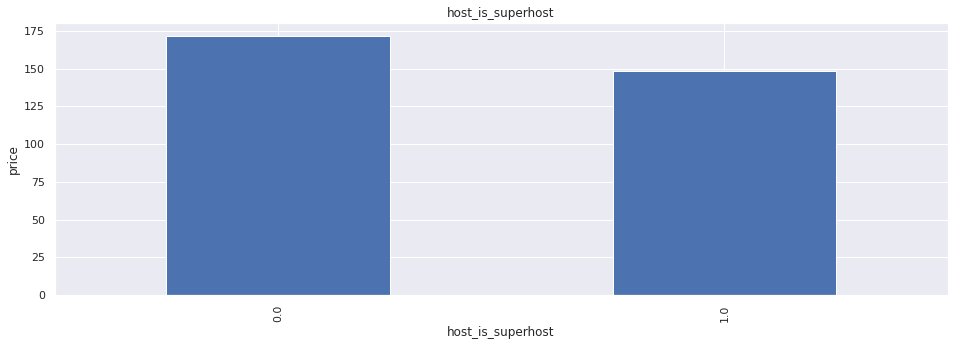

Text(0.5, 0, 'host_identity_verified')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'host_identity_verified')

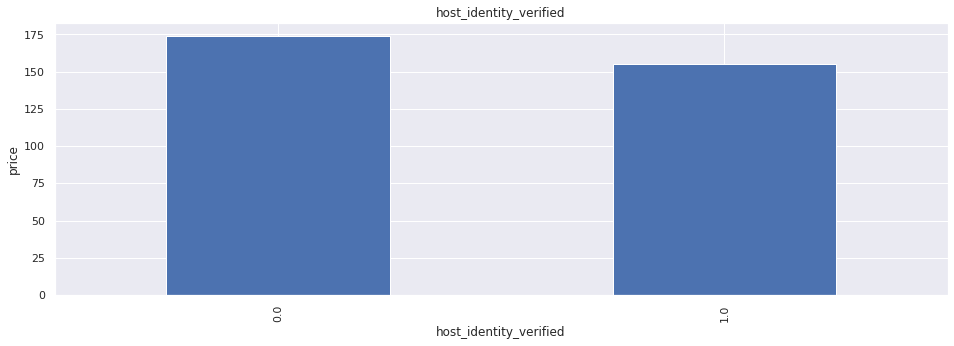

Text(0.5, 0, 'accommodates')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'accommodates')

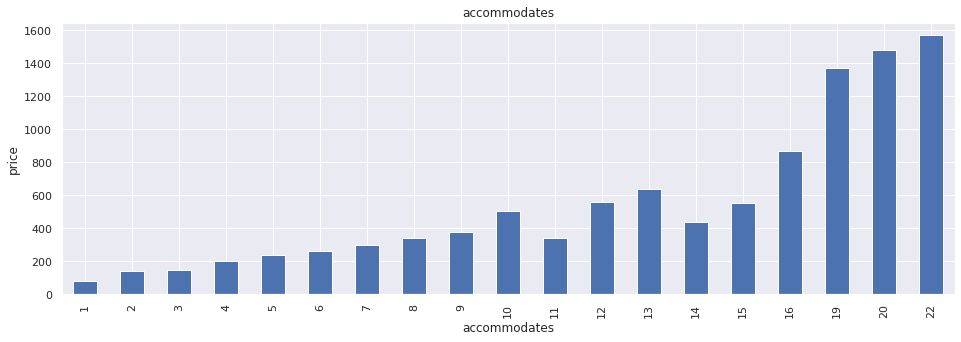

Text(0.5, 0, 'bathrooms')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'bathrooms')

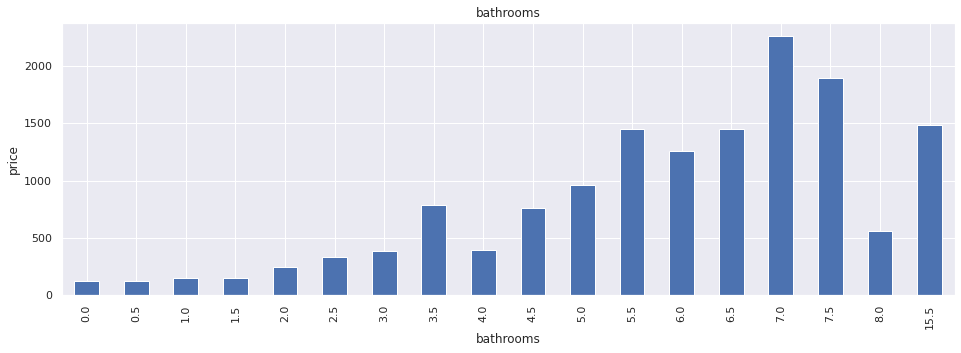

Text(0.5, 0, 'bedrooms')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'bedrooms')

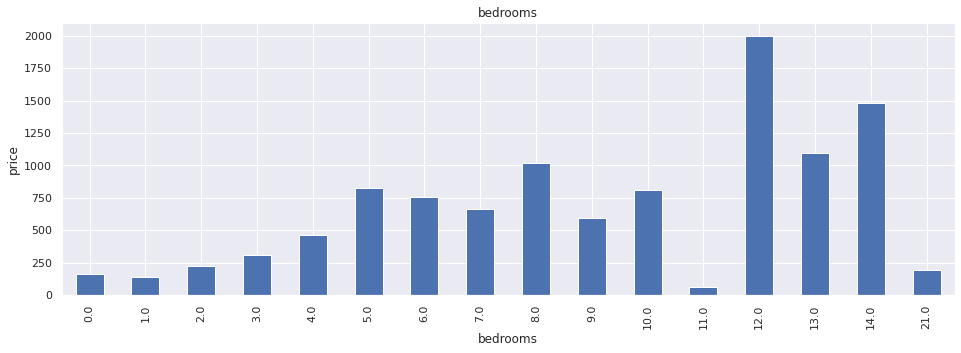

Text(0.5, 0, 'Num_of_guests_incl_forprice')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'Num_of_guests_incl_forprice')

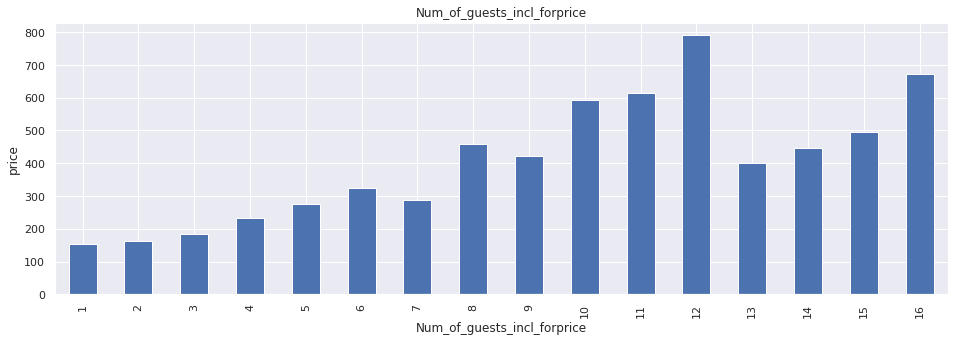

Text(0.5, 0, 'review_scores_accuracy')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'review_scores_accuracy')

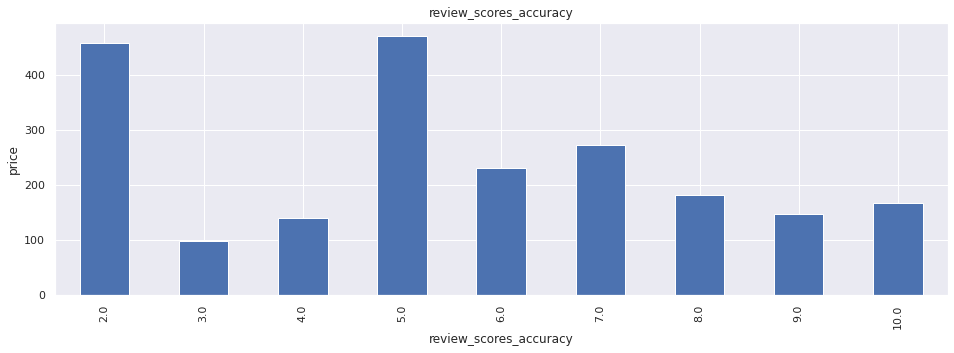

Text(0.5, 0, 'instant_bookable')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'instant_bookable')

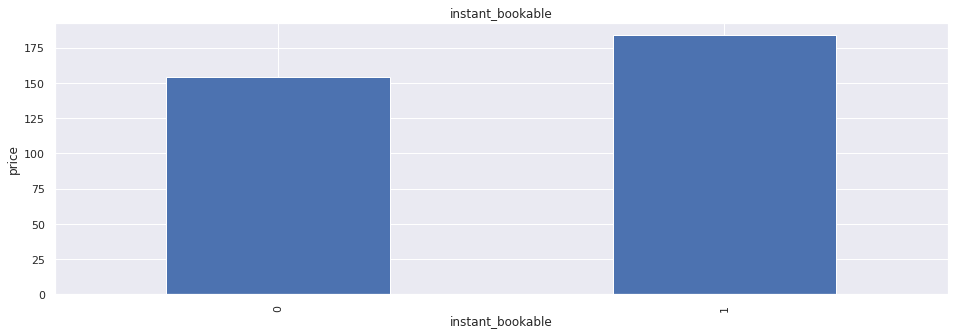

Text(0.5, 0, 'host_days_active_years')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'host_days_active_years')

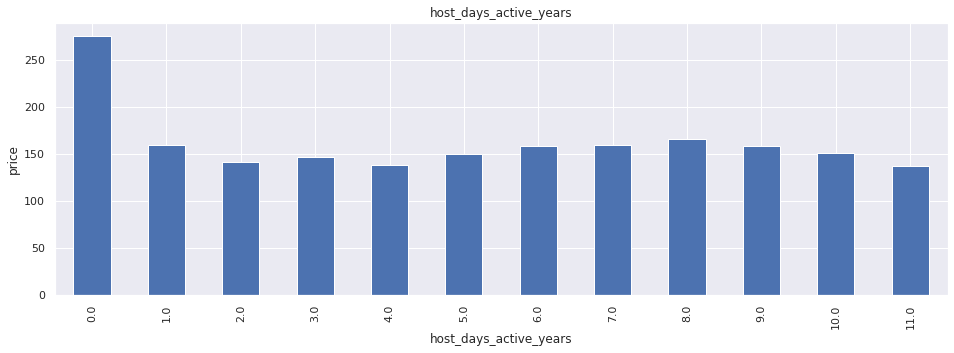

Text(0.5, 0, 'host_listing_since')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'host_listing_since')

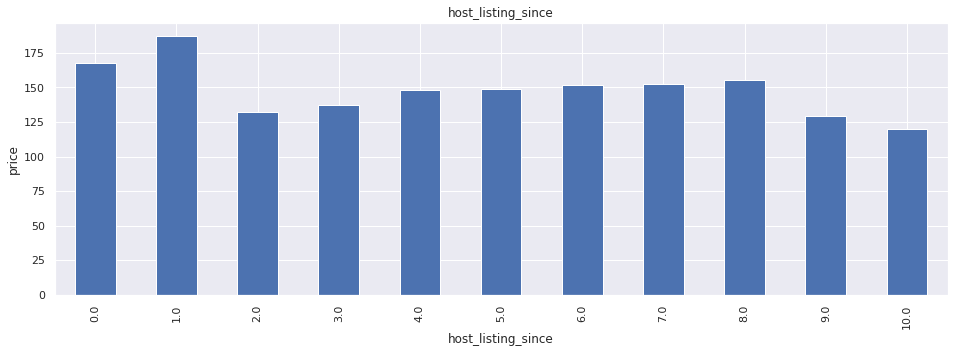

Text(0.5, 0, 'special_amenities')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'special_amenities')

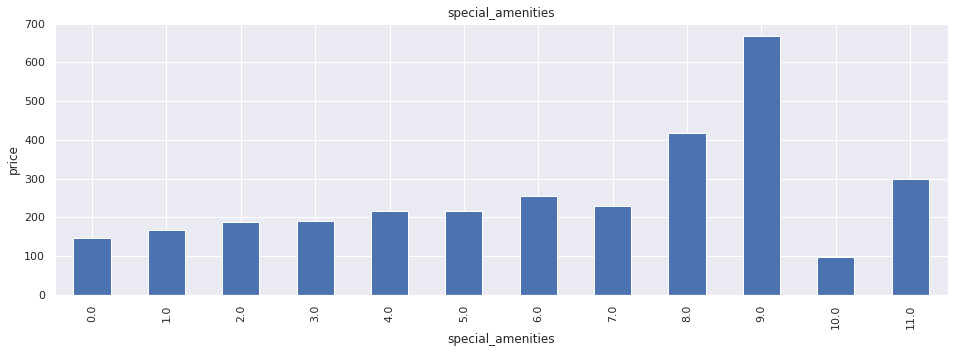

Text(0.5, 0, 'common_amenities')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'common_amenities')

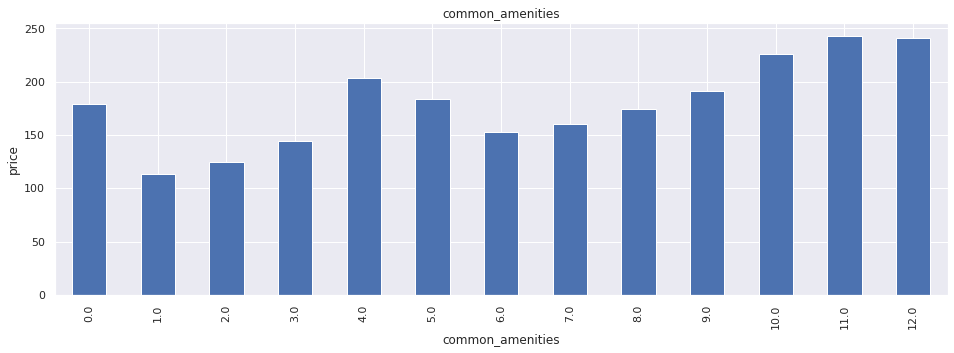

In [120]:
#relationship between discrete var and price
for i in Discrete_features:
    abm3.groupby(i)['price'].mean().plot.bar()
    plt.xlabel(i)
    plt.ylabel('price')
    plt.title(i)
    plt.show()

Points to be taken from above:
- from the above we can see the relationship being a superhost or not doesnot affect price
- accomodates has a linear increase in price with increase in accomadates
- special features also does not affect price much until special amenities count is greater than 7
- common amenities present properties have same price regardless of neighbourhood.
- review scores does not effect price of the property. So, we can drop review_score_accuracy.

Text(0.5, 1.0, 'Host_active_years Vs Price')

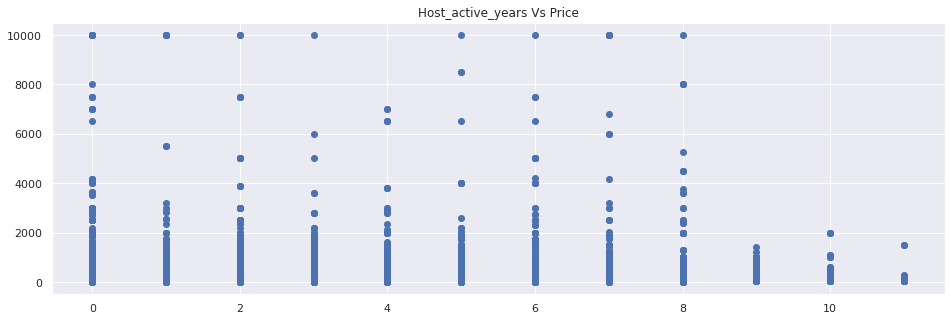

In [121]:
#lets compare the difference between years and price
plt.scatter(abm3.host_days_active_years,abm3.price)
plt.title('Host_active_years Vs Price')
plt.show()

**Note6:We can see that aas the number of years a host is registered and active the price is decreasing**

In [122]:
abm3.dtypes

host_response_time              object
host_response_rate             float64
host_is_superhost              float64
host_total_listings_count      float64
host_identity_verified         float64
neighbourhood_cleansed          object
Borough                         object
latitude                       float64
longitude                      float64
property_type                   object
room_type                       object
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
bed_type                        object
price                          float64
security_deposit               float64
cleaning_fee                   float64
Num_of_guests_incl_forprice      int64
price_per_extra_people         float64
minimum_nights                   int64
maximum_nights                   int64
availability_365                 int64
number_of_reviews_ltm            int64
review_scores_rating     

In [123]:
## Continuous var
Continous_features=[i for i in numerical_types if i not in Discrete_features]
Continous_features[1:] #since Host_id is not required

['host_total_listings_count',
 'latitude',
 'longitude',
 'beds',
 'price',
 'security_deposit',
 'cleaning_fee',
 'price_per_extra_people',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'number_of_reviews_ltm',
 'review_scores_rating',
 'avg_price_property_type',
 'avg_review_score']

Text(0.5, 0, 'minimum_nights')

Text(0, 0.5, 'count')

Text(0.5, 1.0, 'minimum_nights')

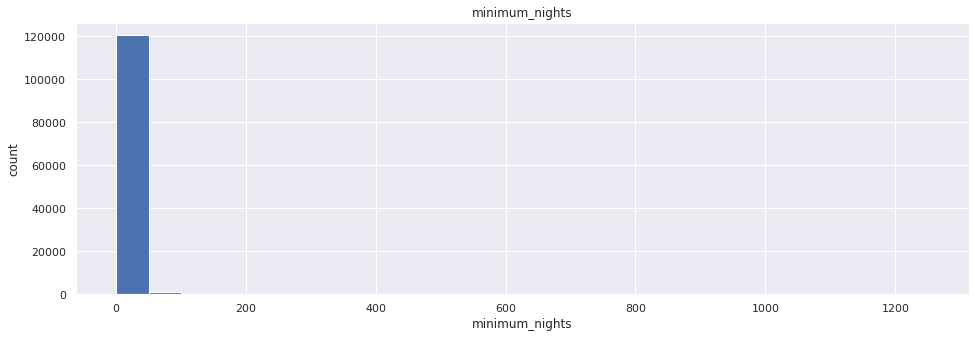

Text(0.5, 0, 'maximum_nights')

Text(0, 0.5, 'count')

Text(0.5, 1.0, 'maximum_nights')

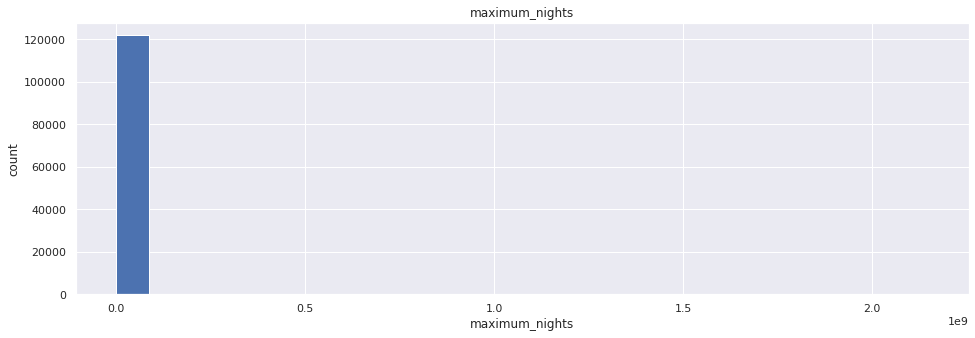

Text(0.5, 0, 'review_scores_rating')

Text(0, 0.5, 'count')

Text(0.5, 1.0, 'review_scores_rating')

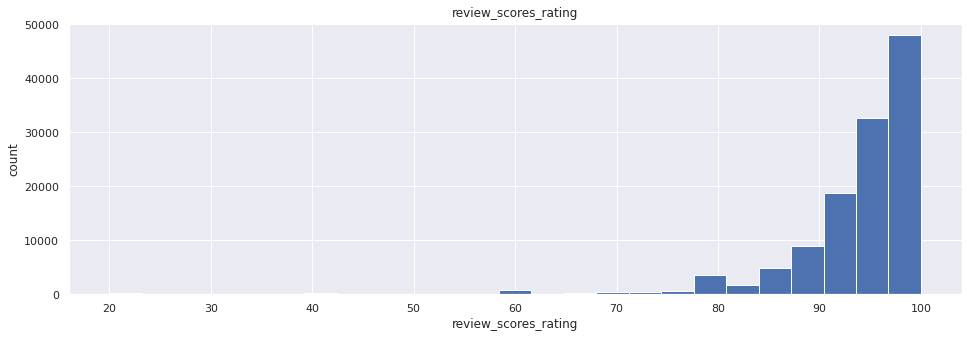

Text(0.5, 0, 'avg_price_property_type')

Text(0, 0.5, 'count')

Text(0.5, 1.0, 'avg_price_property_type')

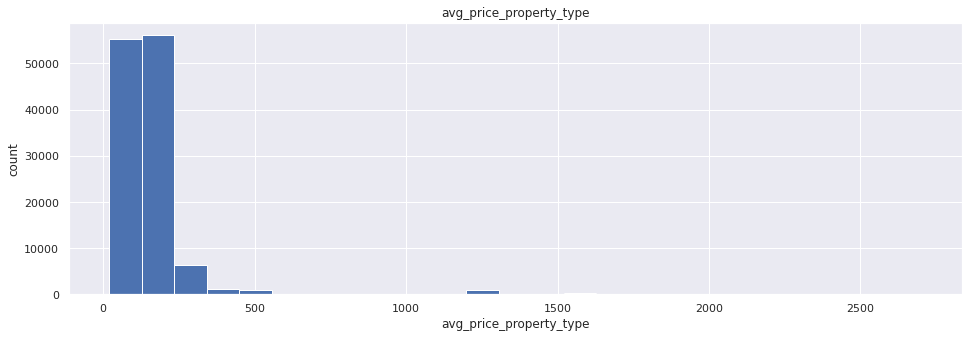

Text(0.5, 0, 'avg_review_score')

Text(0, 0.5, 'count')

Text(0.5, 1.0, 'avg_review_score')

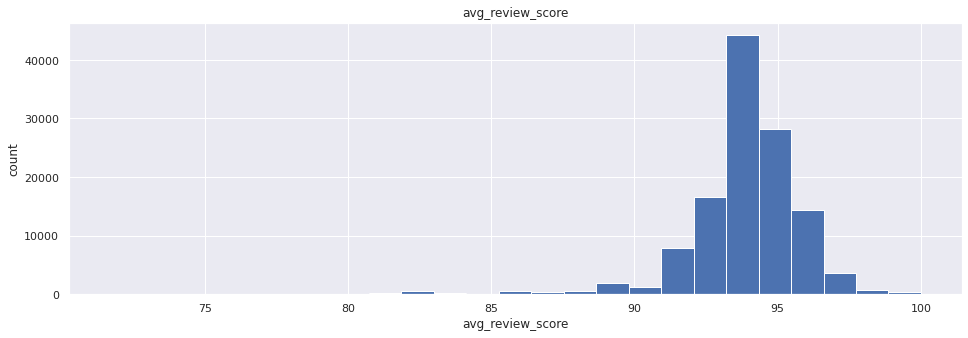

In [124]:
#ploting continous var
for i in Continous_features[1:]:
    data=abm3.copy()
    if 0 in data[i].unique():
        pass
    elif i in ['zipcode','latitude','longitude']:
        pass
    else:
#         data[i]=np.log(data[i])
        data[i].hist(bins=25)
        plt.xlabel(i)
        plt.ylabel('count')
        plt.title(i)
        plt.show()

**Note: From the above plots we observe the data is either right positively or negatively skewed, and also not normally distributed.**

#### - Avg age of listings group by borough

Borough
Bronx            2.939247
Queens           3.003464
Staten Island    3.266603
Manhattan        3.931208
Brooklyn         4.423512
Name: host_days_active_years, dtype: float64


<Figure size 1440x576 with 0 Axes>

Text(0.5, 1.0, 'Hosting since across boroughs')

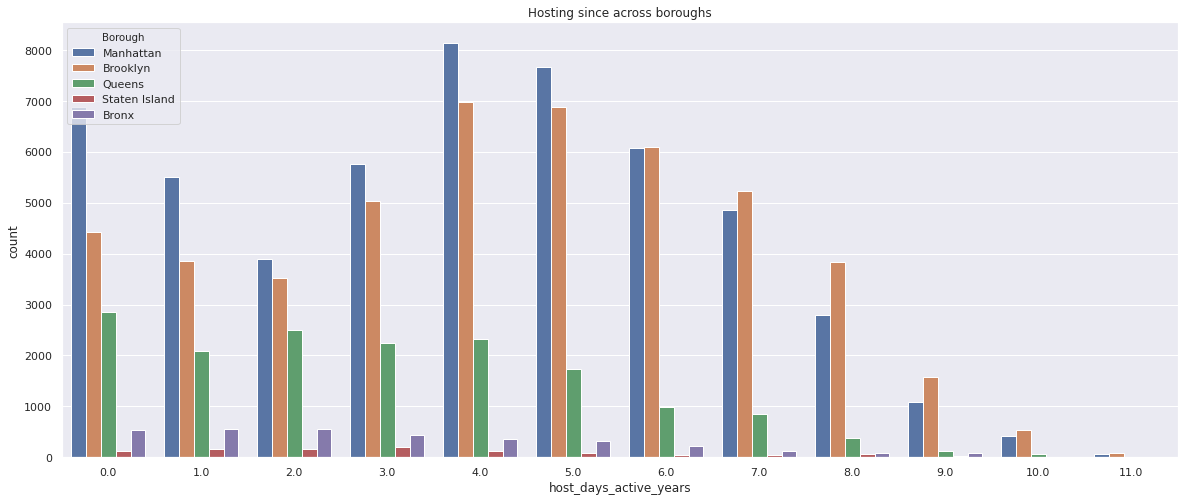

In [125]:
print(abm3.groupby(['Borough'])['host_days_active_years'].mean().sort_values())
plt.figure(figsize=(20,8))
sns.countplot(x ='host_days_active_years',hue = "Borough",data = abm3)
plt.title("Hosting since across boroughs")
plt.show()

Brooklyn and Manhattan have the oldest listings by nearly 4 years.

### -price distribution of various room types across neighbourhood groups

- It is clearly seen that hotel rooms are much costlier than entire house in manhattan and brooklyn region 
- overall entire apt/home price is higher than private room
- Also it is seen that staten island and bronx do not have any hotel rooms

room_type        Borough      
Shared room      Staten Island     30.700000
                 Brooklyn          54.973684
Private room     Staten Island     59.732932
Shared room      Bronx             62.074830
Private room     Bronx             62.679856
                 Queens            67.929726
Shared room      Queens            72.369287
Private room     Brooklyn          75.474640
Shared room      Manhattan         93.873016
Entire home/apt  Bronx            132.799833
                 Staten Island    137.423729
Hotel room       Queens           144.518182
Entire home/apt  Queens           147.564728
                 Brooklyn         179.130284
Hotel room       Brooklyn         180.461538
Private room     Manhattan        201.839160
Entire home/apt  Manhattan        247.603358
Hotel room       Manhattan        314.123469
Name: price, dtype: float64


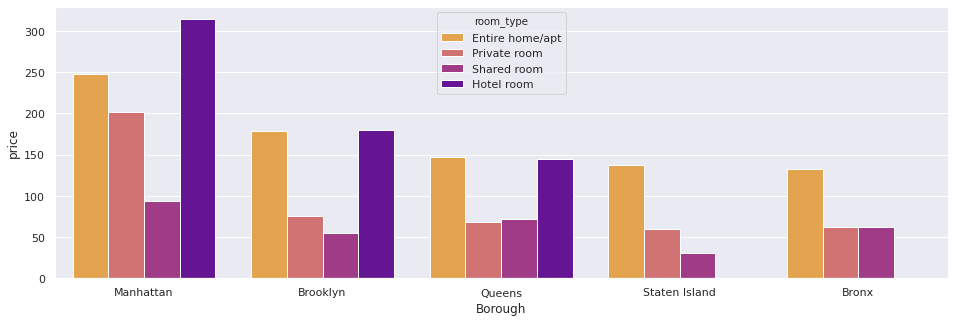

In [126]:
print(abm3.groupby(['room_type','Borough'])['price'].mean().sort_values())
sns.set(rc={'figure.figsize': (16, 5)})
ax = sns.barplot(x = 'Borough', y = 'price', hue = 'room_type', data =abm3, 
                 palette ='plasma_r', ci = False)

### Highly reviewed of every feature based on Number of reviews(last twelve months).

- In entire city we have more number of Appartment listings
- Except for brooklyn every Borough has more Appartments than other property types.

property_type
Apartment      10.940830
Condominium     9.136711
House          14.954220
Loft           11.279279
Other          11.029889
Townhouse      16.293734
Name: number_of_reviews_ltm, dtype: float64


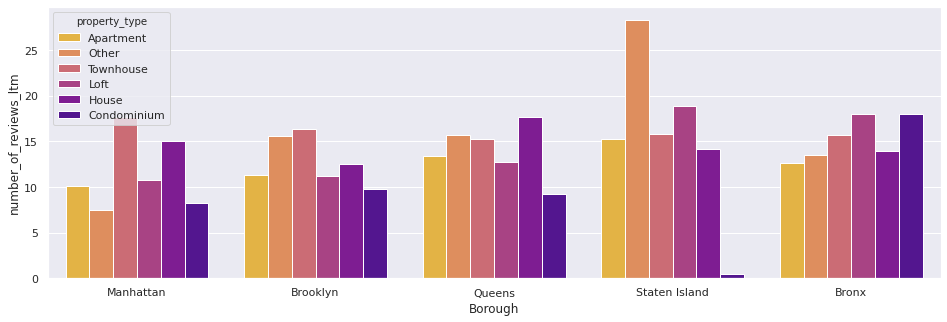

In [127]:
print(abm3.groupby(['property_type'])['number_of_reviews_ltm'].mean())
sns.set(rc={'figure.figsize': (16, 5)})
ax = sns.barplot(x = 'Borough', y = 'number_of_reviews_ltm', hue = 'property_type', data =abm3, 
                 palette ='plasma_r', ci = False)

room_type
Entire home/apt    11.277961
Hotel room         14.425064
Private room       11.822188
Shared room         8.165271
Name: number_of_reviews_ltm, dtype: float64


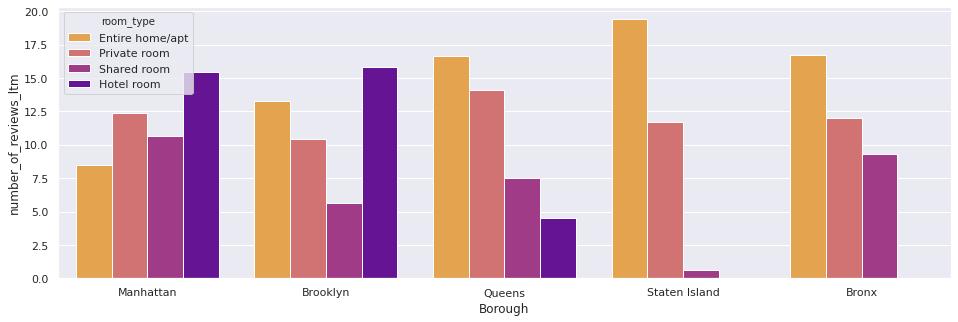

In [128]:
print(abm3.groupby(['room_type'])['number_of_reviews_ltm'].mean())
sns.set(rc={'figure.figsize': (16, 5)})
ax = sns.barplot(x = 'Borough', y = 'number_of_reviews_ltm', hue = 'room_type', data =abm3, 
                 palette ='plasma_r', ci = False)

In [129]:
# from mpl_toolkits.mplot3d import Axes3D
# from plotly.subplots import make_subplots
# import plotly.graph_objs as go
# from mpl_toolkits.mplot3d import Axes3D
# from plotly import tools

# fig = px.scatter_mapbox(abm3, 
#                         hover_data = ['price','minimum_nights','room_type'],
#                         hover_name = 'neighbourhood_cleansed',
#                         lat="latitude", 
#                         lon="longitude", 
#                         color="Borough", 
#                         size="price", 
#                         size_max=30, 
#                         opacity = .70,
#                         zoom=10,
#                        )
# fig.layout.mapbox.style = 'stamen-terrain'
# fig.update_layout(title_text = 'Airbnb by Borough in NYC<br>(Click legend to toggle borough)', height = 800)

In [130]:
# fig = px.scatter_mapbox(abm3,
#                         hover_data=['price','property_type','room_type','number_of_reviews_ltm'], 
#                         lat="latitude", 
#                         lon="longitude", 
#                         color="neighbourhood_cleansed", 
#                         size_max=30, 
#                         opacity = .70,
#                         zoom=12,
#                        )
# fig.layout.mapbox.style = 'carto-positron'
# fig.update_layout(title_text = 'NYC Airbnb by Neighbourhood<br>(Click legend to toggle neighbourhood)', height = 800)

In [131]:
# temp_bk = abm3[abm3.Borough == 'Brooklyn']
# temp_qn = abm3[abm3.Borough == 'Queens']
# temp_mn = abm3[abm3.Borough == 'Manhattan']
# temp_bx = abm3[abm3.Borough == 'Bronx']
# temp_si = abm3[abm3.Borough == 'Staten Island']

# labels = abm3.room_type.value_counts().index.to_list()

# fig = make_subplots(1, 5, specs=[[{'type':'domain'}, {'type':'domain'}, {'type':'domain'},{'type':'domain'},{'type':'domain'}]],
#                     subplot_titles=['Manhattan', 'Brooklyn', 'Queens','Bronx','Staten Island'])
# fig1= fig.add_trace(go.Pie(labels=labels, values=temp_mn.room_type.value_counts().reset_index().sort_values(by = 'index').room_type.tolist(), scalegroup='one',
#                      name="Manhattan"),1,1)
# fig2= fig.add_trace(go.Pie(labels=labels, values=temp_bk.room_type.value_counts().reset_index().sort_values(by = 'index').room_type.tolist(), scalegroup='one',
#                      name="Brooklyn"),1,2)
# fig3= fig.add_trace(go.Pie(labels=labels, values=temp_qn.room_type.value_counts().reset_index().sort_values(by = 'index').room_type.tolist(), scalegroup='one',
#                      name="Queens"),1,3)
# fig4= fig.add_trace(go.Pie(labels=labels, values=temp_bx.room_type.value_counts().reset_index().sort_values(by = 'index').room_type.tolist(), scalegroup='one',
#                      name="Bronx"),1,4)
# fig5= fig.add_trace(go.Pie(labels=labels, values=temp_si.room_type.value_counts().reset_index().sort_values(by = 'index').room_type.tolist(), scalegroup='one',
#                      name="Staten Island"),1,5)

# fig.update_layout(title_text='room types in Boroughs')

### - Cardinality of categorical features

In [132]:
 for i in categorical_types:
        print('feature-{} & number of categories-{}'.format(i,len(abm3[i].unique())))

feature-host_response_time & number of categories-5
feature-neighbourhood_cleansed & number of categories-225
feature-Borough & number of categories-5
feature-property_type & number of categories-6
feature-room_type & number of categories-4
feature-bed_type & number of categories-5
feature-cancellation_policy & number of categories-3


Text(0.5, 0, 'host_response_time')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'host_response_time')

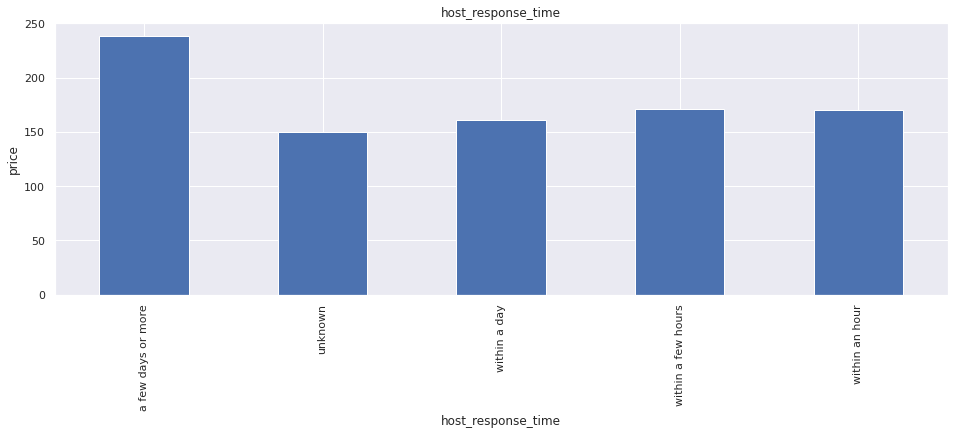

Text(0.5, 0, 'Borough')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'Borough')

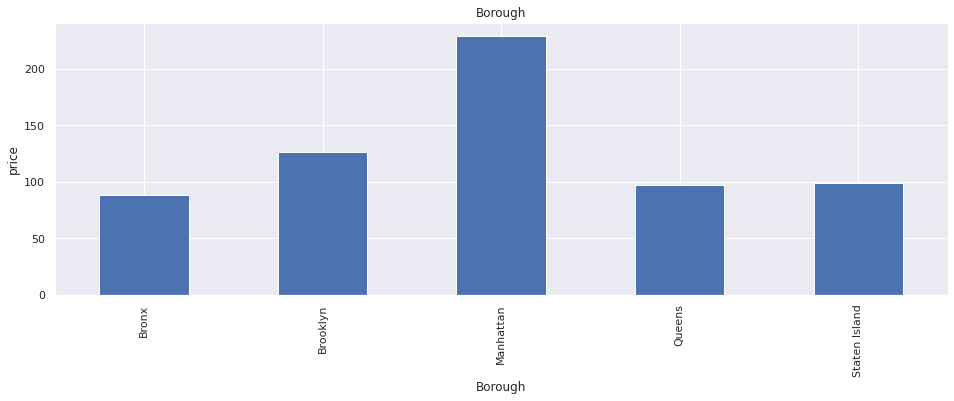

Text(0.5, 0, 'property_type')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'property_type')

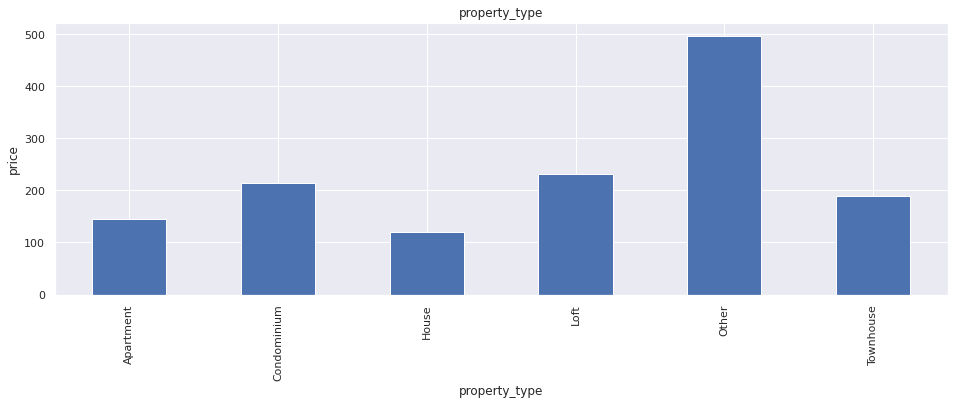

Text(0.5, 0, 'room_type')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'room_type')

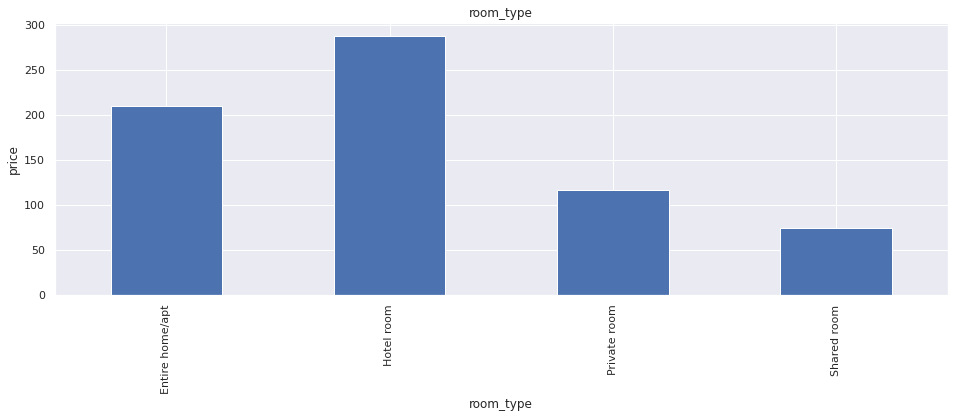

Text(0.5, 0, 'bed_type')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'bed_type')

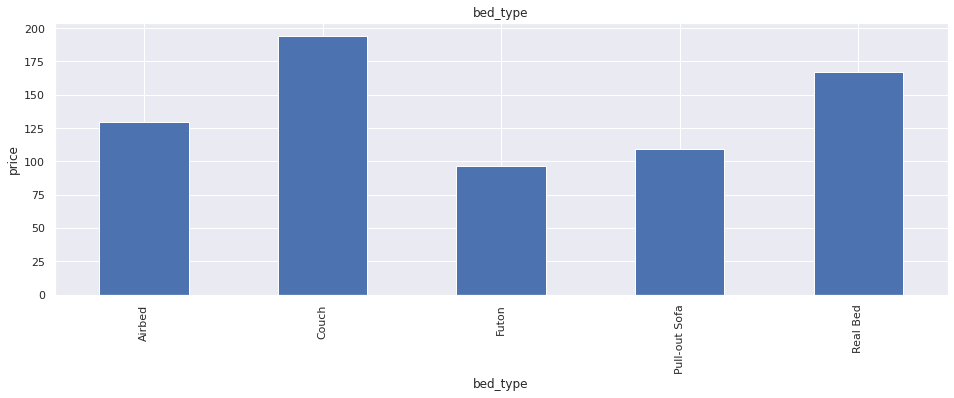

Text(0.5, 0, 'cancellation_policy')

Text(0, 0.5, 'price')

Text(0.5, 1.0, 'cancellation_policy')

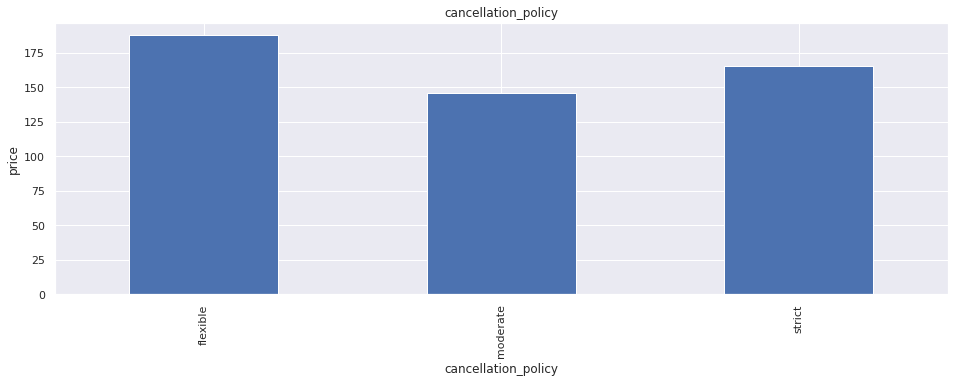

In [133]:
#relationship b/w categorical and dependent var
for i in categorical_types:
    if len(data[i].unique())>40:
        pass
    elif len(data[i].unique())==1:
        pass
    else:
        data.groupby(i)['price'].mean().plot.bar()
        plt.xlabel(i)
        plt.ylabel('price')
        plt.title(i)
        plt.show()

- from the above we can observe relationship between categorical feature and price feature and also we can reduce the labels

### Statistics Analysis

 Objective: To perform Statistical Analysis on the data set by implementing various stats modules (on New York AirBnb data) such as Hypothesis Testing, Tests of Mean (Kruskal Wallis Test, ANOVA - one way and two way), Tests of Proportion (z test and chi-squared test) and Tests of Variance (F-test, Levene test), after checking for the three assumptions of (i) Normality of target variable (ii) Randomness of Sampling (iii) Equal variance across categories. The level of significance is assumed to be 5 percent (i.e. alpha = 0.05) If assumptions are satisfied, parametric tests(assumes already distribution is present(ANOVA) can be performed, else non-parametric tests(do not rely on any distributions(CHI-SQUARE) have to be performed. The results of the tests performed will enable us to find the associativity and dependability of different features on one-another.

In [134]:
cont = pd.crosstab(abm3.Borough,abm3.room_type)
cont

room_type,Entire home/apt,Hotel room,Private room,Shared room
Borough,,,,
Bronx,1199,0,1946,147
Brooklyn,23702,91,23127,1140
Manhattan,32455,980,18422,1260
Queens,5863,110,9648,547
Staten Island,531,0,498,10


Testing the assumptions:
- Randomness of Data
- Normality Test
- Variance Test

The target variable being the price.

<Figure size 720x504 with 0 Axes>

Text(0.5, 0, 'Price')

Text(0.5, 1.0, 'Distribution of Price of among property types')

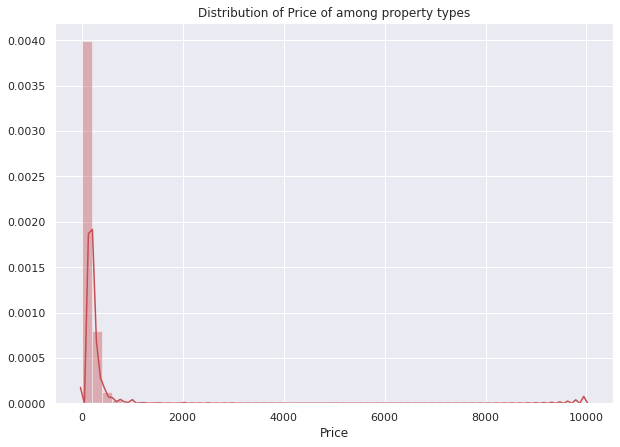

In [135]:
plt.figure(figsize=(10,7))
sns.distplot(abm2.price,color='r')
plt.xlabel("Price")
plt.title("Distribution of Price of among property types")
plt.show()

#### Shapiro Test (for checking Normality)

- H0 (Null Hypothesis) : Distribution is normal

- H1 (Alternate Hypothesis): Distribution is not normal

In [136]:
import scipy.stats as st
st.shapiro(abm2.price)

(0.15897482633590698, 0.0)

#### Levene Test (for testing of variance)
H0 (null hypothesis): variance(private_room) = variance(shared_room) = variance(entire_home)=variance(hotel_room)

H1 (alternate hypothesis): variance(private_room) != variance(shared_room) != variance(entire_home)!=variance(hotel_room)

In [137]:
pvt = abm3[abm3['room_type'] == 'Private room']
share = abm3[abm3['room_type'] == 'Shared room']
apt = abm3[abm3['room_type'] == 'Entire home/apt']
hotel=abm3[abm3['room_type'] == 'Hotel room']

In [138]:
st.levene(pvt.price, share.price, apt.price,hotel.price)

LeveneResult(statistic=70.80752126514611, pvalue=9.55959985524595e-46)

Here P-value is less than 0.5 and therefore we can reject null hypothesis and can say that price varies in different room types

#### price vs neighbourhood
H0 (null hypothesis): mean_price(Brooklyn) = mean_price(Manhattan) = ..... = mean_price(Bronx)

H1 (null hypothesis): mean_price(Brooklyn) != mean_price(Manhattan) != ..... != mean_price(Bronx)

In [139]:
import  scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [140]:
## one way anova
mod = ols('price ~ Borough', data =abm3).fit()
aov_table = sm.stats.anova_lm(mod, typ=1)
print(aov_table)

                df        sum_sq       mean_sq           F  PR(>F)
Borough        4.0  3.891123e+08  9.727807e+07  547.682778     0.0
Residual  121671.0  2.161090e+10  1.776175e+05         NaN     NaN


Here pvalue obtained is greater than 0.5, so we fail to reject null hypothesis

#### Room Type vs Neighbourhood Group

Since both the variables Room Type and Neighbourhood Group are categorical having more than two categories, we can peform Chi-squared test.

#### Chi Squared Test
- H0 (null hypothesis): There is no association between Room Type and Neighbourhood Group.
- H1 (alternate hypothesis): There is an association between Room Type and Neighbourhood Group.

In [141]:
tab = pd.crosstab(abm3['room_type'],abm3['Borough'])

In [142]:
st.chi2_contingency(tab)

(5016.088163783007,
 0.0,
 12,
 array([[1.72478550e+03, 2.51801917e+04, 2.78297179e+04, 8.47093922e+03,
         5.44365775e+02],
        [3.19524968e+01, 4.66475394e+02, 5.15559165e+02, 1.56928301e+02,
         1.00846428e+01],
        [1.45128186e+03, 2.11873045e+04, 2.34166886e+04, 7.12768079e+03,
         4.58044306e+02],
        [8.39801440e+01, 1.22602847e+03, 1.35503442e+03, 4.12451691e+02,
         2.65052763e+01]]))

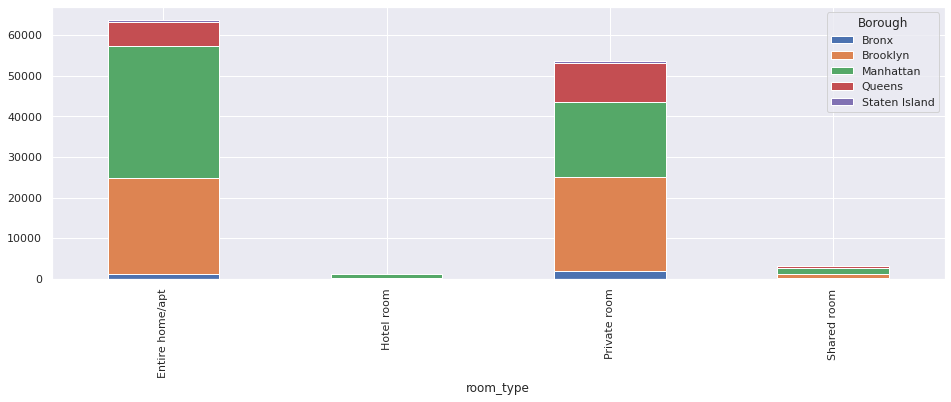

In [143]:
ct = pd.crosstab(abm3['room_type'],abm3['Borough'])
ct.plot.bar(stacked=True)
plt.show()

### price vs review scores rating

In [144]:
mod = ols('price ~ review_scores_rating', data =abm3).fit()
aov_table = sm.stats.anova_lm(mod, typ=1)
print(aov_table)

                            df        sum_sq       mean_sq           F  \
review_scores_rating       1.0  3.946650e+07  3.946650e+07  218.666955   
Residual              121674.0  2.196055e+10  1.804868e+05         NaN   

                            PR(>F)  
review_scores_rating  1.950579e-49  
Residual                       NaN  


here Pvalue obtained is less than 0.5, so we can reject null hypothesis and can say that reviews have an effect on price

### price vs cancellation policy

In [145]:
mod = ols('price ~ cancellation_policy', data =abm3).fit()
aov_table = sm.stats.anova_lm(mod, typ=1)
print(aov_table)

                           df        sum_sq       mean_sq         F  \
cancellation_policy       2.0  2.601505e+07  1.300753e+07  72.02442   
Residual             121673.0  2.197400e+10  1.805988e+05       NaN   

                           PR(>F)  
cancellation_policy  5.478900e-32  
Residual                      NaN  


here Pvalue obtained is less than 0.5, so we can reject null hypothesis and can say that cancellation policy have an effect on price

### price vs availability_365

In [146]:
mod = ols('price ~ availability_365', data =abm3).fit()
aov_table = sm.stats.anova_lm(mod, typ=1)
print(aov_table)

                        df        sum_sq       mean_sq           F  \
availability_365       1.0  1.139076e+08  1.139076e+08  633.259721   
Residual          121674.0  2.188611e+10  1.798750e+05         NaN   

                         PR(>F)  
availability_365  2.226360e-139  
Residual                    NaN  


#### chi2 on response rate and property type, borough etc

In [147]:
tab = pd.crosstab(abm3['host_response_rate'],abm3['property_type'])

In [148]:
st.chi2_contingency(tab)

(2605.524857008075,
 3.771753547931564e-309,
 425,
 array([[1.02534712e+03, 4.81770275e+01, 1.24638417e+02, 3.95847332e+01,
         6.52501726e+01, 5.30025313e+01],
        [7.56155692e-01, 3.55287814e-02, 9.19162366e-02, 2.91922811e-02,
         4.81195963e-02, 3.90874125e-02],
        [1.51231138e+00, 7.10575627e-02, 1.83832473e-01, 5.83845623e-02,
         9.62391926e-02, 7.81748249e-02],
        [3.02462277e+01, 1.42115125e+00, 3.67664946e+00, 1.16769125e+00,
         1.92478385e+00, 1.56349650e+00],
        [6.04924554e+00, 2.84230251e-01, 7.35329893e-01, 2.33538249e-01,
         3.84956770e-01, 3.12699300e-01],
        [9.07386831e+00, 4.26345376e-01, 1.10299484e+00, 3.50307374e-01,
         5.77435156e-01, 4.69048950e-01],
        [7.56155692e+00, 3.55287814e-01, 9.19162366e-01, 2.91922811e-01,
         4.81195963e-01, 3.90874125e-01],
        [2.11723594e+01, 9.94805878e-01, 2.57365462e+00, 8.17383872e-01,
         1.34734870e+00, 1.09444755e+00],
        [3.02462277e+00, 1.42

In [149]:
tab = pd.crosstab(abm3['host_response_rate'],abm3['Borough'])

In [150]:
st.chi2_contingency(tab)

(3547.0451698390043,
 0.0,
 340,
 array([[3.66872021e+01, 5.35597488e+02, 5.91954469e+02, 1.80181860e+02,
         1.15789802e+01],
        [2.70554588e-02, 3.94983399e-01, 4.36544594e-01, 1.32877478e-01,
         8.53907098e-03],
        [5.41109175e-02, 7.89966797e-01, 8.73089188e-01, 2.65754956e-01,
         1.70781420e-02],
        [1.08221835e+00, 1.57993359e+01, 1.74617838e+01, 5.31509912e+00,
         3.41562839e-01],
        [2.16443670e-01, 3.15986719e+00, 3.49235675e+00, 1.06301982e+00,
         6.83125678e-02],
        [3.24665505e-01, 4.73980078e+00, 5.23853513e+00, 1.59452973e+00,
         1.02468852e-01],
        [2.70554588e-01, 3.94983399e+00, 4.36544594e+00, 1.32877478e+00,
         8.53907098e-02],
        [7.57552845e-01, 1.10595352e+01, 1.22232486e+01, 3.72056938e+00,
         2.39093987e-01],
        [1.08221835e-01, 1.57993359e+00, 1.74617838e+00, 5.31509912e-01,
         3.41562839e-02],
        [2.86787863e+00, 4.18682402e+01, 4.62737269e+01, 1.40850127e+01,
   

### Correlation Analysis

In [151]:
abm3.shape

(121676, 35)

In [152]:
numerical=[i for i in abm3.columns if abm3[i].dtypes!='O']
len(numerical)

28

In [153]:
cor = abm3.corr()

#Correlation with output variable
cor_target = abs(cor["price"])

# Selecting highly correlated features
relevant_features = cor_target[cor_target>0.0]
relevant_features

host_response_rate             0.049588
host_is_superhost              0.022927
host_total_listings_count      0.025971
host_identity_verified         0.021394
latitude                       0.033511
longitude                      0.105299
accommodates                   0.180508
bathrooms                      0.127249
bedrooms                       0.143716
beds                           0.131202
price                          1.000000
security_deposit               0.088196
cleaning_fee                   0.149144
Num_of_guests_incl_forprice    0.093140
price_per_extra_people         0.011131
minimum_nights                 0.010934
maximum_nights                 0.000061
availability_365               0.071956
number_of_reviews_ltm          0.044174
review_scores_rating           0.042355
review_scores_accuracy         0.023357
instant_bookable               0.034177
host_days_active_years         0.047673
host_listing_since             0.021741
special_amenities              0.048209


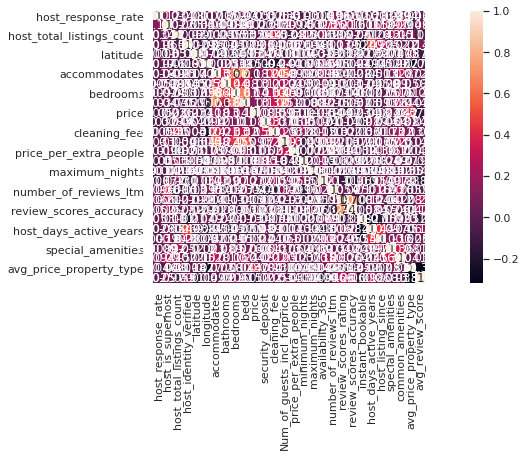

In [154]:
top_corr_features = cor.index[abs(cor["price"])>0.0]
# plt.figure(figsize=(10,15))
sns.heatmap(abm3[top_corr_features].corr(), annot = True, 
                cbar = True,square=True)

**Since we can see except avg_price_property_type is the only feature with above 0.3 correlation we are dropping none features and moving with feature Engineering and Selection**

In [155]:
# condition check for Multicollinearity  between 2 newly extracted features
print(abm3[["avg_review_score","avg_price_property_type"]].corr())

                         avg_review_score  avg_price_property_type
avg_review_score                   1.0000                  -0.3157
avg_price_property_type           -0.3157                   1.0000


## III. Feature Engineering

- Reducing Labels in the Object features
- Handling Outliers
- Transforming data


In [156]:
# Checking objects in Categorical variable.
print('host_response_time: \n',abm3['host_response_time'].value_counts()/abm3['host_response_time'].value_counts().sum()*100)
print('=================================================')
print('cancellation_policy: \n',abm3.cancellation_policy.value_counts()/abm3['cancellation_policy'].value_counts().sum()*100)

host_response_time: 
 within an hour        50.151221
unknown               22.207338
within a few hours    15.263487
within a day          10.160590
a few days or more     2.217364
Name: host_response_time, dtype: float64
cancellation_policy: 
 strict      50.322989
flexible    25.689536
moderate    23.987475
Name: cancellation_policy, dtype: float64


In [157]:
# Reducig labdels in Host_response_time.
abm3.replace({'within an hour':'Hour','within a few hours':'One Day','within a day':'Days'},inplace=True)

# Decreasig the value_counts in property_type

#With 10 categories we account for 95% of the listings
(abm3['property_type'].value_counts()/abm3['property_type'].value_counts().sum()*100)[0:5].sum()

97.0807718859923

In [158]:
Mod_prop_type=abm3['property_type'].value_counts()[5:len(abm1['property_type'].value_counts())].index.tolist()

def change_prop_type(label):
    if label in Mod_prop_type:
        label='Other'
    return label
# Mod_prop_type
abm3.loc[:,'property_type'] = abm3.loc[:,'property_type'].apply(change_prop_type)

In [159]:
abm3.property_type.value_counts()

Apartment      92006
House          11184
Other           9407
Townhouse       4756
Condominium     4323
Name: property_type, dtype: int64

In [160]:
numerical_types

Index(['host_response_rate', 'host_is_superhost', 'host_total_listings_count',
       'host_identity_verified', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score'],
      dtype='object')

### Handling outliers

In [161]:
cap_df = abm3.copy()

21

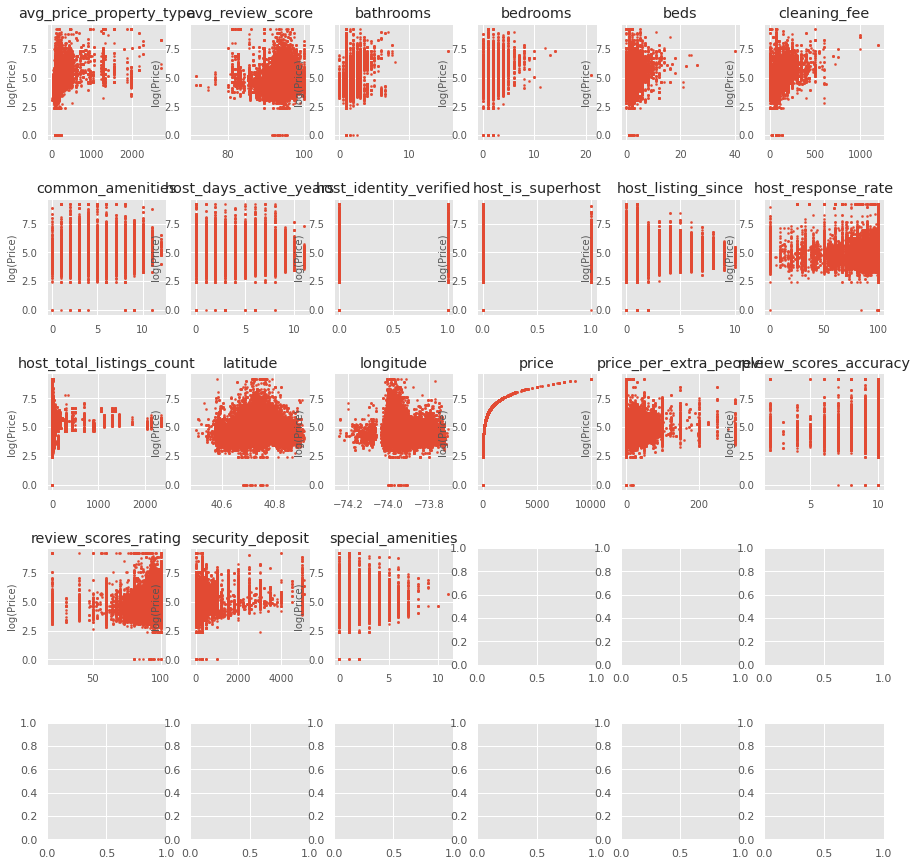

In [162]:
def features_plot(feat,df):
    plt.rcParams['figure.figsize']=(15,15)
    plt.style.use(style='ggplot')
    xxx,sub=plt.subplots(5,6)
    xxx.subplots_adjust(hspace=0.5)
    sub=sub.flatten()
    for i in range(len(feat)):
        sub[i].scatter(x=df[feat[i]], y=np.log1p(abm3["price"]),s=4)
        sub[i].set_title('{}'.format(feat[i],fontsize=10))
        sub[i].set_ylabel('log(Price)',fontsize=10)
        sub[i].tick_params(labelsize=10)
    plt.show()
    

Numerical_cols=[i for i in cap_df.columns if cap_df[i].dtypes=='float64']
len(Numerical_cols)
Numerical_cols = list(Numerical_cols)
# Numerical_cols.remove('price')
features_plot(sorted(Numerical_cols),cap_df)

In [163]:
def cap_data(df):
    for col in df.columns:
#         print("capping the ",col)
        if (((df[col].dtype)=='float64') | ((df[col].dtype)=='int64')):
            percentiles = df[col].quantile([0.25,0.75]).values
            df[col][df[col] <= percentiles[0]] = percentiles[0]
            df[col][df[col] >= percentiles[1]] = percentiles[1]
            print(percentiles)
        else:
            df[col]=df[col]
    return df

# abm3 = cap_data(abm2)

In [164]:
# Capping outliers at lower and upper viscor
cap_df = cap_data(cap_df)

[100. 100.]
[0. 0.]
[1. 3.]
[0. 1.]
[40.6890075 40.76288  ]
[-73.98338 -73.93119]
[2. 4.]
[1. 1.]
[1. 1.]
[1. 2.]
[ 69. 179.]
[  0. 300.]
[30. 90.]
[1. 2.]
[ 0. 25.]
[1. 5.]
[  29. 1125.]
[  5. 282.]
[ 0. 16.]
[92.07142857 99.        ]
[10. 10.]
[0. 1.]
[2. 6.]
[0. 2.]
[0. 2.]
[3. 7.]
[101.87192049 191.80208333]
[93.21575342 95.04970812]


21

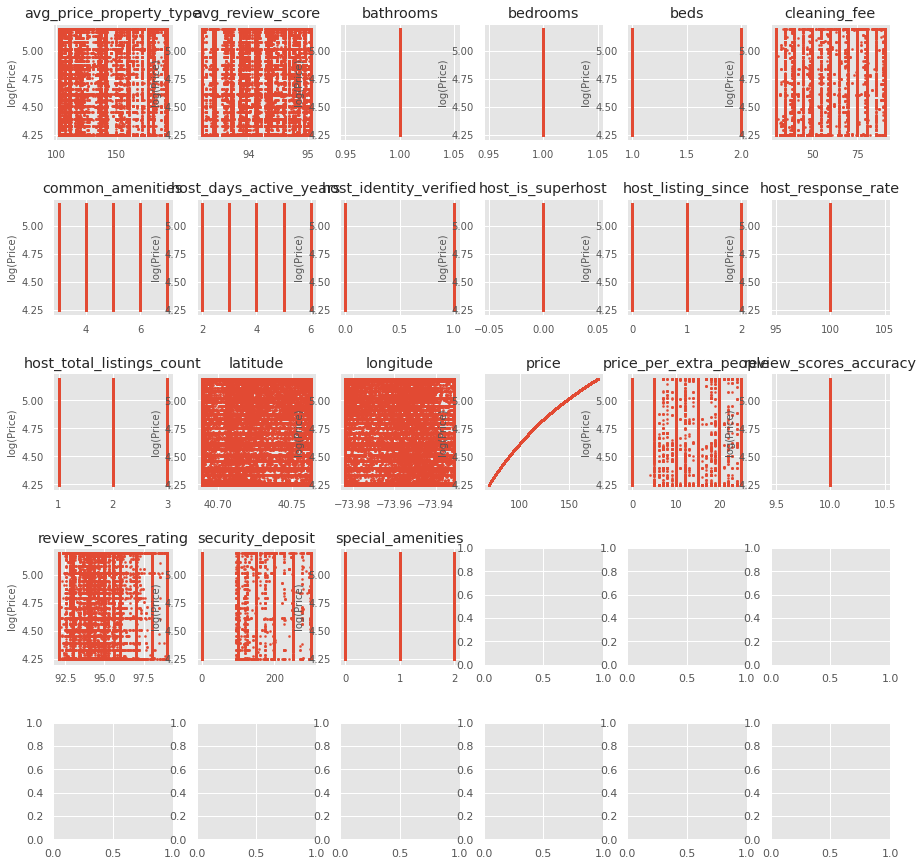

In [165]:
def features_plot(feat,df):
    plt.rcParams['figure.figsize']=(15,15)
    plt.style.use(style='ggplot')
    xxx,sub=plt.subplots(5,6)
    xxx.subplots_adjust(hspace=0.5)
    sub=sub.flatten()
    for i in range(len(feat)):
        sub[i].scatter(x=df[feat[i]], y=np.log1p(df["price"]),s=4)
        sub[i].set_title('{}'.format(feat[i],fontsize=10))
        sub[i].set_ylabel('log(Price)',fontsize=10)
        sub[i].tick_params(labelsize=10)
    plt.show()
    

Numerical_cols=[i for i in cap_df.columns if cap_df[i].dtypes=='float64']
len(Numerical_cols)
Numerical_cols = list(Numerical_cols)
# Numerical_cols.remove('price')
features_plot(sorted(Numerical_cols),cap_df)

#### Feature transformation

In [166]:
num_columns = ['host_is_superhost', 'host_total_listings_count',
       'host_identity_verified', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price']
num_columns1 = ['price', 'availability_365','number_of_reviews_ltm', 'review_scores_rating','review_scores_accuracy', 
               'instant_bookable', 'host_days_active_years','host_listing_since']

num_columns2 = ['special_amenities', 
               'common_amenities', 'avg_price_property_type', 'avg_review_score','price', 'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people','minimum_nights', 'maximum_nights']

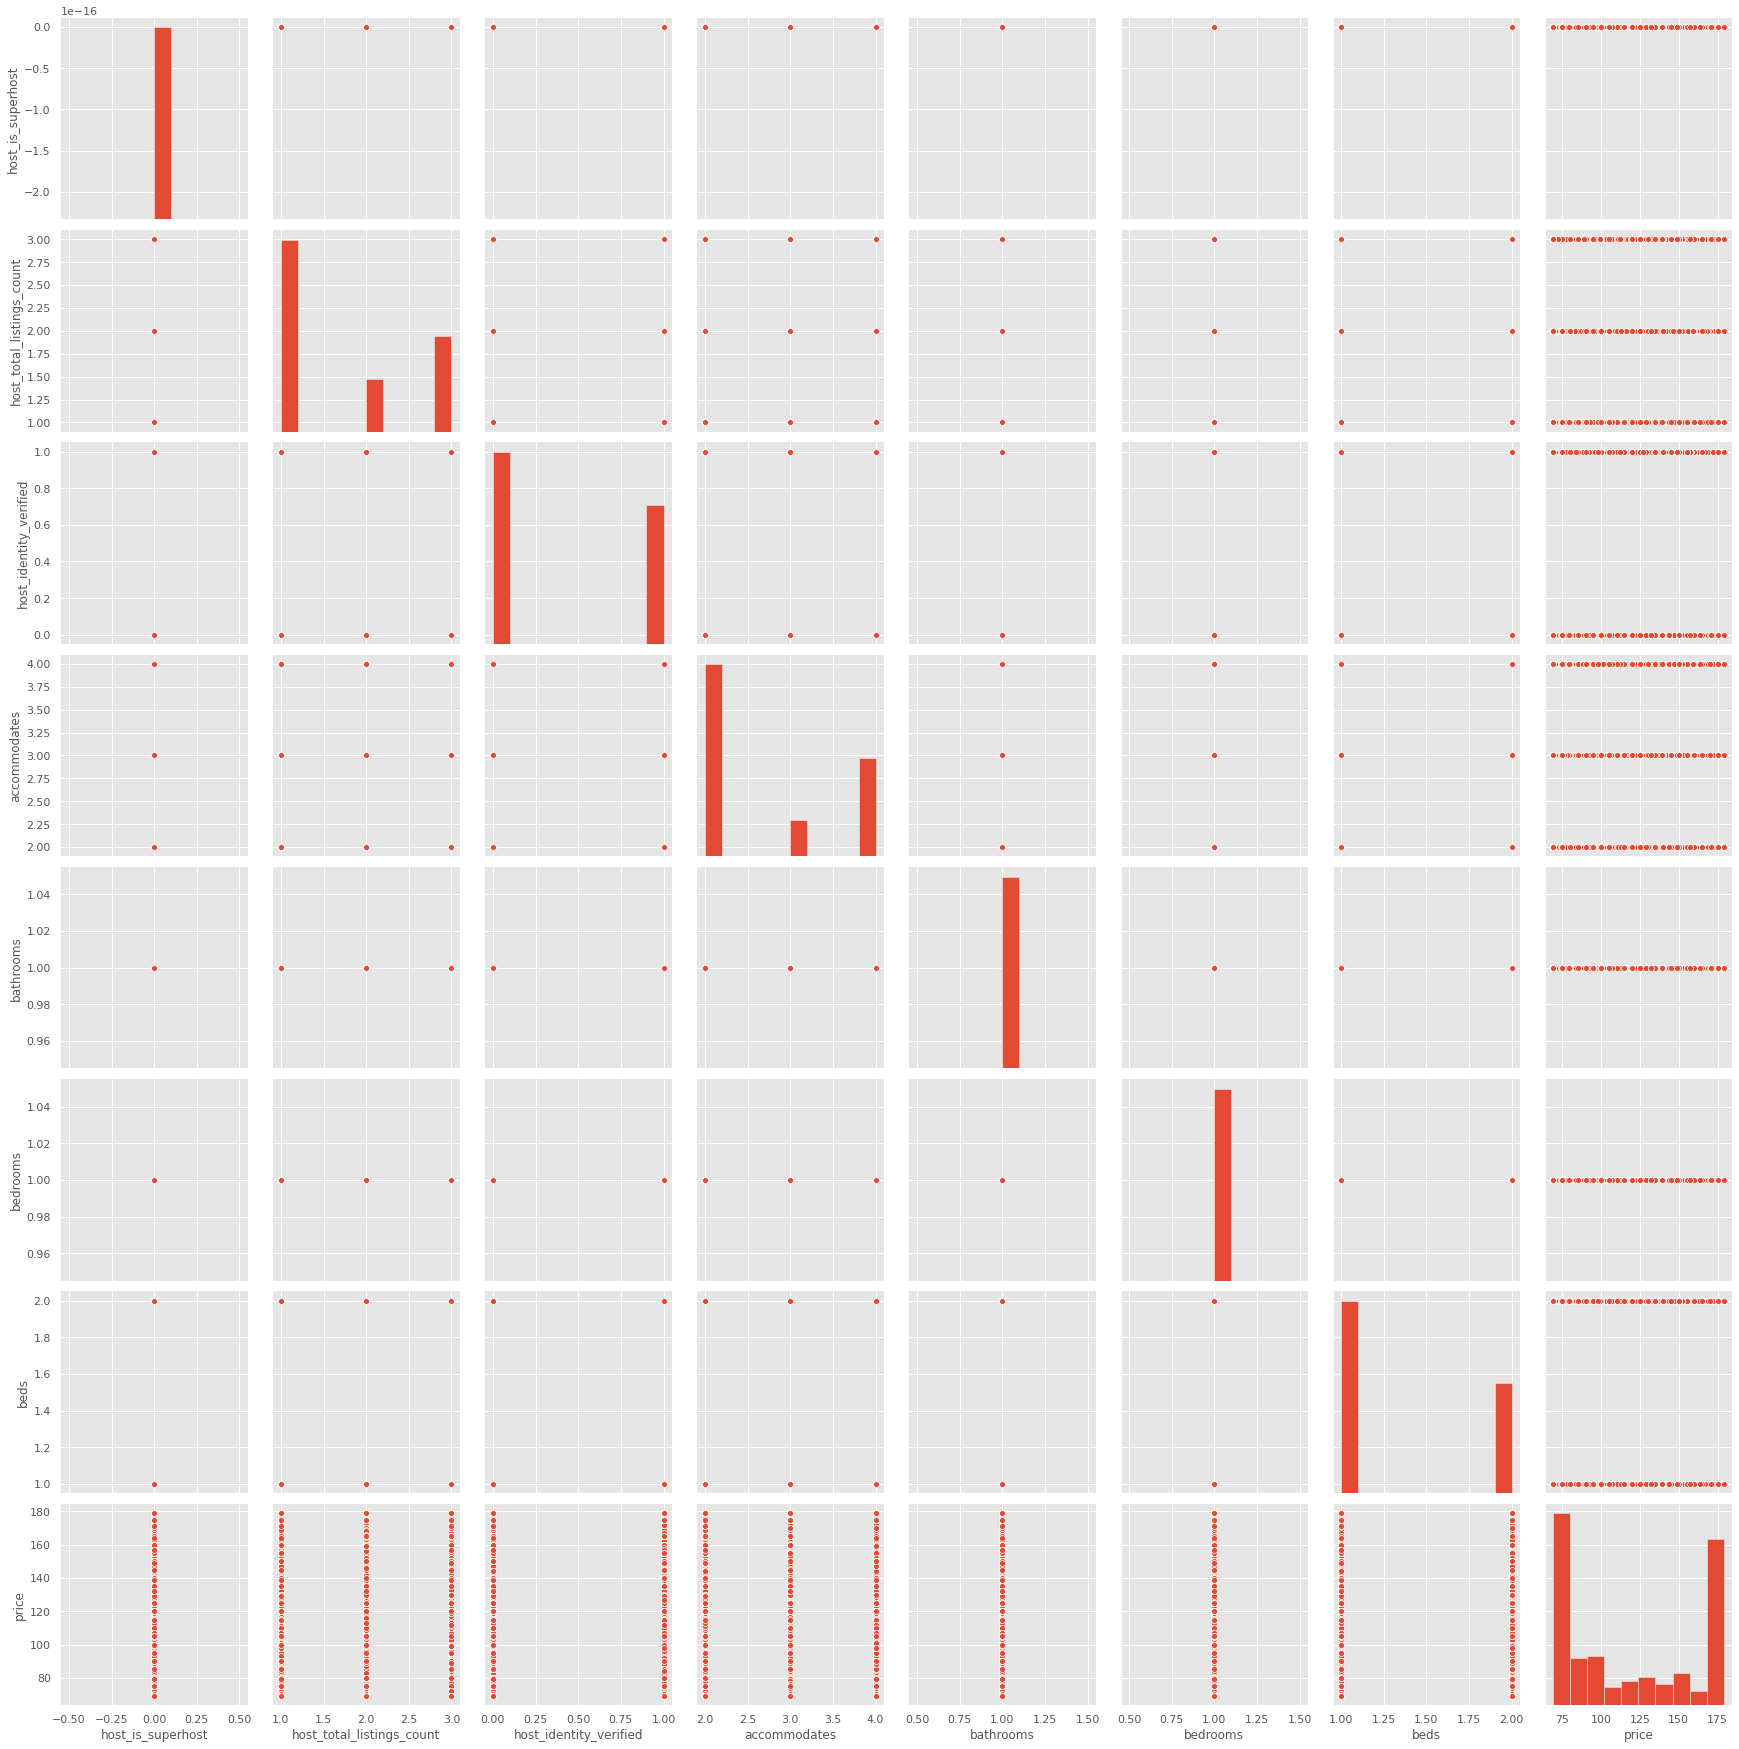

In [167]:
sns.pairplot(data=cap_df[num_columns],height=3)
plt.show()

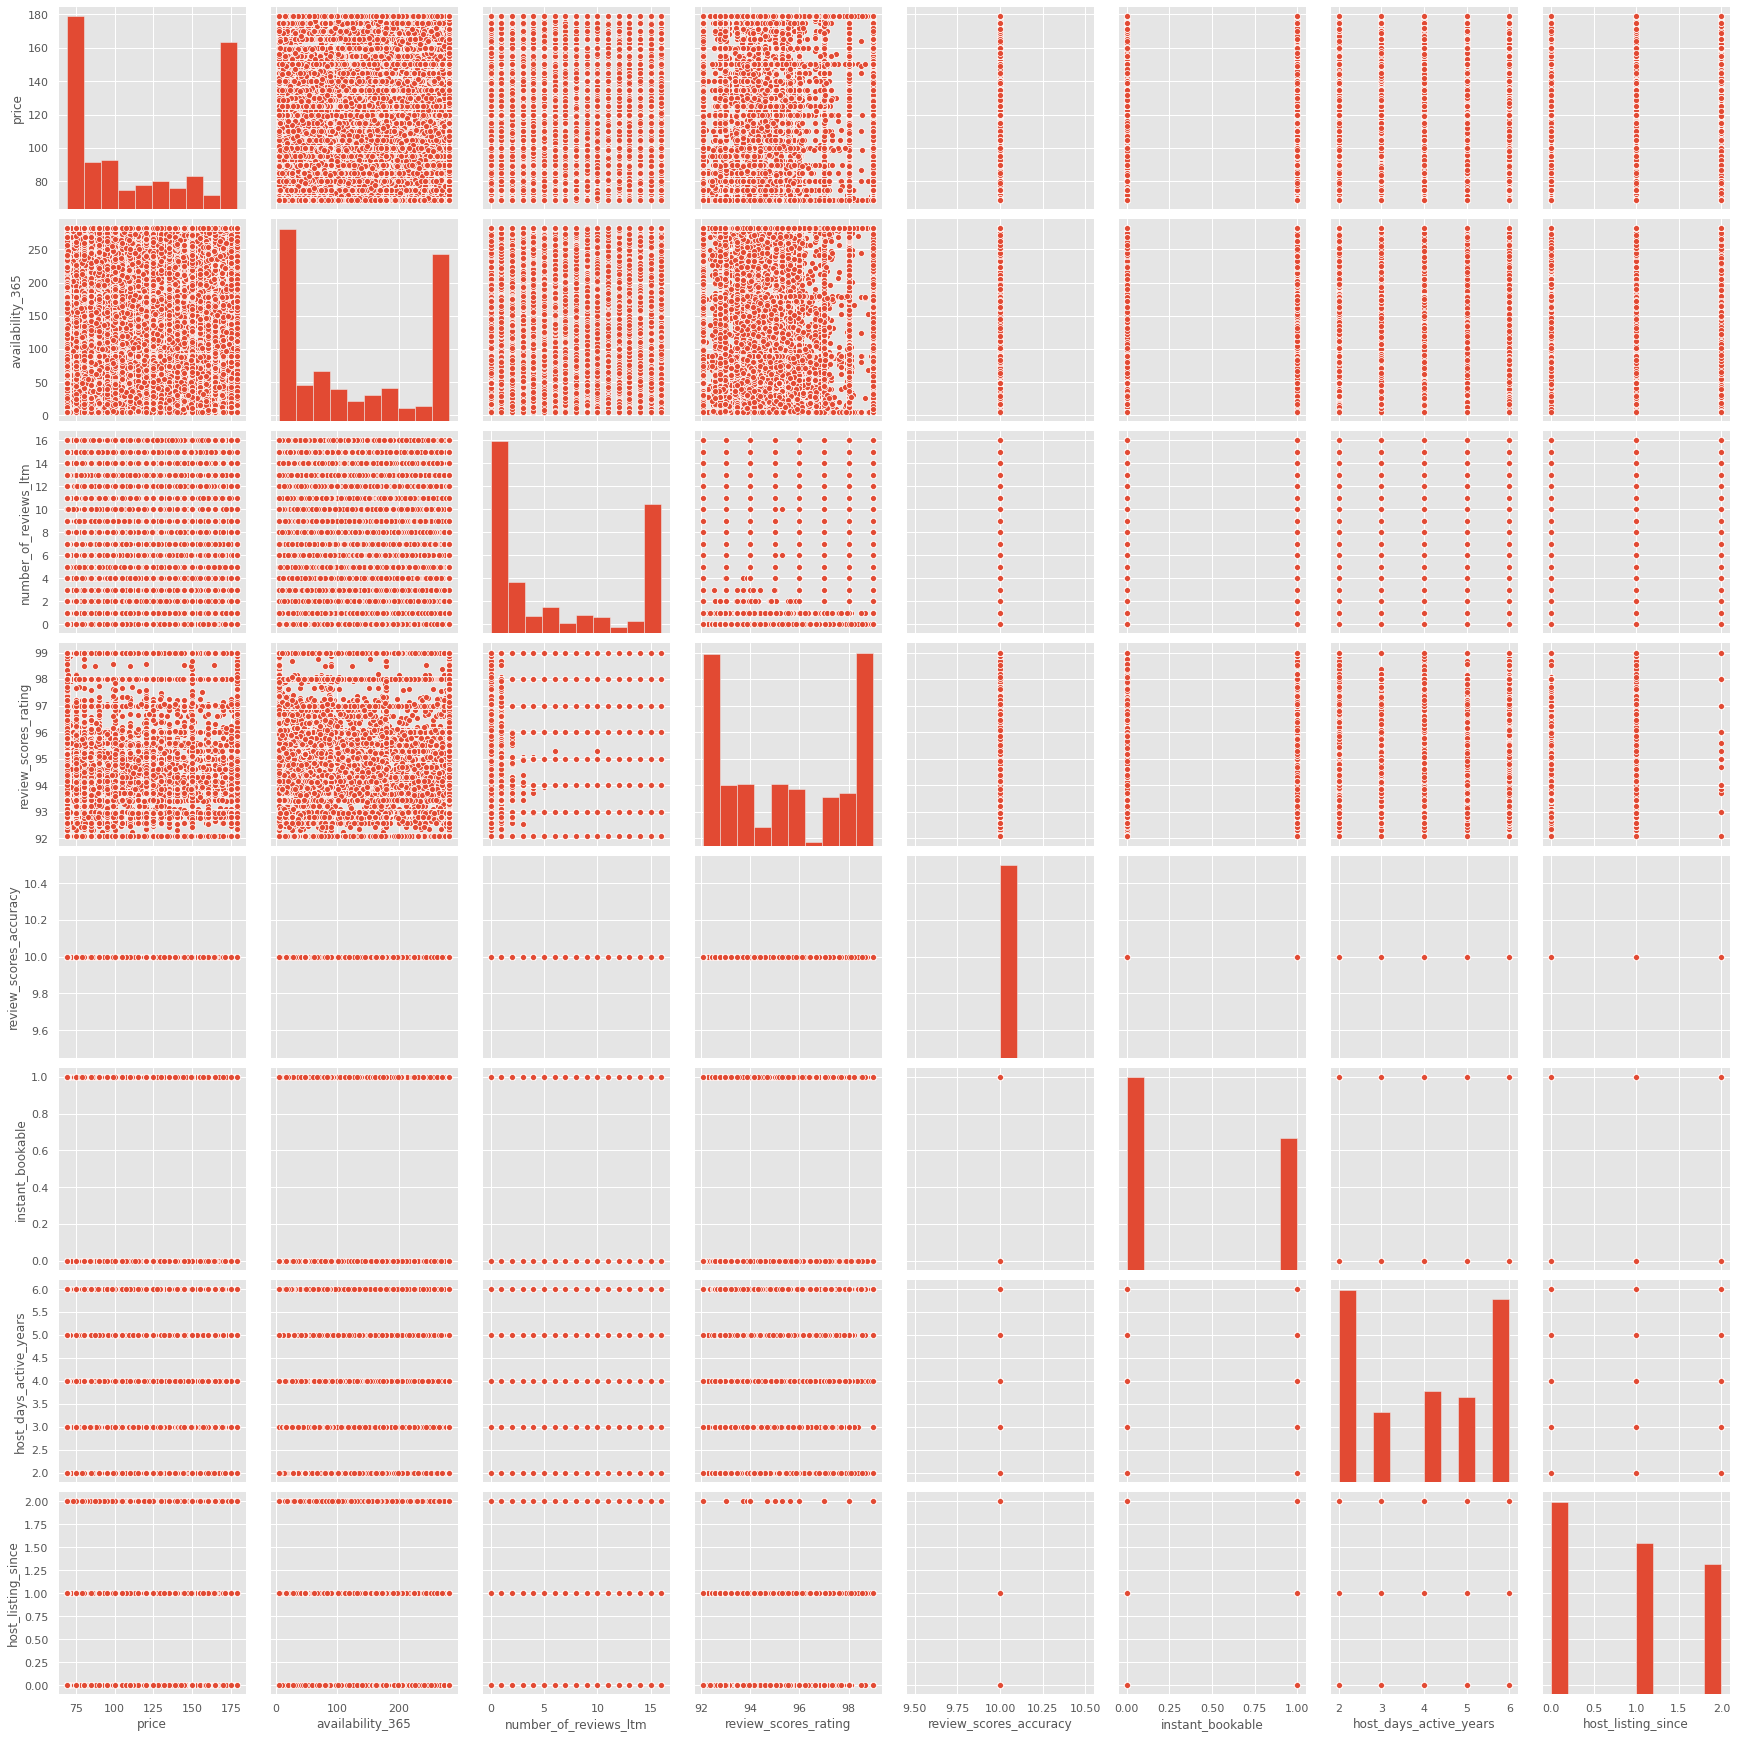

In [168]:
sns.pairplot(data=cap_df[num_columns1],height=3)
plt.show()

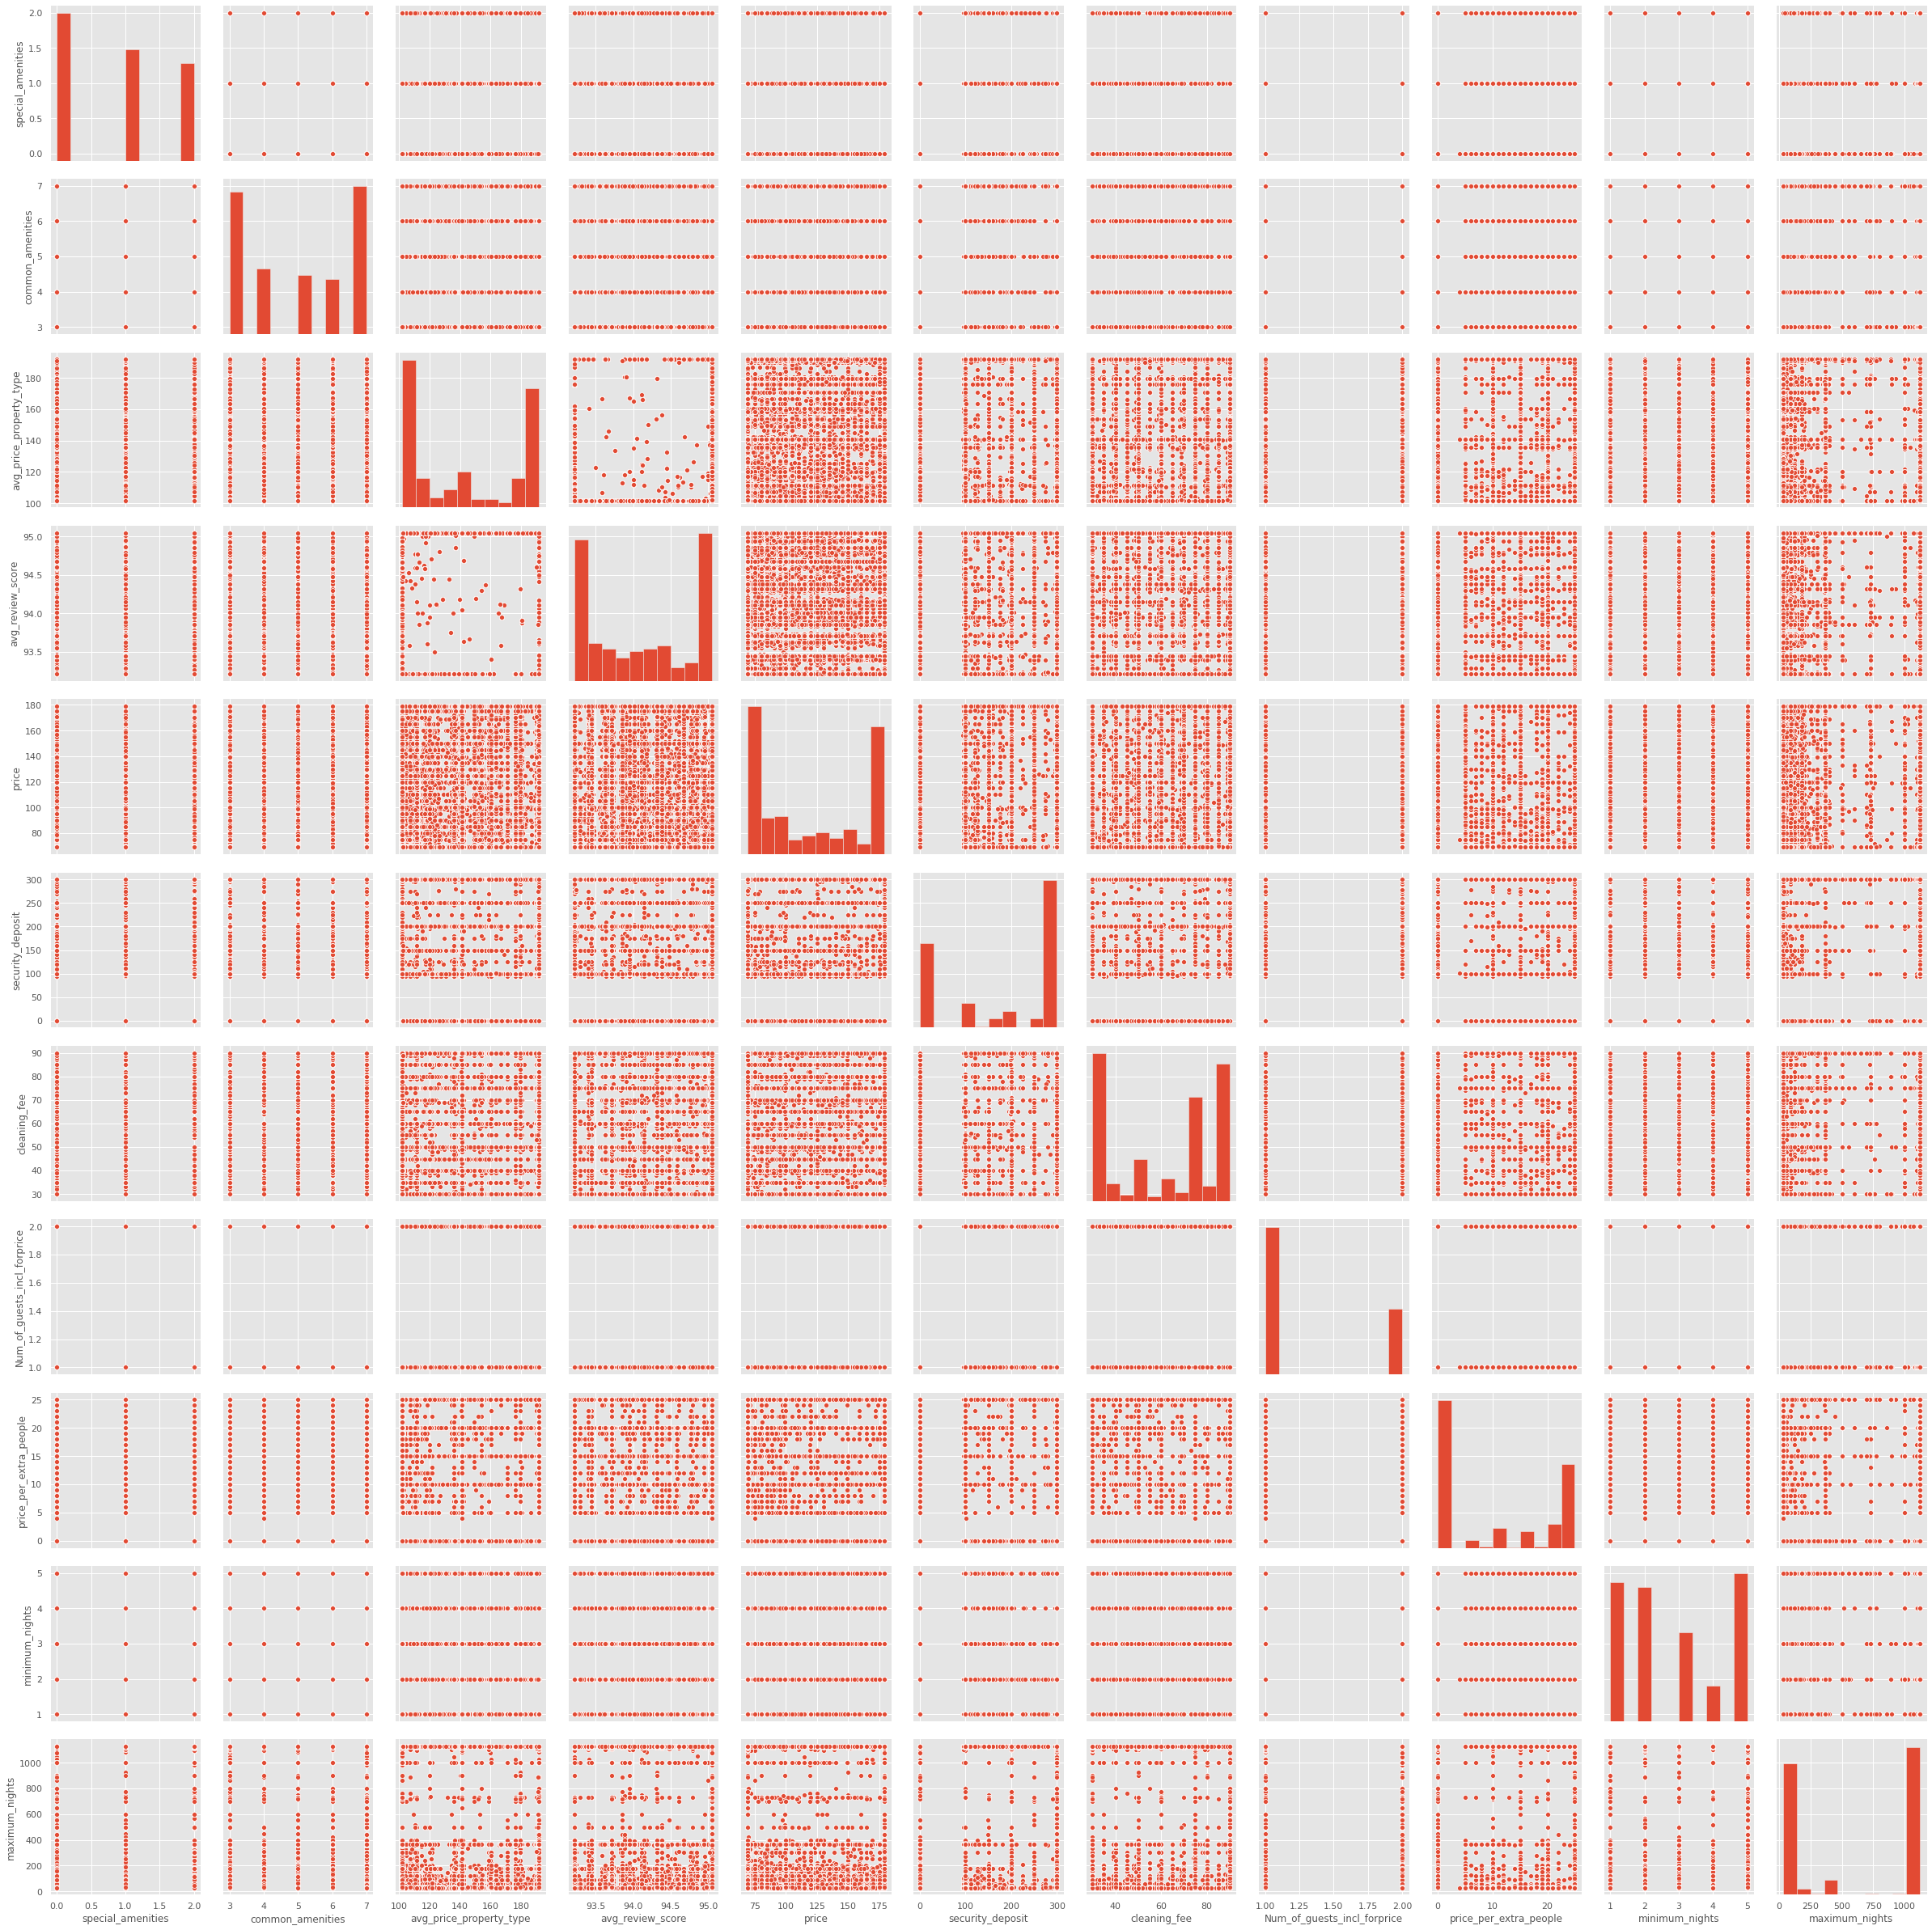

In [169]:
sns.pairplot(data=cap_df[num_columns2],height=3)
plt.show()

In [170]:
final_df = cap_df[numerical_types].drop(['latitude','longitude'],axis=1)

In [171]:
# Check the skew of all numerical features
skewed_feats = final_df.apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness.head(10)


Skew in numerical features: 



,Skew
Num_of_guests_incl_forprice,0.827106
accommodates,0.599673
host_total_listings_count,0.583877
beds,0.566903
number_of_reviews_ltm,0.485560
instant_bookable,0.383710
host_identity_verified,0.324994
price_per_extra_people,0.324438
minimum_nights,0.276248
special_amenities,0.264433


Lambda value used for Transformation: 0.22457076562319137


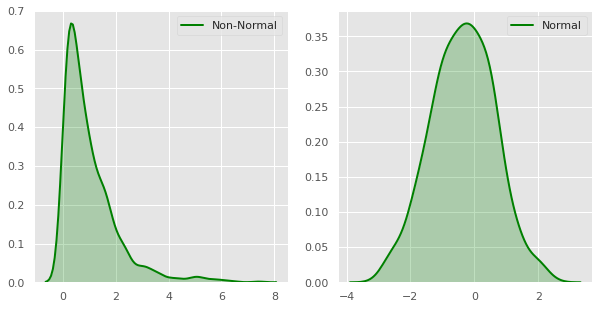

In [172]:
# import modules 
import numpy as np 
from scipy import stats 

# plotting modules 
import seaborn as sns 
import matplotlib.pyplot as plt 

# generate non-normal data (exponential) 
final_df = np.random.exponential(size = 1000) 

# transform training data & save lambda value 
fitted_data, fitted_lambda = stats.boxcox(final_df) 

# creating axes to draw plots 
fig, ax = plt.subplots(1, 2) 

# plotting the original data(non-normal) and 
# fitted data (normal) 
sns.distplot(final_df, hist = False, kde = True, 
	kde_kws = {'shade': True, 'linewidth': 2}, 
	label = "Non-Normal", color ="green", ax = ax[0]) 

sns.distplot(fitted_data, hist = False, kde = True, 
	kde_kws = {'shade': True, 'linewidth': 2}, 
	label = "Normal", color ="green", ax = ax[1]) 

# adding legends to the subplots 
plt.legend(loc = "upper right") 

# rescaling the subplots 
fig.set_figheight(5) 
fig.set_figwidth(10) 

print(f"Lambda value used for Transformation: {fitted_lambda}") 


In [173]:
# Check the skew of all numerical features
skewed_feats = pd.DataFrame(fitted_data).apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness.head(10)


Skew in numerical features: 



,Skew
0,-0.023943


### Encoding Categorical Vars

In [174]:
categorical_types

Index(['host_response_time', 'neighbourhood_cleansed', 'Borough',
       'property_type', 'room_type', 'bed_type', 'cancellation_policy'],
      dtype='object')

In [175]:
cap_df

,host_response_time,host_response_rate,host_is_superhost,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,Borough,latitude,longitude,property_type,...,review_scores_rating,review_scores_accuracy,instant_bookable,cancellation_policy,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type,avg_review_score
0,Days,100.0,0.0,3.0,1.0,Midtown,Manhattan,40.753620,-73.98338,Apartment,...,94.000000,10.0,0,strict,6.0,2.0,0.0,7.0,191.802083,93.215753
1,Hour,100.0,0.0,1.0,1.0,Clinton Hill,Brooklyn,40.689008,-73.95976,Other,...,92.071429,10.0,0,moderate,6.0,2.0,2.0,7.0,131.800000,95.049708
2,unknown,100.0,0.0,1.0,0.0,Murray Hill,Manhattan,40.747670,-73.97500,Apartment,...,92.071429,10.0,0,moderate,6.0,2.0,1.0,5.0,191.802083,93.215753
3,unknown,100.0,0.0,1.0,0.0,Bedford-Stuyvesant,Brooklyn,40.689008,-73.95596,Apartment,...,92.071429,10.0,0,strict,6.0,2.0,1.0,3.0,101.871920,93.443248
4,One Day,100.0,0.0,1.0,0.0,Hell's Kitchen,Manhattan,40.762880,-73.98338,Apartment,...,92.071429,10.0,0,strict,6.0,2.0,0.0,5.0,191.802083,93.215753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121671,Hour,100.0,0.0,3.0,0.0,Harlem,Manhattan,40.762880,-73.94634,Apartment,...,94.148853,10.0,1,flexible,2.0,1.0,0.0,3.0,111.263833,94.148853
121672,Hour,100.0,0.0,3.0,1.0,Upper West Side,Manhattan,40.762880,-73.98338,Apartment,...,93.856293,10.0,1,flexible,3.0,1.0,0.0,3.0,190.888803,93.856293
121673,unknown,100.0,0.0,1.0,0.0,West Village,Manhattan,40.736252,-73.98338,Apartment,...,95.270799,10.0,1,flexible,6.0,1.0,1.0,3.0,191.802083,95.049708
121674,unknown,100.0,0.0,2.0,0.0,Crown Heights,Brooklyn,40.689008,-73.95340,Apartment,...,94.385814,10.0,0,flexible,2.0,1.0,2.0,5.0,110.593761,94.385814


In [176]:
# # # Bin into 5 categories
cap_df['host_response_rate'].value_counts(bins=5,sort=False)

(99.899, 99.94]          0
(99.94, 99.98]           0
(99.98, 100.02]     121676
(100.02, 100.06]         0
(100.06, 100.1]          0
Name: host_response_rate, dtype: int64

In [177]:
# Bin into five categories
cap_df['host_response_rate_bins'] = pd.cut(cap_df.host_response_rate, bins=[50,60,70,80,100], labels=['49-60%', '50-89%', '90-99%', '100%'], include_lowest=True)

# Converting to string
cap_df['host_response_rate_bins'] = cap_df['host_response_rate_bins'].astype('str')

# Replace nulls with 'unknown'
#cap_df['host_response_rate_bins'].replace('nan', 'unknown', inplace=True)

# Category counts
cap_df['host_response_rate_bins'].value_counts()

100%    121676
Name: host_response_rate_bins, dtype: int64

In [178]:
dfe = pd.DataFrame(cap_df,columns = ['property_type','room_type','cancellation_policy','host_response_rate_bins','bed_type'])
dfe.head()

,property_type,room_type,cancellation_policy,host_response_rate_bins,bed_type
0,Apartment,Entire home/apt,strict,100%,Real Bed
1,Other,Entire home/apt,moderate,100%,Real Bed
2,Apartment,Entire home/apt,moderate,100%,Real Bed
3,Apartment,Private room,strict,100%,Futon
4,Apartment,Private room,strict,100%,Real Bed


In [179]:
cat_cols = dfe.select_dtypes(['object']).columns

In [180]:
for col in cat_cols:
    freqs = dfe[col].value_counts()
    k = freqs.index[freqs>20][:6]
    for cat in k:
        name = col+'_'+cat
        dfe[name]=(dfe[col]==cat).astype(int)
    del dfe[col]
    print(col)
    
print(dfe.dtypes)

property_type
room_type
cancellation_policy
host_response_rate_bins
bed_type
property_type_Apartment         int64
property_type_House             int64
property_type_Other             int64
property_type_Townhouse         int64
property_type_Condominium       int64
room_type_Entire home/apt       int64
room_type_Private room          int64
room_type_Shared room           int64
room_type_Hotel room            int64
cancellation_policy_strict      int64
cancellation_policy_flexible    int64
cancellation_policy_moderate    int64
host_response_rate_bins_100%    int64
bed_type_Real Bed               int64
bed_type_Futon                  int64
bed_type_Pull-out Sofa          int64
bed_type_Airbed                 int64
bed_type_Couch                  int64
dtype: object


In [181]:
abmen = pd.concat((dfe,cap_df),axis=1)
abmen.head(5)

,property_type_Apartment,property_type_House,property_type_Other,property_type_Townhouse,property_type_Condominium,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,room_type_Hotel room,cancellation_policy_strict,...,review_scores_accuracy,instant_bookable,cancellation_policy,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type,avg_review_score,host_response_rate_bins
0,1,0,0,0,0,1,0,0,0,1,...,10.0,0,strict,6.0,2.0,0.0,7.0,191.802083,93.215753,100%
1,0,0,1,0,0,1,0,0,0,0,...,10.0,0,moderate,6.0,2.0,2.0,7.0,131.800000,95.049708,100%
2,1,0,0,0,0,1,0,0,0,0,...,10.0,0,moderate,6.0,2.0,1.0,5.0,191.802083,93.215753,100%
3,1,0,0,0,0,0,1,0,0,1,...,10.0,0,strict,6.0,2.0,1.0,3.0,101.871920,93.443248,100%
4,1,0,0,0,0,0,1,0,0,1,...,10.0,0,strict,6.0,2.0,0.0,5.0,191.802083,93.215753,100%


In [182]:
final_df = pd.DataFrame()
final_df = abmen.copy()

In [183]:
final_df.drop(['host_response_time', 'host_response_rate','host_response_rate_bins', 'neighbourhood_cleansed',
       'Borough', 'property_type', 'room_type', 'bed_type',
       'cancellation_policy'],axis=1,inplace=True)

In [184]:
final_df.columns

Index(['property_type_Apartment', 'property_type_House', 'property_type_Other',
       'property_type_Townhouse', 'property_type_Condominium',
       'room_type_Entire home/apt', 'room_type_Private room',
       'room_type_Shared room', 'room_type_Hotel room',
       'cancellation_policy_strict', 'cancellation_policy_flexible',
       'cancellation_policy_moderate', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Futon', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'latitude',
       'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'security_deposit', 'cleaning_fee', 'Num_of_guests_incl_forprice',
       'price_per_extra_people', 'minimum_nights', 'maximum_nights',
       'availability_365', 'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host

In [185]:
# seperating categorical and numerical dtypes
categorical_cols=final_df.select_dtypes(include=['object']).columns
print('categorical_types: \n',categorical_cols)

print('-------------')

numerical_cols=final_df._get_numeric_data().columns
print('numerical_types: \n',numerical_cols)

categorical_types: 
 Index([], dtype='object')
-------------
numerical_types: 
 Index(['property_type_Apartment', 'property_type_House', 'property_type_Other',
       'property_type_Townhouse', 'property_type_Condominium',
       'room_type_Entire home/apt', 'room_type_Private room',
       'room_type_Shared room', 'room_type_Hotel room',
       'cancellation_policy_strict', 'cancellation_policy_flexible',
       'cancellation_policy_moderate', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Futon', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'latitude',
       'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'security_deposit', 'cleaning_fee', 'Num_of_guests_incl_forprice',
       'price_per_extra_people', 'minimum_nights', 'maximum_nights',
       'availability_365', 'number_of_reviews_ltm', 'review_scores_rating',
       'rev

In [186]:
final_df.drop(['longitude','latitude'],axis=1,inplace=True)

##  IV. Feature Selection

#### RFE 

In [187]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso

In [188]:
# Getting Data Ready
X = final_df.drop('price', axis=1)
y= final_df['price']

In [189]:
model = LinearRegression()

In [190]:
#Initializing RFE model
rfe = RFE(model, 40)

In [191]:
#Transforming data using RFE
X_rfe = rfe.fit_transform(X,y)  
#Fitting the data to model
model.fit(X_rfe,y)
print(rfe.support_)
print(rfe.ranking_)

LinearRegression()

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True  True  True  True  True  True False  True
  True  True  True  True  True  True]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 3 1 1
 1 1 1 1 1]


In [192]:
X.columns

Index(['property_type_Apartment', 'property_type_House', 'property_type_Other',
       'property_type_Townhouse', 'property_type_Condominium',
       'room_type_Entire home/apt', 'room_type_Private room',
       'room_type_Shared room', 'room_type_Hotel room',
       'cancellation_policy_strict', 'cancellation_policy_flexible',
       'cancellation_policy_moderate', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Futon', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'security_deposit', 'cleaning_fee',
       'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenitie

In [193]:
X.drop(['bedrooms', 'review_scores_accuracy'],axis=1,inplace=True)

In [194]:
#no of features
nof_list=np.arange(1,47)            
high_score=0
#Variable to store the optimum features
nof=0           
score_list =[]
for n in range(len(nof_list)):
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 0)
    model = LinearRegression()
    rfe = RFE(model,nof_list[n])
    X_train_rfe = rfe.fit_transform(X_train,y_train)
    X_test_rfe = rfe.transform(X_test)
    model.fit(X_train_rfe,y_train)
    score = model.score(X_test_rfe,y_test)
    score_list.append(score)
    if(score>high_score):
        high_score = score
        nof = nof_list[n]
print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

LinearRegression()

LinearRegression()

LinearRegression()

LinearRegression()

LinearRegression()

...

LinearRegression()

LinearRegression()

LinearRegression()

LinearRegression()

Optimum number of features: 35
Score with 35 features: 0.642588


## V. Model Building

In [195]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso

In [196]:
## Raw linear regression model
X = final_df.drop('price', axis=1)
y= final_df['price']
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f'Coefficients: {lin_reg.coef_}')
print(f'Intercept: {lin_reg.intercept_}')
print(f'R^2 score: {lin_reg.score(X, y)}')

LinearRegression()

Coefficients: [ 1.66634075e-01 -1.35321530e+00  4.33469412e+00 -5.34274847e+00
  2.19463558e+00  2.18225219e+01 -1.21685138e+01 -2.31322463e+01
  1.34782382e+01 -4.55588317e-01  5.02522878e-01 -4.69345615e-02
 -6.28830321e-13  3.41223451e+00 -3.43381547e+00 -2.87236412e-01
  1.45722007e+00 -1.14840269e+00  0.00000000e+00 -1.19998636e+00
 -9.54009798e-02  8.12466719e+00  8.88178420e-16  2.66453526e-15
  3.81697058e+00  1.49435553e-03  2.63588858e-01  3.43330718e+00
 -9.29797109e-02 -2.04087440e+00  1.29592883e-04  1.80106146e-02
 -3.32176245e-01  6.45602101e-01  0.00000000e+00  2.93625027e-01
  2.91233568e-01 -1.37856908e-01  1.68509553e+00  8.55414612e-01
  4.15381735e-01 -5.34732033e-01]
Intercept: -7.368685365013178
R^2 score: 0.6416348229921242


In [197]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size = 0.30, random_state = 1)
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)

(85173, 42)
(36503, 42)
(36503,)


In [198]:
lin_reg = LinearRegression()
model = lin_reg.fit(X_train,y_train)
print(f'R^2 score for train: {lin_reg.score(X_train, y_train)}')
print(f'R^2 score for test: {lin_reg.score(X_test, y_test)}')

R^2 score for train: 0.6417653737540834
R^2 score for test: 0.6412206218294143


In [199]:
## Raw OLS Model
X = final_df.drop(['price'],axis=1)
y = final_df.price
X_constant = sm.add_constant(X)
lin_reg = sm.OLS(y,X_constant).fit()
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     6600.
Date:                Wed, 02 Sep 2020   Prob (F-statistic):               0.00
Time:                        04:55:50   Log-Likelihood:            -5.7318e+05
No. Observations:              121676   AIC:                         1.146e+06
Df Residuals:                  121642   BIC:                         1.147e+06
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
property_type_Apartment          0.1525      0.159      0.961      0.337      -0.159       0.464
property_type_House             -1.3674      0.251     -5.444      0.000      -1.860      -0.875
property_type_Other              4.3205      0.273     15.817      0.000       3.785       4.856
property_type_Townhouse         -5.3569      0.337    -15.873      0.000      -6.018      -4.695
property_type_Condominium        2.1805      0.355      6.134      0.000       1.484       2.877
room_type_Entire home/apt       21.8048      0.290     75.199      0.000      21.236      22.373
room_type_Private room         -12.1862      0.271    -44.918      0.000     -12.718     -11.654
room_type_Shared room          -23.1500      0.431    -53.688      0.000     -23.995     -22.305
room_type_Hotel room            13.4605      0.654     20.575      0.000      12.178      14.743
cancellation_policy_strict      -0.4792      0.114     -4.212      0.000      -0.702      -0.256
cancellation_policy_flexible     0.4789      0.133      3.596      0.000       0.218       0.740
cancellation_policy_moderate    -0.0706      0.130     -0.544      0.586      -0.325       0.184
host_response_rate_bins_100%    -0.0709      0.101     -0.704      0.481      -0.268       0.126
bed_type_Real Bed                3.3981      0.653      5.203      0.000       2.118       4.678
bed_type_Futon                  -3.4480      1.072     -3.216      0.001      -5.549      -1.346
bed_type_Pull-out Sofa          -0.3014      1.123     -0.268      0.788      -2.502       1.899
bed_type_Airbed                  1.4430      1.368      1.055      0.291      -1.238       4.124
bed_type_Couch                  -1.1626      1.894     -0.614      0.539      -4.876       2.551
host_is_superhost             2.196e-15   8.52e-16      2.578      0.010    5.27e-16    3.87e-15
host_total_listings_count       -1.2000      0.099    -12.072      0.000      -1.395      -1.005
host_identity_verified          -0.0954      0.183     -0.521      0.603      -0.455       0.264
accommodates                     8.1247      0.139     58.259      0.000       7.851       8.398
bathrooms                       -0.0709      0.101     -0.704      0.481      -0.268       0.126
bedrooms                        -0.0709      0.101     -0.704      0.481      -0.268       0.126
beds                             3.8170      0.235     16.260      0.000       3.357       4.277
security_deposit                 0.0015      0.001      2.358      0.018       0.000       0.003
cleaning_fee                     0.2636      0.004     63.994      0.000       0.256       0.272
Num_of_guests_incl_forprice      3.4333      0.218     15.743      0.000       3.006       3.861
price_per_extra_people          -0.0930      0.009    -10.796      0.000    

In [200]:
##### Assumption 1- No autocorrelation

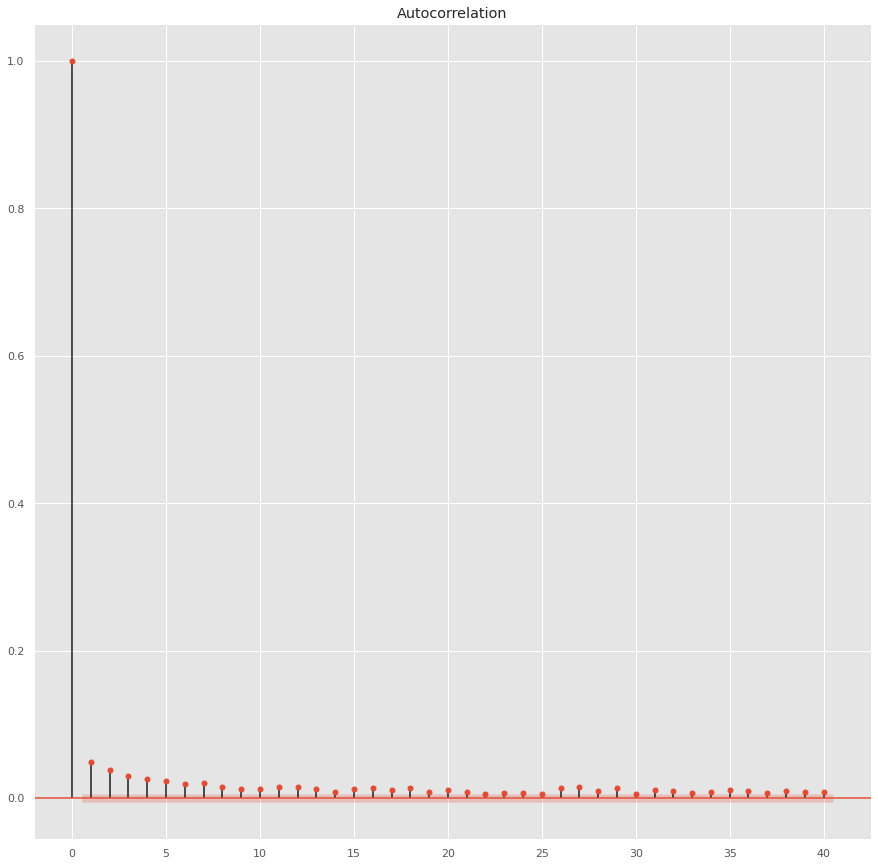

In [201]:
import statsmodels.tsa.api as smt

acf = smt.graphics.plot_acf(lin_reg.resid, lags=40 , alpha=0.05)
acf.show()

In [202]:
##### Assumption 2- Normality of Residuals
from scipy import stats
print(stats.jarque_bera(lin_reg.resid))

(3397.6663813313294, 0.0)


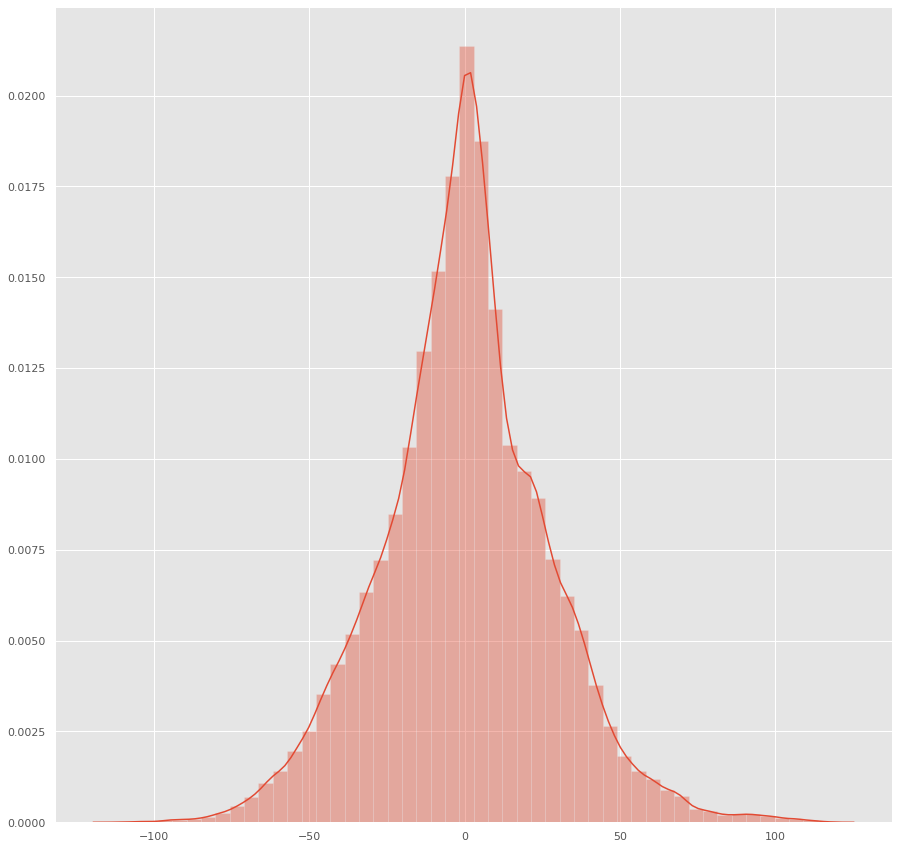

In [203]:
import seaborn as sns

sns.distplot(lin_reg.resid)

##### Asssumption 3 - Linearity of residuals
Here we have 2 options. Either we can plot the observed values Vs predicted values and plot the Residual Vs predicted values and see the linearity of residuals.
OR
We can go for rainbow test. Let's look both of them one by one.

#### Rainbow test 
It is done to check the linearity of the residuals for a linear regression model.
Linearity of residuals is preferred.


In [204]:
import statsmodels.api as sm
sm.stats.diagnostic.linear_rainbow(res=lin_reg, frac=0.5)

(0.9870714499932055, 0.9457089018282875)

((array([-4.38888568, -4.1919612 , -4.08491805, ...,  4.08491805,
          4.1919612 ,  4.38888568]),
  array([-4.18707297, -4.09363663, -4.08426224, ...,  4.37757429,
          4.38147697,  4.40230132])),
 (0.9962365393285997, -5.561933527135116e-07, 0.9961951265369765))

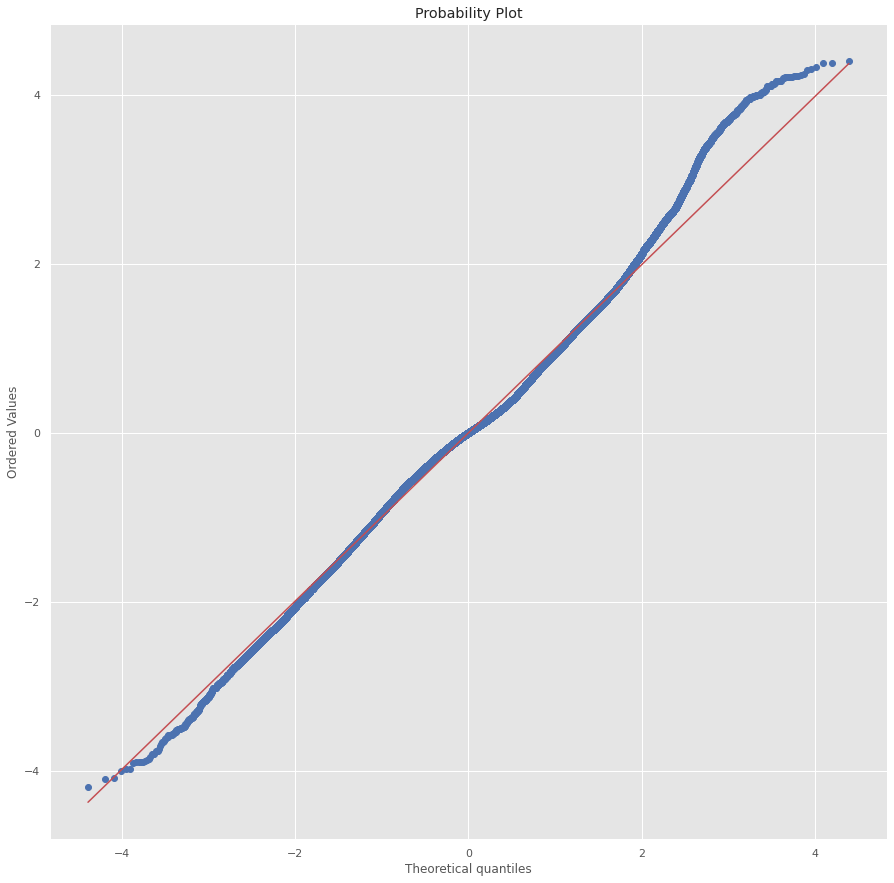

In [205]:
import scipy.stats as stats
import pylab
from statsmodels.graphics.gofplots import ProbPlot
st_residual = lin_reg.get_influence().resid_studentized_internal
stats.probplot(st_residual, dist="norm", plot = pylab)
plt.show()

In [206]:
lin_reg.resid.mean()

7.088173588845645e-13

very close to 0 so linearity is present.

In [207]:
##### Assumption 4 -  Homoscedasticity_test(using goldfeld test) OR (Beusch-Wagon Test)

# goldfeld test
from statsmodels.compat import lzip
import numpy as np
from statsmodels.compat import lzip
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms

model = lin_reg
fitted_vals = model.predict()
resids = model.resid
resids_standardized = model.get_influence().resid_studentized_internal

name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(model.resid, model.model.exog)
lzip(name, test)

[('F statistic', 0.9644340487788085), ('p-value', 0.9999959918299126)]

In [208]:
##### Assumption 4 -  Homoscedasticity_test(using goldfeld test) OR (Beusch-Wagon Test)

##### breuschpagan Test
import statsmodels.api as sm
from statsmodels.compat import lzip
name = ['Lagrange multiplier statistic', 'p-value',
        'f-value', 'f p-value']
test = sms.het_breuschpagan(lin_reg.resid, lin_reg.model.exog)
lzip(name, test)

[('Lagrange multiplier statistic', 2995.7199915015685),
 ('p-value', 0.0),
 ('f-value', 93.04483445319447),
 ('f p-value', 0.0)]

#### so from above p- value we know that the data is heteroscedastic

##### Assumption 5- NO  MULTI COLLINEARITY

In [209]:
X.shape

(121676, 42)

In [210]:
##### Assumption 5- NO  MULTI COLLINEARITY
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]
pd.DataFrame({'vif': vif[0:]}, index=X.columns).T

,property_type_Apartment,property_type_House,property_type_Other,property_type_Townhouse,property_type_Condominium,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,room_type_Hotel room,cancellation_policy_strict,...,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,instant_bookable,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type,avg_review_score
vif,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,1.497424,1.163741,0.0,1.12778,1.591821,1.355329,1.155556,1.476945,1.258324,1.156665


#So, multicollinearity exists.
Note : This vif column has be built with the help of X_constant and not the X_values. Because we built our model by adding Constant.

In [211]:
dict(pd.DataFrame({'vif': vif[0:]}, index=X.columns).T)

{'property_type_Apartment': vif    inf
 Name: property_type_Apartment, dtype: float64,
 'property_type_House': vif    inf
 Name: property_type_House, dtype: float64,
 'property_type_Other': vif    inf
 Name: property_type_Other, dtype: float64,
 'property_type_Townhouse': vif    inf
 Name: property_type_Townhouse, dtype: float64,
 'property_type_Condominium': vif    inf
 Name: property_type_Condominium, dtype: float64,
 'room_type_Entire home/apt': vif    inf
 Name: room_type_Entire home/apt, dtype: float64,
 'room_type_Private room': vif    inf
 Name: room_type_Private room, dtype: float64,
 'room_type_Shared room': vif    inf
 Name: room_type_Shared room, dtype: float64,
 'room_type_Hotel room': vif    inf
 Name: room_type_Hotel room, dtype: float64,
 'cancellation_policy_strict': vif    inf
 Name: cancellation_policy_strict, dtype: float64,
 'cancellation_policy_flexible': vif    inf
 Name: cancellation_policy_flexible, dtype: float64,
 'cancellation_policy_moderate': vif    inf
 Na

In [212]:
final_df.columns

Index(['property_type_Apartment', 'property_type_House', 'property_type_Other',
       'property_type_Townhouse', 'property_type_Condominium',
       'room_type_Entire home/apt', 'room_type_Private room',
       'room_type_Shared room', 'room_type_Hotel room',
       'cancellation_policy_strict', 'cancellation_policy_flexible',
       'cancellation_policy_moderate', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Futon', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special

In [213]:
##  removed like correlated variables
X = final_df[['property_type_Apartment', 'property_type_House', 'property_type_Other',
       'property_type_Townhouse', 'property_type_Condominium',
       'room_type_Entire home/apt', 'room_type_Private room',
       'room_type_Shared room', 'room_type_Hotel room',
       'cancellation_policy_strict', 'cancellation_policy_flexible', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score']]
y = final_df['price']
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f'Coefficients: {lin_reg.coef_}')
print(f'Intercept: {lin_reg.intercept_}')
print(f'R^2 score: {lin_reg.score(X, y)}')

LinearRegression()

Coefficients: [ 1.66634075e-01 -1.35321530e+00  4.33469412e+00 -5.34274847e+00
  2.19463558e+00  2.18225219e+01 -1.21685138e+01 -2.31322463e+01
  1.34782382e+01 -4.08653756e-01  5.49457440e-01 -1.26210153e-12
  6.84604998e+00  3.14657906e+00  4.89103554e+00  2.28541279e+00
  1.85451654e-12 -1.19998636e+00 -9.54009798e-02  8.12466719e+00
  2.66453526e-15 -7.10542736e-15  3.81697058e+00  1.49435553e-03
  2.63588858e-01  3.43330718e+00 -9.29797109e-02 -2.04087440e+00
  1.29592883e-04  1.80106146e-02 -3.32176245e-01  6.45602101e-01
 -4.44089210e-16  2.93625027e-01  2.91233568e-01 -1.37856908e-01
  1.68509553e+00  8.55414612e-01  4.15381735e-01 -5.34732033e-01]
Intercept: -10.849435401427215
R^2 score: 0.6416348229921242


In [214]:
import warnings 
warnings.filterwarnings('ignore')
import statsmodels.api as sm

X_constant = sm.add_constant(X)
lin_reg = sm.OLS(y,X_constant).fit()
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     6600.
Date:                Wed, 02 Sep 2020   Prob (F-statistic):               0.00
Time:                        04:56:09   Log-Likelihood:            -5.7318e+05
No. Observations:              121676   AIC:                         1.146e+06
Df Residuals:                  121642   BIC:                         1.147e+06
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
property_type_Apartment          0.1457      0.159      0.918      0.359      -0.165       0.457
property_type_House             -1.3742      0.251     -5.471      0.000      -1.866      -0.882
property_type_Other              4.3137      0.273     15.792      0.000       3.778       4.849
property_type_Townhouse         -5.3637      0.337    -15.893      0.000      -6.025      -4.702
property_type_Condominium        2.1737      0.356      6.114      0.000       1.477       2.870
room_type_Entire home/apt       21.7963      0.290     75.176      0.000      21.228      22.365
room_type_Private room         -12.1947      0.271    -44.953      0.000     -12.726     -11.663
room_type_Shared room          -23.1585      0.431    -53.694      0.000     -24.004     -22.313
room_type_Hotel room            13.4520      0.654     20.562      0.000      12.170      14.734
cancellation_policy_strict      -0.4087      0.196     -2.083      0.037      -0.793      -0.024
cancellation_policy_flexible     0.5495      0.229      2.399      0.016       0.101       0.998
host_response_rate_bins_100%    -0.1049      0.101     -1.033      0.301      -0.304       0.094
bed_type_Real Bed                6.8460      1.114      6.145      0.000       4.663       9.030
bed_type_Pull-out Sofa           3.1466      1.624      1.938      0.053      -0.036       6.329
bed_type_Airbed                  4.8910      1.912      2.558      0.011       1.144       8.638
bed_type_Couch                   2.2854      2.552      0.896      0.371      -2.716       7.287
host_is_superhost             2.096e-13   3.33e-13      0.629      0.530   -4.44e-13    8.63e-13
host_total_listings_count       -1.2000      0.099    -12.072      0.000      -1.395      -1.005
host_identity_verified          -0.0954      0.183     -0.521      0.603      -0.455       0.264
accommodates                     8.1247      0.139     58.259      0.000       7.851       8.398
bathrooms                       -0.1049      0.101     -1.033      0.301      -0.304       0.094
bedrooms                        -0.1049      0.101     -1.033      0.301      -0.304       0.094
beds                             3.8170      0.235     16.260      0.000       3.357       4.277
security_deposit                 0.0015      0.001      2.358      0.018       0.000       0.003
cleaning_fee                     0.2636      0.004     63.994      0.000       0.256       0.272
Num_of_guests_incl_forprice      3.4333      0.218     15.743      0.000       3.006       3.861
price_per_extra_people          -0.0930      0.009    -10.796      0.000      -0.110      -0.076
minimum_nights                  -2.0409      0.057    -35.775      0.000      -2.153      -1.929
maximum_nights                   0.0001      0.000      0.854      0.393    

In [215]:
# remove 4 more parameters from the input
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]
pd.DataFrame({'vif': vif[0:]}, index=X.columns).T

,property_type_Apartment,property_type_House,property_type_Other,property_type_Townhouse,property_type_Condominium,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,room_type_Hotel room,cancellation_policy_strict,...,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,instant_bookable,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type,avg_review_score
vif,inf,inf,inf,inf,inf,inf,inf,inf,inf,1.618618,...,1.497424,1.163741,0.0,1.12778,1.591821,1.355329,1.155556,1.476945,1.258324,1.156665


In [216]:
##  removed like correlated variables
X = final_df[['room_type_Entire home/apt', 'room_type_Private room',
       'room_type_Shared room', 'room_type_Hotel room',
       'cancellation_policy_strict', 'cancellation_policy_flexible', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 
       'host_total_listings_count',  'accommodates',
       'bathrooms', 'bedrooms', 'beds',  'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score']]
y = final_df['price']
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f'Coefficients: {lin_reg.coef_}')
print(f'Intercept: {lin_reg.intercept_}')
print(f'R^2 score: {lin_reg.score(X, y)}')

LinearRegression()

Coefficients: [-6.05413312e+10 -6.05413313e+10 -6.05413313e+10 -6.05413312e+10
 -4.44709794e-01  5.62847411e-01 -2.64129639e-02  6.71720574e+00
  3.18127758e+00  4.74089052e+00  2.26816292e+00 -1.25680028e+00
  8.08544106e+00  1.05209351e-02  2.90679932e-03  3.66906284e+00
  1.62088584e-03  2.63452723e-01  3.34112339e+00 -9.40152876e-02
 -2.08189350e+00  6.88803275e-05  1.84519570e-02 -3.47454267e-01
  6.35332622e-01 -5.96046448e-08  3.79916683e-01  2.78312288e-01
 -2.12873491e-01  1.70734767e+00  8.83113451e-01  4.21026634e-01
 -4.14658075e-01]
Intercept: 60541331236.79829
R^2 score: 0.6403415305465902


In [217]:
import warnings 
warnings.filterwarnings('ignore')
import statsmodels.api as sm

X_constant = sm.add_constant(X)
lin_reg = sm.OLS(y,X_constant).fit()
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     7735.
Date:                Wed, 02 Sep 2020   Prob (F-statistic):               0.00
Time:                        04:56:20   Log-Likelihood:            -5.7340e+05
No. Observations:              121676   AIC:                         1.147e+06
Df Residuals:                  121647   BIC:                         1.147e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
room_type_Entire home/apt       20.9409      0.282     74.345      0.000      20.389      21.493
room_type_Private room         -13.3676      0.262    -50.928      0.000     -13.882     -12.853
room_type_Shared room          -24.1107      0.427    -56.478      0.000     -24.947     -23.274
room_type_Hotel room            16.3418      0.626     26.103      0.000      15.115      17.569
cancellation_policy_strict      -0.4426      0.196     -2.256      0.024      -0.827      -0.058
cancellation_policy_flexible     0.5574      0.229      2.433      0.015       0.108       1.006
host_response_rate_bins_100%    -0.1956      0.099     -1.974      0.048      -0.390      -0.001
bed_type_Real Bed                6.7989      1.116      6.093      0.000       4.612       8.986
bed_type_Pull-out Sofa           3.2866      1.626      2.021      0.043       0.099       6.475
bed_type_Airbed                  4.8637      1.915      2.540      0.011       1.110       8.617
bed_type_Couch                   2.4383      2.556      0.954      0.340      -2.572       7.449
host_total_listings_count       -1.2602      0.099    -12.781      0.000      -1.453      -1.067
accommodates                     8.0812      0.140     57.913      0.000       7.808       8.355
bathrooms                       -0.1956      0.099     -1.974      0.048      -0.390      -0.001
bedrooms                        -0.1956      0.099     -1.974      0.048      -0.390      -0.001
beds                             3.6703      0.235     15.628      0.000       3.210       4.131
security_deposit                 0.0016      0.001      2.531      0.011       0.000       0.003
cleaning_fee                     0.2635      0.004     63.936      0.000       0.255       0.272
Num_of_guests_incl_forprice      3.3486      0.218     15.334      0.000       2.921       3.777
price_per_extra_people          -0.0942      0.009    -10.926      0.000      -0.111      -0.077
minimum_nights                  -2.0816      0.057    -36.494      0.000      -2.193      -1.970
maximum_nights                7.059e-05      0.000      0.466      0.641      -0.000       0.000
availability_365                 0.0185      0.001     23.928      0.000       0.017       0.020
number_of_reviews_ltm           -0.3477      0.014    -24.574      0.000      -0.375      -0.320
review_scores_rating             0.6353      0.030     20.882      0.000       0.576       0.695
review_scores_accuracy          -1.9556      0.991     -1.974      0.048      -3.898      -0.014
instant_bookable                 0.3777      0.167      2.267      0.023       0.051       0.704
host_days_active_years           0.2770      0.054      5.105      0.000       0.171       0.383
host_listing_since              -0.2132      0.110     -1.946      0.052    

In [218]:
# remove 4 more parameters from the input
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]
pd.DataFrame({'vif': vif[0:]}, index=X.columns).T

,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,room_type_Hotel room,cancellation_policy_strict,cancellation_policy_flexible,host_response_rate_bins_100%,bed_type_Real Bed,bed_type_Pull-out Sofa,bed_type_Airbed,...,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,instant_bookable,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type,avg_review_score
vif,inf,inf,inf,inf,1.613048,1.679105,0.0,2.608615,1.86182,1.50221,...,1.493084,1.161002,0.0,1.122223,1.314475,1.337813,1.151642,1.471714,1.200334,1.103521


In [219]:
##  removed like correlated variables
X = final_df[['room_type_Entire home/apt',
       'room_type_Shared room',
       'cancellation_policy_strict', 'cancellation_policy_flexible', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 
       'host_total_listings_count',  'accommodates',
       'bathrooms', 'bedrooms', 'beds',  'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score']]
y = final_df['price']
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f'Coefficients: {lin_reg.coef_}')
print(f'Intercept: {lin_reg.intercept_}')
print(f'R^2 score: {lin_reg.score(X, y)}')

LinearRegression()

Coefficients: [ 3.35190034e+01 -1.15956656e+01 -7.05196113e-01  9.42494858e-01
 -1.45661261e-13  6.74194401e+00  3.30540299e+00  4.59615528e+00
  2.25253047e+00 -9.72529670e-01  8.20531026e+00 -1.06581410e-14
 -2.08721929e-14  3.68144535e+00  9.97247172e-04  2.56578829e-01
  4.15032092e+00 -1.12643646e-01 -2.22959803e+00 -6.10451986e-05
  2.03370794e-02 -3.69081996e-01  6.09746691e-01 -1.11022302e-15
  6.18873091e-01  2.06476090e-01 -2.53596625e-01  1.85684328e+00
  9.16073574e-01  4.33605207e-01 -5.79026827e-01]
Intercept: -17.397465131805276
R^2 score: 0.6365364821796806


In [220]:
import warnings 
warnings.filterwarnings('ignore')
import statsmodels.api as sm

X_constant = sm.add_constant(X)
lin_reg = sm.OLS(y,X_constant).fit()
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     7890.
Date:                Wed, 02 Sep 2020   Prob (F-statistic):               0.00
Time:                        04:56:28   Log-Likelihood:            -5.7404e+05
No. Observations:              121676   AIC:                         1.148e+06
Df Residuals:                  121648   BIC:                         1.148e+06
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
room_type_Entire home/apt       33.5190      0.220    152.146      0.000      33.087      33.951
room_type_Shared room          -11.5957      0.510    -22.745      0.000     -12.595     -10.596
cancellation_policy_strict      -0.7052      0.197     -3.578      0.000      -1.091      -0.319
cancellation_policy_flexible     0.9425      0.230      4.097      0.000       0.492       1.393
host_response_rate_bins_100%    -0.1689      0.100     -1.692      0.091      -0.365       0.027
bed_type_Real Bed                6.7419      1.122      6.010      0.000       4.543       8.941
bed_type_Pull-out Sofa           3.3054      1.635      2.022      0.043       0.101       6.510
bed_type_Airbed                  4.5962      1.925      2.387      0.017       0.823       8.370
bed_type_Couch                   2.2525      2.570      0.876      0.381      -2.784       7.290
host_total_listings_count       -0.9725      0.099     -9.845      0.000      -1.166      -0.779
accommodates                     8.2053      0.140     58.512      0.000       7.930       8.480
bathrooms                       -0.1689      0.100     -1.692      0.091      -0.365       0.027
bedrooms                        -0.1689      0.100     -1.692      0.091      -0.365       0.027
beds                             3.6814      0.236     15.594      0.000       3.219       4.144
security_deposit                 0.0010      0.001      1.564      0.118      -0.000       0.002
cleaning_fee                     0.2566      0.004     62.005      0.000       0.248       0.265
Num_of_guests_incl_forprice      4.1503      0.218     19.005      0.000       3.722       4.578
price_per_extra_people          -0.1126      0.009    -13.018      0.000      -0.130      -0.096
minimum_nights                  -2.2296      0.057    -38.986      0.000      -2.342      -2.118
maximum_nights               -6.105e-05      0.000     -0.401      0.688      -0.000       0.000
availability_365                 0.0203      0.001     26.286      0.000       0.019       0.022
number_of_reviews_ltm           -0.3691      0.014    -25.975      0.000      -0.397      -0.341
review_scores_rating             0.6097      0.031     19.943      0.000       0.550       0.670
review_scores_accuracy          -1.6891      0.998     -1.692      0.091      -3.646       0.268
instant_bookable                 0.6189      0.167      3.698      0.000       0.291       0.947
host_days_active_years           0.2065      0.055      3.788      0.000       0.100       0.313
host_listing_since              -0.2536      0.110     -2.303      0.021      -0.469      -0.038
special_amenities                1.8568      0.102     18.228      0.000       1.657       2.057
common_amenities                 0.9161      0.057     16.066      0.000    

In [221]:
# remove 4 more parameters from the input
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]
pd.DataFrame({'vif': vif[0:]}, index=X.columns).T

,room_type_Entire home/apt,room_type_Shared room,cancellation_policy_strict,cancellation_policy_flexible,host_response_rate_bins_100%,bed_type_Real Bed,bed_type_Pull-out Sofa,bed_type_Airbed,bed_type_Couch,host_total_listings_count,...,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,instant_bookable,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type,avg_review_score
vif,2.008159,1.071817,1.610802,1.675417,0.0,2.608609,1.86182,1.502187,1.241132,1.238783,...,1.490423,1.160366,0.0,1.120396,1.31275,1.337671,1.149674,1.471343,1.170521,1.101603


In [222]:
##  removed like correlated variables
X = final_df[['room_type_Entire home/apt',
       'room_type_Shared room',
       'cancellation_policy_strict', 'cancellation_policy_flexible', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 
       'host_total_listings_count',  'accommodates',
       'bathrooms', 'bedrooms', 'beds',  'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score']]
y = final_df['price']
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f'Coefficients: {lin_reg.coef_}')
print(f'Intercept: {lin_reg.intercept_}')
print(f'R^2 score: {lin_reg.score(X, y)}')

LinearRegression()

Coefficients: [ 3.35171479e+01 -1.15985883e+01 -7.07589214e-01  9.41048608e-01
  1.79289916e-12  6.73776614e+00  3.30433825e+00  4.59761307e+00
  2.25386169e+00 -9.75075973e-01  8.20413651e+00  1.11022302e-14
  8.88178420e-16  3.68256373e+00  9.90581696e-04  2.56521173e-01
  4.15045692e+00 -1.12466225e-01 -2.22838196e+00  2.03073863e-02
 -3.68610953e-01  6.10335801e-01 -8.88178420e-16  6.18391632e-01
  2.06472672e-01 -2.51487210e-01  1.85775775e+00  9.16125631e-01
  4.33529505e-01 -5.79290163e-01]
Intercept: -17.444091583888493
R^2 score: 0.6365360019231117


In [223]:
import warnings 
warnings.filterwarnings('ignore')
import statsmodels.api as sm

X_constant = sm.add_constant(X)
lin_reg = sm.OLS(y,X_constant).fit()
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     8194.
Date:                Wed, 02 Sep 2020   Prob (F-statistic):               0.00
Time:                        04:56:35   Log-Likelihood:            -5.7404e+05
No. Observations:              121676   AIC:                         1.148e+06
Df Residuals:                  121649   BIC:                         1.148e+06
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
room_type_Entire home/apt       33.5171      0.220    152.172      0.000      33.085      33.949
room_type_Shared room          -11.5986      0.510    -22.753      0.000     -12.598     -10.599
cancellation_policy_strict      -0.7076      0.197     -3.592      0.000      -1.094      -0.321
cancellation_policy_flexible     0.9410      0.230      4.092      0.000       0.490       1.392
host_response_rate_bins_100%    -0.1694      0.100     -1.697      0.090      -0.365       0.026
bed_type_Real Bed                6.7378      1.122      6.007      0.000       4.539       8.936
bed_type_Pull-out Sofa           3.3043      1.635      2.021      0.043       0.100       6.509
bed_type_Airbed                  4.5976      1.925      2.388      0.017       0.824       8.371
bed_type_Couch                   2.2539      2.570      0.877      0.380      -2.783       7.291
host_total_listings_count       -0.9751      0.099     -9.891      0.000      -1.168      -0.782
accommodates                     8.2041      0.140     58.517      0.000       7.929       8.479
bathrooms                       -0.1694      0.100     -1.697      0.090      -0.365       0.026
bedrooms                        -0.1694      0.100     -1.697      0.090      -0.365       0.026
beds                             3.6826      0.236     15.599      0.000       3.220       4.145
security_deposit                 0.0010      0.001      1.554      0.120      -0.000       0.002
cleaning_fee                     0.2565      0.004     62.029      0.000       0.248       0.265
Num_of_guests_incl_forprice      4.1505      0.218     19.006      0.000       3.722       4.578
price_per_extra_people          -0.1125      0.009    -13.014      0.000      -0.129      -0.096
minimum_nights                  -2.2284      0.057    -39.019      0.000      -2.340      -2.116
availability_365                 0.0203      0.001     26.368      0.000       0.019       0.022
number_of_reviews_ltm           -0.3686      0.014    -26.031      0.000      -0.396      -0.341
review_scores_rating             0.6103      0.031     19.986      0.000       0.550       0.670
review_scores_accuracy          -1.6936      0.998     -1.697      0.090      -3.650       0.263
instant_bookable                 0.6184      0.167      3.695      0.000       0.290       0.946
host_days_active_years           0.2065      0.055      3.788      0.000       0.100       0.313
host_listing_since              -0.2515      0.110     -2.286      0.022      -0.467      -0.036
special_amenities                1.8578      0.102     18.242      0.000       1.658       2.057
common_amenities                 0.9161      0.057     16.067      0.000       0.804       1.028
avg_price_property_type          0.4335      0.002    197.145      0.000    

In [224]:
# remove 4 more parameters from the input
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]
pd.DataFrame({'vif': vif[0:]}, index=X.columns).T

,room_type_Entire home/apt,room_type_Shared room,cancellation_policy_strict,cancellation_policy_flexible,host_response_rate_bins_100%,bed_type_Real Bed,bed_type_Pull-out Sofa,bed_type_Airbed,bed_type_Couch,host_total_listings_count,...,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,instant_bookable,host_days_active_years,host_listing_since,special_amenities,common_amenities,avg_price_property_type,avg_review_score
vif,2.007273,1.071598,1.609325,1.675005,0.0,2.608384,1.861815,1.502182,1.241129,1.233663,...,1.480233,1.157686,0.0,1.120338,1.31275,1.334618,1.149098,1.471335,1.161955,1.101564


In [225]:
dict(pd.DataFrame({'vif': vif[0:]}, index=X.columns).T)

{'room_type_Entire home/apt': vif    2.007273
 Name: room_type_Entire home/apt, dtype: float64,
 'room_type_Shared room': vif    1.071598
 Name: room_type_Shared room, dtype: float64,
 'cancellation_policy_strict': vif    1.609325
 Name: cancellation_policy_strict, dtype: float64,
 'cancellation_policy_flexible': vif    1.675005
 Name: cancellation_policy_flexible, dtype: float64,
 'host_response_rate_bins_100%': vif    0.0
 Name: host_response_rate_bins_100%, dtype: float64,
 'bed_type_Real Bed': vif    2.608384
 Name: bed_type_Real Bed, dtype: float64,
 'bed_type_Pull-out Sofa': vif    1.861815
 Name: bed_type_Pull-out Sofa, dtype: float64,
 'bed_type_Airbed': vif    1.502182
 Name: bed_type_Airbed, dtype: float64,
 'bed_type_Couch': vif    1.241129
 Name: bed_type_Couch, dtype: float64,
 'host_total_listings_count': vif    1.233663
 Name: host_total_listings_count, dtype: float64,
 'accommodates': vif    2.626958
 Name: accommodates, dtype: float64,
 'bathrooms': vif    0.0
 Name: b

#### Linear Regression

In [226]:
##  removed like correlated variables
X = final_df[['room_type_Entire home/apt',
       'room_type_Shared room',
       'cancellation_policy_strict', 'cancellation_policy_flexible', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 
       'host_total_listings_count',  'accommodates',
       'bathrooms', 'bedrooms', 'beds',  'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score']]
y = final_df['price']
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f'Coefficients: {lin_reg.coef_}')
print(f'Intercept: {lin_reg.intercept_}')
print(f'R^2 score: {lin_reg.score(X, y)}')

LinearRegression()

Coefficients: [ 3.35171479e+01 -1.15985883e+01 -7.07589214e-01  9.41048608e-01
  1.79289916e-12  6.73776614e+00  3.30433825e+00  4.59761307e+00
  2.25386169e+00 -9.75075973e-01  8.20413651e+00  1.11022302e-14
  8.88178420e-16  3.68256373e+00  9.90581696e-04  2.56521173e-01
  4.15045692e+00 -1.12466225e-01 -2.22838196e+00  2.03073863e-02
 -3.68610953e-01  6.10335801e-01 -8.88178420e-16  6.18391632e-01
  2.06472672e-01 -2.51487210e-01  1.85775775e+00  9.16125631e-01
  4.33529505e-01 -5.79290163e-01]
Intercept: -17.444091583888493
R^2 score: 0.6365360019231117


#### Finally let's check for overfit and underfit condition

In [227]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size = 0.30, random_state = 1)
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)

(85173, 30)
(36503, 30)
(36503,)


In [228]:
lin_reg = LinearRegression()
model = lin_reg.fit(X_train,y_train)
print(f'R^2 score for train: {lin_reg.score(X_train, y_train)}')
print(f'R^2 score for test: {lin_reg.score(X_test, y_test)}')

R^2 score for train: 0.6369799616222565
R^2 score for test: 0.635412119637978


#### Apply StandardScaler train and test

In [229]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.fit_transform(X_test)

In [230]:
# modeling
# libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


### Linear reg

In [231]:
# Getting Data Ready
##  removed like correlated variables
X = final_df[['room_type_Entire home/apt',
       'room_type_Shared room',
       'cancellation_policy_strict', 'cancellation_policy_flexible', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 
       'host_total_listings_count',  'accommodates',
       'bathrooms', 'bedrooms', 'beds',  'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score']]
y = final_df['price']

In [232]:
from sklearn.model_selection import train_test_split
train_x, test_x , train_y, test_y = train_test_split(X,y, test_size = 0.30, random_state = 1)
print(train_x.shape)
print(test_x.shape)
print(test_y.shape)

(85173, 30)
(36503, 30)
(36503,)


In [233]:
model = LinearRegression()

# fit the model with the training data
model.fit(train_x,train_y)

# coefficeints of the trained model
print('\nCoefficient of model :', model.coef_)

# intercept of the model
print('\nIntercept of model',model.intercept_)

# predict the target on the test dataset
predict_train = model.predict(train_x)

# Root Mean Squared Error on training dataset
rmse_train = mean_squared_error(train_y,predict_train)**(0.5)
print('\nRMSE on train dataset : ', rmse_train)

# predict the target on the testing dataset
predict_test = model.predict(test_x) 

# Root Mean Squared Error on testing dataset
rmse_test = mean_squared_error(test_y,predict_test)**(0.5)
print('\nRMSE on test dataset : ', rmse_test)

print(f'R^2 score for train: {lin_reg.score(X_train, y_train)}')
print(f'R^2 score for test: {lin_reg.score(X_test, y_test)}')

LinearRegression()


Coefficient of model : [ 3.34268165e+01 -1.15606951e+01 -6.37437868e-01  7.66511357e-01
 -1.40565337e-12  7.72859112e+00  4.31581045e+00  5.25984408e+00
  2.35642894e+00 -9.95199014e-01  8.14868303e+00  8.88178420e-16
  1.64313008e-14  3.63705589e+00  5.70691657e-04  2.56699175e-01
  4.36941663e+00 -1.15721416e-01 -2.21782150e+00  2.01175127e-02
 -3.78250297e-01  6.15684685e-01  7.77156117e-16  6.27757829e-01
  1.97299849e-01 -1.20831478e-01  1.77191557e+00  9.62279711e-01
  4.32416788e-01 -5.46506538e-01]

Intercept of model -21.9251934075521

RMSE on train dataset :  27.063829839471378

RMSE on test dataset :  27.122013206993465
R^2 score for train: 0.6369799616222565
R^2 score for test: 0.635412119637978


In [234]:
# Feature selection
## Raw OLS Model
X = final_df.drop(['price'],axis=1)
y = final_df.price
feature_select = LassoCV(precompute=True)
feature_select.fit(X, y)
print("Best alpha using built-in LassoCV: %f" % feature_select.alpha_)
print("Best score using built-in LassoCV: %f" %feature_select.score(X,y))
coef = pd.Series(feature_select.coef_, index = X.columns)
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef < 0)) + " variables")
imp_coef = coef.sort_values()

LassoCV(precompute=True)

Best alpha using built-in LassoCV: 2.301280
Best score using built-in LassoCV: 0.613272
Lasso picked 11 variables and eliminated the other 2 variables


In [235]:
imp_coef=imp_coef[coef!=0]
imp_coef

minimum_nights               -0.547182
number_of_reviews_ltm        -0.090485
maximum_nights                0.000125
security_deposit              0.000806
availability_365              0.012112
cleaning_fee                  0.376398
review_scores_rating          0.398364
avg_price_property_type       0.448685
common_amenities              0.776025
accommodates                  9.876608
room_type_Entire home/apt    21.990275
dtype: float64

In [236]:
X_new = final_df[['minimum_nights','number_of_reviews_ltm','maximum_nights','security_deposit','availability_365','cleaning_fee',
                  'review_scores_rating',
                  'avg_price_property_type','common_amenities','accommodates','room_type_Entire home/apt']]
y_new= final_df['price']

In [237]:
from sklearn.model_selection import train_test_split
trainx, testx , trainy, testy = train_test_split(X_new,y_new, test_size = 0.30, random_state = 1)
print(trainx.shape)
print(testx.shape)
print(testy.shape)

(85173, 11)
(36503, 11)
(36503,)


In [238]:
#linear reg after feature selectio
# fit the model with the training data
model.fit(trainx,trainy)

# coefficeints of the trained model
print('\nCoefficient of model :', model.coef_)

# intercept of the model
print('\nIntercept of model',model.intercept_)

# predict the target on the test dataset
predict_train = model.predict(trainx)

# Root Mean Squared Error on training dataset
rmse_train = mean_squared_error(trainy,predict_train)**(0.5)
print('\nRMSE on train dataset : ', rmse_train)

# predict the target on the testing dataset
predict_test = model.predict(testx) 

# Root Mean Squared Error on testing dataset
rmse_test = mean_squared_error(testy,predict_test)**(0.5)
print('\nRMSE on test dataset : ', rmse_test)

print(f'R^2 score for train: {model.score(trainx, trainy)}')
print(f'R^2 score for test: {model.score(testx, testy)}')

LinearRegression()


Coefficient of model : [-2.30879632e+00 -3.81413625e-01 -3.05348271e-04  1.35980048e-03
  1.73106195e-02  2.66709566e-01  6.19660172e-01  4.29845930e-01
  1.27226360e+00  9.86366851e+00  3.50093708e+01]

Intercept of model -62.847245096374266

RMSE on train dataset :  27.262963919520352

RMSE on test dataset :  27.31931774145764
R^2 score for train: 0.6316181474691046
R^2 score for test: 0.6300882896047266


In [239]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [240]:
# Getting Data Ready
##  removed like correlated variables
X = final_df[['room_type_Entire home/apt',
       'room_type_Shared room',
       'cancellation_policy_strict', 'cancellation_policy_flexible', 'host_response_rate_bins_100%',
       'bed_type_Real Bed', 'bed_type_Pull-out Sofa',
       'bed_type_Airbed', 'bed_type_Couch', 
       'host_total_listings_count',  'accommodates',
       'bathrooms', 'bedrooms', 'beds',  'security_deposit',
       'cleaning_fee', 'Num_of_guests_incl_forprice', 'price_per_extra_people',
       'minimum_nights', 'availability_365',
       'number_of_reviews_ltm', 'review_scores_rating',
       'review_scores_accuracy', 'instant_bookable', 'host_days_active_years',
       'host_listing_since', 'special_amenities', 'common_amenities',
       'avg_price_property_type', 'avg_review_score']]
y = final_df['price']

#### Ridge Reg

In [241]:
# Ridge basic model

train_x = X_train
train_y = y_train
test_x = X_test
test_y = y_test

rr = Ridge(alpha=0.01)
rr.fit(train_x, train_y) 
pred_train_rr= rr.predict(train_x)
print('train_rmse: ',np.sqrt(mean_squared_error(train_y,pred_train_rr)))
print('train_r2 score: ',r2_score(train_y, pred_train_rr))
print('-------------------------')
pred_test_rr= rr.predict(test_x)
print('test_rmse: ',np.sqrt(mean_squared_error(test_y,pred_test_rr))) 
print('test_r2 score: ',r2_score(test_y, pred_test_rr))

Ridge(alpha=0.01)

train_rmse:  27.063829839500183
train_r2 score:  0.6369799616214836
-------------------------
test_rmse:  27.122013030869358
test_r2 score:  0.6354121243730774


In [242]:
# feature selected

rr = Ridge(alpha=0.01)
rr.fit(trainx, trainy) 
pred_train_rr= rr.predict(trainx)
print('ytrain_rmse: ',np.sqrt(mean_squared_error(trainy,pred_train_rr)))
print('ytrain_r2 score: ',r2_score(trainy, pred_train_rr))
print('-------------------------')
pred_test_rr= rr.predict(testx)
print('test_rmse: ',np.sqrt(mean_squared_error(testy,pred_test_rr))) 
print('test_r2 score: ',r2_score(testy, pred_test_rr))

Ridge(alpha=0.01)

ytrain_rmse:  27.262963919522388
ytrain_r2 score:  0.6316181474690495
-------------------------
test_rmse:  27.31931774864737
test_r2 score:  0.6300882894100244


### lasso Reg

In [243]:
# lasso
model_lasso = Lasso(alpha=0.01)
model_lasso.fit(train_x, train_y) 
pred_train_lasso= model_lasso.predict(train_x)
print('train_rmse: ',np.sqrt(mean_squared_error(train_y,pred_train_lasso)))
print('train_r2 score: ',r2_score(train_y, pred_train_lasso))
print('-------------------------')
pred_test_lasso= model_lasso.predict(test_x)
print('test_rmse: ',np.sqrt(mean_squared_error(test_y,pred_test_lasso))) 
print('test_r2 score: ',r2_score(test_y, pred_test_lasso))

Lasso(alpha=0.01)

train_rmse:  27.065269534107053
train_r2 score:  0.6369413379754045
-------------------------
test_rmse:  27.121916828518213
test_r2 score:  0.6354147107702295


In [244]:
# Feature Selected
model_lasso = Lasso(alpha=0.01)
model_lasso.fit(trainx, trainy) 
pred_train_lasso= model_lasso.predict(trainx)
print('train_rmse: ',np.sqrt(mean_squared_error(trainy,pred_train_lasso)))
print('train_r2 score: ',r2_score(trainy, pred_train_lasso))
print('-------------------------')
pred_test_lasso= model_lasso.predict(testx)
print('test_rmse: ',np.sqrt(mean_squared_error(testy,pred_test_lasso))) 
print('test_r2 score: ',r2_score(testy, pred_test_lasso))

Lasso(alpha=0.01)

train_rmse:  27.26297648274075
train_r2 score:  0.6316178079562413
-------------------------
test_rmse:  27.319375560168037
test_r2 score:  0.6300867238379024


### Elastic Net

In [245]:
#Elastic Net
model_enet = ElasticNet(alpha = 0.01)
model_enet.fit(trainx, trainy) 
pred_train_enet= model_enet.predict(trainx)
print('train_rmse: ',np.sqrt(mean_squared_error(trainy,pred_train_enet)))
print('train_r2 score: ',r2_score(trainy, pred_train_enet))

pred_test_enet= model_enet.predict(testx)
print('test_rmse: ',np.sqrt(mean_squared_error(testy,pred_test_enet)))
print('test_r2 score: ',r2_score(testy, pred_test_enet))

ElasticNet(alpha=0.01)

train_rmse:  27.26657574369064
train_r2 score:  0.6315205338260843
test_rmse:  27.323278460597063
test_r2 score:  0.6299810231926983


### Boosting techniques

In [246]:
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import GradientBoostingRegressor
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=7)
# define the model
model = GradientBoostingRegressor()
# define the evaluation procedure
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
# evaluate the model
n_scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
# report performance
print('MAE: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

MAE: -62.457 (3.266)


#### 1. Gradient Boosting

In [247]:
# gradient boosting ensemble for making predictions for regression
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=7)
# define the model
model = GradientBoostingRegressor()
# fit the model on the whole dataset
model.fit(trainx, trainy)
# make a single prediction

yhat = model.predict(testx)
# summarize prediction

print('test_rmse: ',np.sqrt(mean_squared_error(testy,yhat)))
print('test_r2 score: ',r2_score(testy, yhat))

GradientBoostingRegressor()

test_rmse:  25.981896947224925
test_r2 score:  0.6654199102825642


In [248]:
# VIF selected
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=7)
# define the model
model = GradientBoostingRegressor()
# fit the model on the whole dataset
model.fit(train_x, train_y)
# make a single prediction

yhat = model.predict(test_x)
# summarize prediction

print('test_rmse: ',np.sqrt(mean_squared_error(test_y,yhat)))
print('test_r2 score: ',r2_score(test_y, yhat))

GradientBoostingRegressor()

test_rmse:  25.492786939440514
test_r2 score:  0.6778983021183561


#### 2. XG Boost

In [249]:
import xgboost
from xgboost import plot_importance
xgb_model = xgboost.XGBRegressor(
                 max_depth=3,
                 n_estimators=100,                                                    
                 seed=42)
xgb_model.fit(train_x,train_y)
yhat = xgb_model.predict(test_x)
# summarize prediction

print('test_rmse: ',np.sqrt(mean_squared_error(test_y,yhat)))
print('test_r2 score: ',r2_score(test_y, yhat))

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.300000012, max_delta_step=0, max_depth=3,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=100, n_jobs=0, num_parallel_tree=1, random_state=42,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=42,
             subsample=1, tree_method='exact', validate_parameters=1,
             verbosity=None)

test_rmse:  24.90947071759183
test_r2 score:  0.6924700760810385


In [250]:
import xgboost
from xgboost import plot_importance
xgb_model = xgboost.XGBRegressor(
                 max_depth=3,
                 n_estimators=100,                                                    
                 seed=42)
xgb_model.fit(trainx,trainy)
yhat = xgb_model.predict(testx)
# summarize prediction

print('test_rmse: ',np.sqrt(mean_squared_error(testy,yhat)))
print('test_r2 score: ',r2_score(testy, yhat))

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.300000012, max_delta_step=0, max_depth=3,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=100, n_jobs=0, num_parallel_tree=1, random_state=42,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=42,
             subsample=1, tree_method='exact', validate_parameters=1,
             verbosity=None)

test_rmse:  25.593941826859893
test_r2 score:  0.6753370440057858


In [251]:
def evaluate(model, X, y, title):
    predictions = model.predict(X)
    errors = abs(np.expm1(predictions) - np.expm1(y))
    mape = 100 * np.mean(errors / np.expm1(y))
    accuracy = 100 - mape
    score_gbr = model.score(X,y)
    #rsquared = r2_score(y,predictions)
    rmse_gbr = np.sqrt(mean_squared_error((y),(predictions)))
    
    print(title)
    print('R^2: {:0.4f}'.format(score_gbr))
#     print('R^2: {:0.4f}'.format(rsquared))
    print('RMSE: ${:0.4f} '.format(rmse_gbr))
#     print('Average Error: ${:0.4f}'.format(np.mean(errors)))
#     print('Accuracy = {:0.3f}%.'.format(accuracy),'\n')
    
    return predictions

    
def scatter_plot(prediction,y,title):
    plt.rcParams['figure.figsize']=(10,4)
    plt.style.use(style='ggplot')
    plt.scatter(x=prediction, y=y, alpha=.75)
    plt.ylabel('log(input price)',fontsize=16)
    plt.xlabel('log(predicted price)',fontsize=16)
    plt.tick_params(labelsize=16)
    plt.title(title,fontsize=16)
    plt.show()    
    
def feature_extraction(importances,title):
    plt.rcParams['figure.figsize']=(12,6)
#     importances[0:15].iloc[::-1].plot(kind='barh',legend=False,fontsize=16)
#     #importances.plot(kind='barh',legend=False,fontsize=16)
# #     plt.tick_params(labelsize=18)
# #     plt.ylabel("Feature",fontsize=20)
# #     plt.xlabel("Importance viariable",fontsize=20)
# #     plt.title(title,fontsize=20)
#     plt.show()
    
def scatter_plot2(prediction1,y1,prediction2,y2,title):
    a=min(min(prediction1),min(y1),min(prediction2),min(y2))-0.2
    b=max(max(prediction1),max(y1),max(prediction2),max(y2))+0.2
    plt.rcParams['figure.figsize']=(10,4)
    plt.style.use(style='ggplot')
    plt.scatter(x=prediction1, y=prediction1-y1, color='red',label='Training data',alpha=.75)
    plt.scatter(x=prediction2, y=prediction2-y2, color='blue', marker='s', label='Test data',alpha=.75)
    plt.hlines(y = 0, xmin = a, xmax = b, color = "black")
    plt.ylabel('log(input price)',fontsize=16)
    plt.xlabel('log(predicted price)',fontsize=16)
    plt.tick_params(labelsize=16)
    plt.title(title,fontsize=16)
    plt.legend(fontsize=16)
    plt.show()    
def scatter_plot3(prediction1,y1,prediction2,y2,title):
    a=min(min(prediction1),min(y1),min(prediction2),min(y2))-0.2
    b=max(max(prediction1),max(y1),max(prediction2),max(y2))+0.2
    plt.rcParams['figure.figsize']=(10,4)
    plt.style.use(style='ggplot')
    plt.scatter(x=prediction1, y=y1, color='red',label='Training data',alpha=.75)
    plt.scatter(x=prediction2, y=y2, color='blue', marker='s', label='Test data',alpha=.75)
    plt.plot([a, b], [a, b], c = "black")
    plt.ylabel('log(input price)',fontsize=16)
    plt.xlabel('log(predicted price)',fontsize=16)
    plt.tick_params(labelsize=16)
    plt.title(title,fontsize=16)
    plt.legend(fontsize=16)
    plt.show()

In [252]:
rf= RandomForestRegressor(random_state=1, n_jobs=-2, max_features='log2')

param_grid = dict(n_estimators=[100,50],
                  max_depth=[None,3],
                  min_samples_leaf=[1,2])

grid_rf=GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error')

grid_rf.fit(X_train,y_train)

#print("Random forest grid.cv_results_ {}".format(grid_rf.cv_results_))
print("Random forest grid.best_score_ {}".format(grid_rf.best_score_))
print("Random forest grid.best_params_ {}".format(grid_rf.best_params_))
print("Random forest grid.best_estimator_ {}".format(grid_rf.best_estimator_))

model_rf = grid_rf.best_estimator_

GridSearchCV(cv=5,
             estimator=RandomForestRegressor(max_features='log2', n_jobs=-2,
                                             random_state=1),
             param_grid={'max_depth': [None, 3], 'min_samples_leaf': [1, 2],
                         'n_estimators': [100, 50]},
             scoring='neg_mean_squared_error')

Random forest grid.best_score_ -356.4621385650451
Random forest grid.best_params_ {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Random forest grid.best_estimator_ RandomForestRegressor(max_features='log2', n_jobs=-2, random_state=1)


Random Forest Regression: training set model performance
R^2: 0.9761
RMSE: $6.9501 
Random Forest Regression: test set model performance
R^2: 0.8481
RMSE: $17.5070 


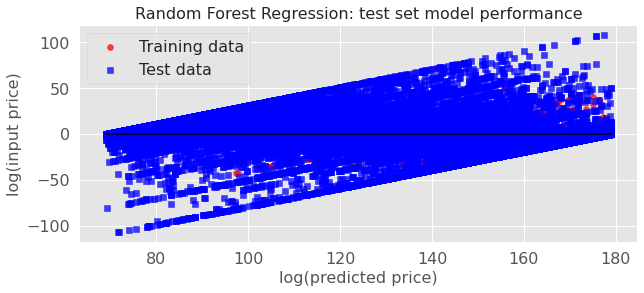

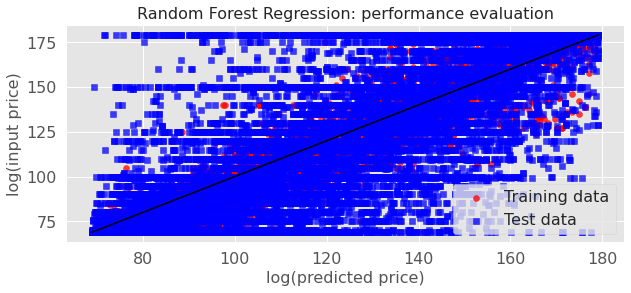

In [253]:
title0='Random Forest Regression:'
model_tmp = model_rf

title=title0 + ' training set model performance'
prediction_train=evaluate(model_tmp, X_train, y_train,title)

title=title0 + ' test set model performance'
prediction_test=evaluate(model_tmp, X_test, y_test,title)


scatter_plot2(prediction_train,y_train,prediction_test,y_test,title)

title=title0 + ' performance evaluation'
scatter_plot3(prediction_train,y_train,prediction_test,y_test,title)

importances_train = pd.DataFrame({'Feature':X_train.columns, 'Importance':model_rf.feature_importances_})
importances_train = importances_train.sort_values('Importance',ascending=False).set_index('Feature')
feature_extraction(importances_train,'Random Forest Regression: Training set feature importance')

In [254]:
# gradient boosting hyperparameter tuned
# Hyperparameter tuned gradient boosting Regression
gbr = GradientBoostingRegressor(min_samples_split=2,
                                min_samples_leaf=2,
                                subsample=0.8,
                                random_state=1,
                               learning_rate=0.01,
                               max_features='sqrt')
#param_grid = {"n_estimators":np.arange(1000,10000,1000),'learning_rate':[0.01,0.05,0.1,0.25,0.5]}
param_grid = dict(n_estimators=[100,600], max_depth=[1,3,8])

grid_gbr=GridSearchCV(gbr, param_grid, cv=5, scoring='neg_mean_squared_error',n_jobs=-2)

grid_gbr.fit(X_train,y_train)

#print("Random forest grid.cv_results_ {}".format(grid_gbr.cv_results_))
print("Random forest grid.best_score_ {}".format(grid_gbr.best_score_))
print("Random forest grid.best_params_ {}".format(grid_gbr.best_params_))
print("Random forest grid.best_estimator_ {}".format(grid_gbr.best_estimator_))

model_gbr = grid_gbr.best_estimator_

GridSearchCV(cv=5,
             estimator=GradientBoostingRegressor(learning_rate=0.01,
                                                 max_features='sqrt',
                                                 min_samples_leaf=2,
                                                 random_state=1,
                                                 subsample=0.8),
             n_jobs=-2,
             param_grid={'max_depth': [1, 3, 8], 'n_estimators': [100, 600]},
             scoring='neg_mean_squared_error')

Random forest grid.best_score_ -552.3896341485972
Random forest grid.best_params_ {'max_depth': 8, 'n_estimators': 600}
Random forest grid.best_estimator_ GradientBoostingRegressor(learning_rate=0.01, max_depth=8, max_features='sqrt',
                          min_samples_leaf=2, n_estimators=600, random_state=1,
                          subsample=0.8)


Gradient Boosting Regression: training set model performance
R^2: 0.7549
RMSE: $22.2398 
Gradient Boosting Regression: test set model performance
R^2: 0.7273
RMSE: $23.4546 


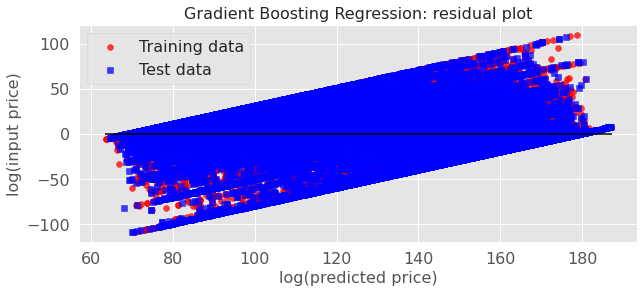

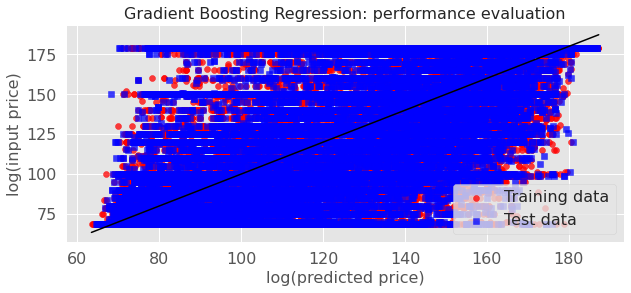

In [255]:
title0='Gradient Boosting Regression:'
model_tmp = model_gbr

title=title0 + ' training set model performance'
prediction_train=evaluate(model_tmp, X_train, y_train,title)

title=title0 + ' test set model performance'
prediction_test=evaluate(model_tmp, X_test, y_test,title)

title=title0 + ' residual plot'
scatter_plot2(prediction_train,y_train,prediction_test,y_test,title)

title=title0 + ' performance evaluation'
scatter_plot3(prediction_train,y_train,prediction_test,y_test,title)

importances_train = pd.DataFrame({'Feature':X_train.columns, 'Importance':model_tmp.feature_importances_})
importances_train = importances_train.sort_values('Importance',ascending=False).set_index('Feature')
feature_extraction(importances_train,'Gradient Boosting Regression: Training set feature importance')

## FINAL REPORT :

**Linear Reg**
RFE Feature selection:

R^2 score for train: 0.6369799616222565
R^2 score for test: 0.635412119637978

After applying Standard scaler:

R^2 score for train: 0.6369799616222565
R^2 score for test: 0.635412119637978

**Ridge reg:**

RFE Feature selection:

train_rmse:  27.063829839500183
train_r2 score:  0.6369799616214836
test_rmse:  27.122013030869358
test_r2 score:  0.6354121243730774

Lasso cv Feature selection:
 
ytrain_rmse:  27.262963919522388
ytrain_r2 score:  0.6316181474690495
test_rmse:  27.31931774864737
test_r2 score:  0.6300882894100244


**Lasso Reg:**

RFE Feature selection:

train_rmse:  27.06526953410705
train_r2 score:  0.6369413379754045
test_rmse:  27.121916828518213
test_r2 score:  0.6354147107702295

Lasso cv Feature selection:

train_rmse:  27.26297648274075
train_r2 score:  0.6316178079562413
test_rmse:  27.319375560168037
test_r2 score:  0.6300867238379024

**Elastic_Net:**
RFE Feature selection:

train_rmse:  27.26657574369064
train_r2 score:  0.6315205338260843
test_rmse:  27.323278460597063
test_r2 score:  0.6299810231926983

**Gradient Boosting**

RFE Feature selection:

test_rmse:  25.981896947224925
test_r2 score:  0.6654199102825642

Lasso cv Feature selection:

test_rmse:  25.49278693944052
test_r2 score:  0.677898302118356



**XG Boost:**

RFE Feature selection:

test_rmse:  24.90947071759183
test_r2 score:  0.6924700760810385

Lasso cv Feature selection:

test_rmse:  25.593941826859893
test_r2 score:  0.6753370440057858


**Random Forest:**

Random Forest Regression: training set model performance
R^2: 0.9761
Random Forest Regression: test set model performance
R^2: 0.8481

**Gradient Boosting Regression: training set model performance:**
R^2: 0.7548

Gradient Boosting Regression: test set model performance
R^2: 0.7272